In [18]:
import os, glob
import numpy as np
from astropy.io import fits
from scipy.interpolate import interp1d
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
plt.style.use(['euclid_stylesheet_v1.mplstyle'])

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from scipy.interpolate import interp1d

In [19]:
import sys
sys.path.append("..")

from src.load_functions import *
from src.functions import *

### Access original files

In [20]:
templates = load_cosmos_templates("../data/value_added_data/galaxy_seds")
ext_laws = load_extinction_laws("../data/value_added_data/galaxy_extincts")
filters = load_filters("../data/value_added_data/filters")

### Collect useful info (central wavelenghts, names of the filters and their errors as saved in the catalogue)

In [21]:
# Names of the filters used for GP-reconstruction and their central wavelenghts
GP_filters = pd.read_csv('../data/GP_filters.csv')
bands = np.array(GP_filters['band'])
central_lambda = np.array( GP_filters['central_lambda'])

# Wavelenghts where we reconstructed the fluxes
gp_waves = np.arange(4000.0, 10000.0 + 100.0, 100.0)

# GP columns and uncertainties
gp_cols     = [f"gp_{w}" for w in gp_waves]
gp_cols_err = [f"gp_{w}_err" for w in gp_waves]

# Columns storing the noisy photometry (plus errors)
phot_cols     = list(bands)
phot_cols_err = [f"{b}_err" for b in bands]

### A) Example of how to reconstruct the SED from the pandas catalogue

In [36]:
# Access the catalogue
df = pd.read_csv('../data/gp_sed_reconstructions.csv')
# df = pd.read_csv('../gp_sed_reconstructions.csv')

In [25]:
# Select the first galaxy, for which we have 10 noisy realisations
halo_id_sel = df['halo_id'].iloc[0]
print(halo_id_sel)
row_sel = df[df['halo_id']==halo_id_sel]
row_sel

5844560344819


,halo_id,galaxy_id,real_id,observed_redshift_gal,mw_extinction,sed_cosmos_1,sed_cosmos_2,ext_curve_cosmos_1,ext_curve_cosmos_2,ebv_cosmos_1,...,gp_9100.0_err,gp_9200.0_err,gp_9300.0_err,gp_9400.0_err,gp_9500.0_err,gp_9600.0_err,gp_9700.0_err,gp_9800.0_err,gp_9900.0_err,gp_10000.0_err
0,5844560344819,0,0,2.657112,0.019066,28,30,3,4,0.0,...,0.000312,0.000313,0.000334,0.000365,0.000396,0.000419,0.000431,0.000431,0.000421,0.000407
1,5844560344819,0,1,2.657112,0.019066,28,30,3,4,0.0,...,0.000480,0.000485,0.000493,0.000499,0.000499,0.000488,0.000464,0.000423,0.000366,0.000295
2,5844560344819,0,2,2.657112,0.019066,28,30,3,4,0.0,...,0.000492,0.000499,0.000503,0.000503,0.000498,0.000487,0.000471,0.000451,0.000429,0.000411
3,5844560344819,0,3,2.657112,0.019066,28,30,3,4,0.0,...,0.000215,0.000090,0.000373,0.000612,0.000795,0.000915,0.000965,0.000943,0.000849,0.000684
4,5844560344819,0,4,2.657112,0.019066,28,30,3,4,0.0,...,0.000518,0.000535,0.000547,0.000553,0.000549,0.000535,0.000508,0.000469,0.000420,0.000366
5,5844560344819,0,5,2.657112,0.019066,28,30,3,4,0.0,...,0.000470,0.000486,0.000504,0.000519,0.000527,0.000527,0.000516,0.000494,0.000464,0.000433
6,5844560344819,0,6,2.657112,0.019066,28,30,3,4,0.0,...,0.000216,0.000208,0.000247,0.000305,0.000359,0.000399,0.000423,0.000428,0.000417,0.000397
7,5844560344819,0,7,2.657112,0.019066,28,30,3,4,0.0,...,0.000679,0.000691,0.000718,0.000749,0.000772,0.000776,0.000758,0.000712,0.000641,0.000550
8,5844560344819,0,8,2.657112,0.019066,28,30,3,4,0.0,...,0.000459,0.000465,0.000468,0.000467,0.000461,0.000451,0.000436,0.000419,0.000402,0.000389
9,5844560344819,0,9,2.657112,0.019066,28,30,3,4,0.0,...,0.000049,0.000033,0.000077,0.000124,0.000165,0.000199,0.000226,0.000246,0.000263,0.000278


In [26]:
len(row_sel)

10

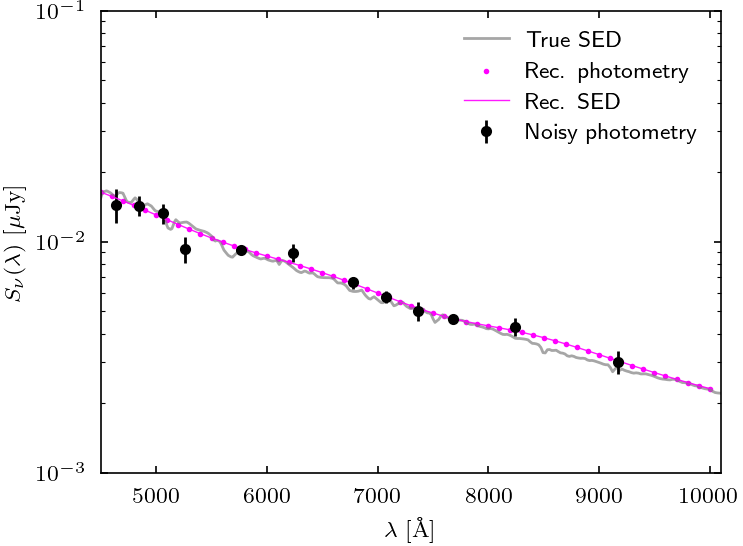

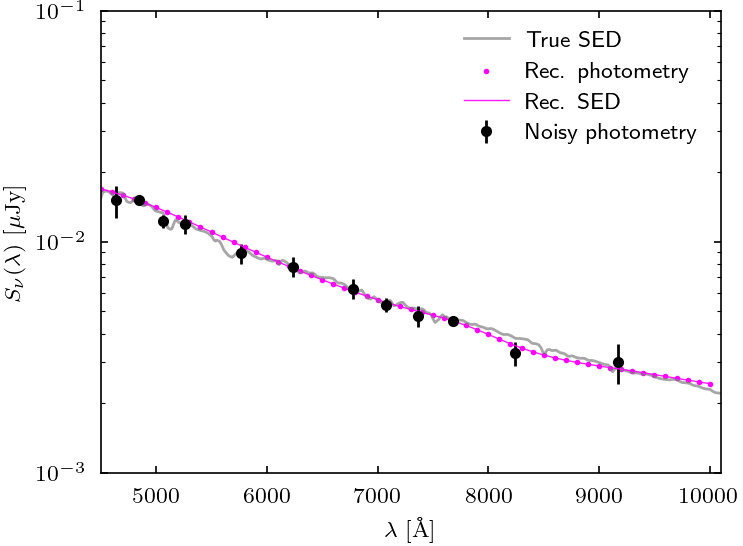

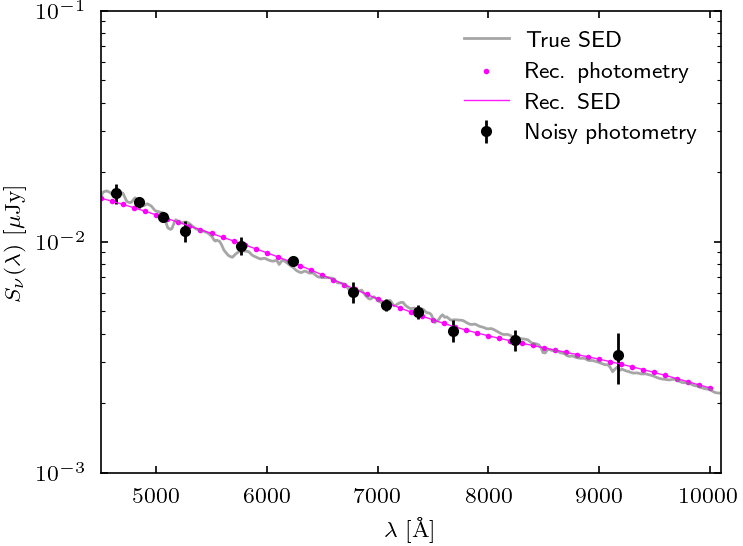

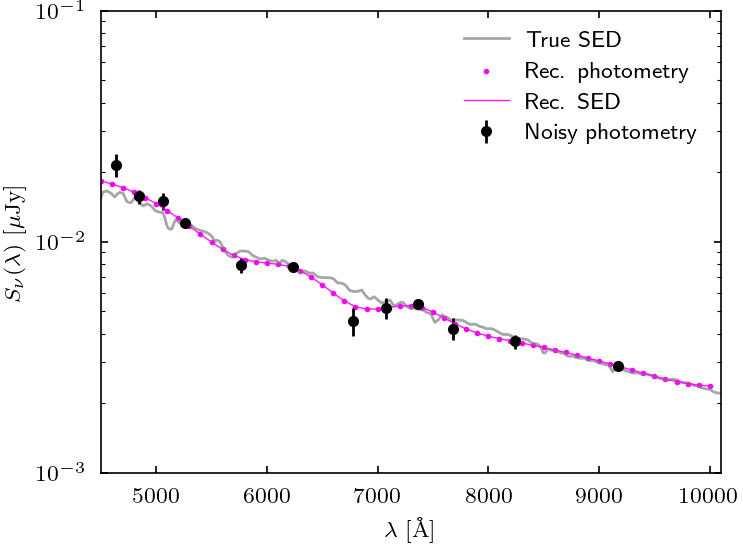

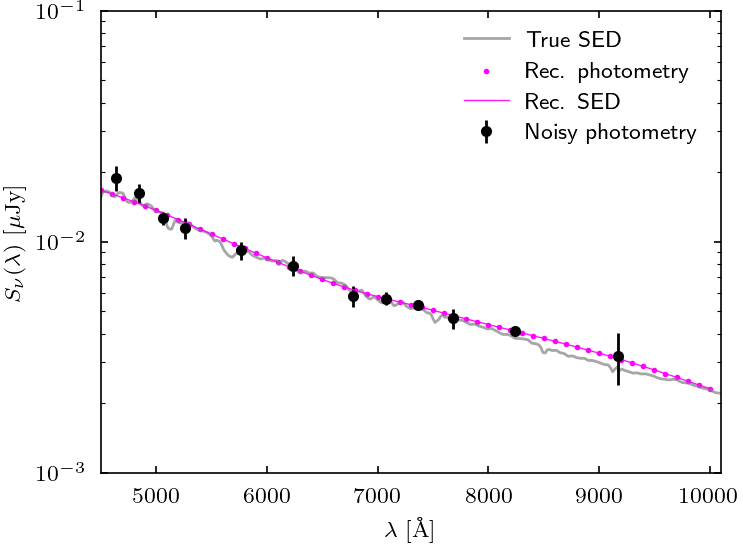

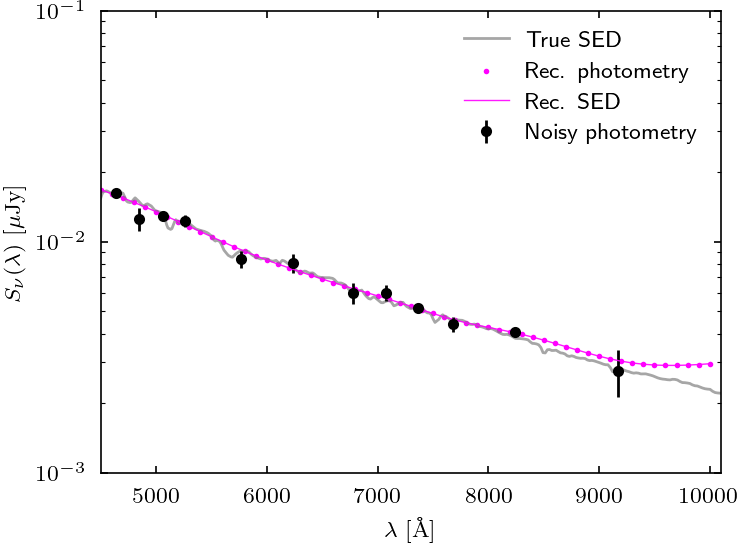

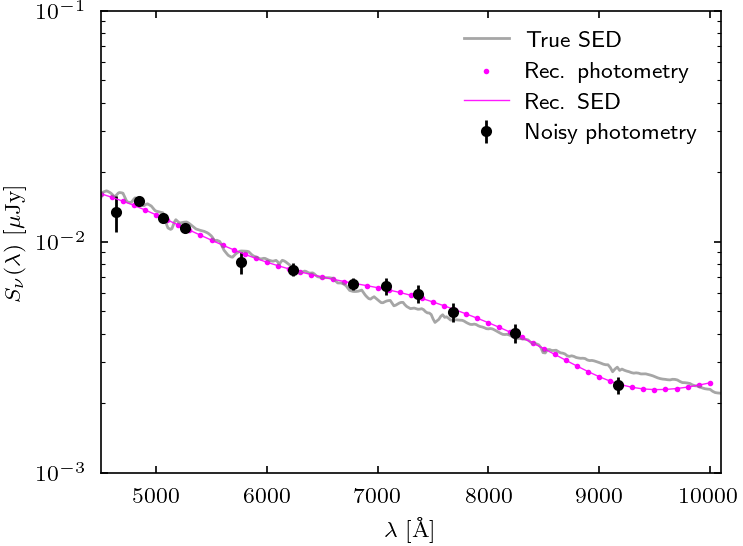

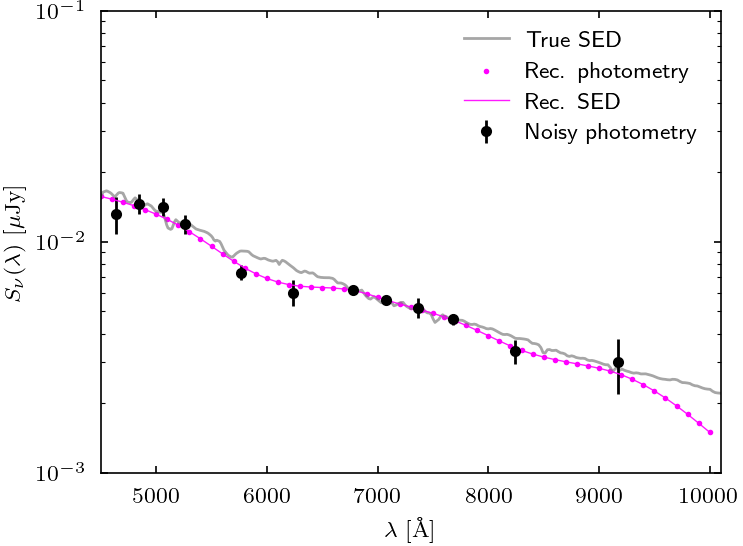

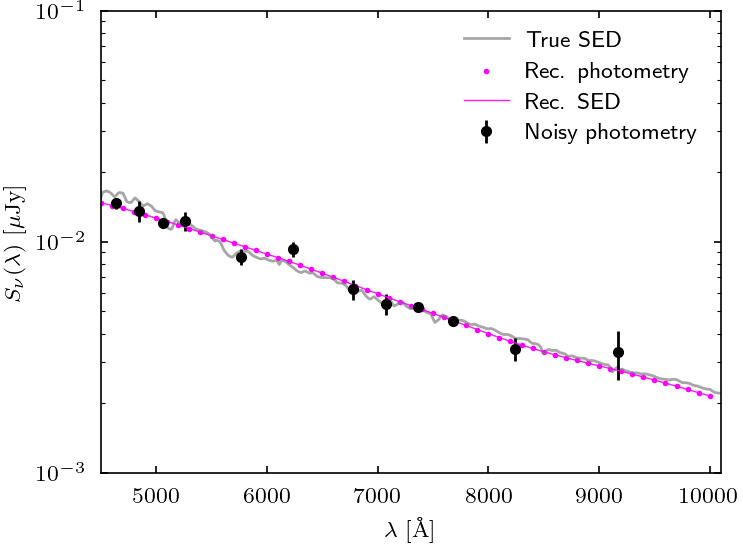

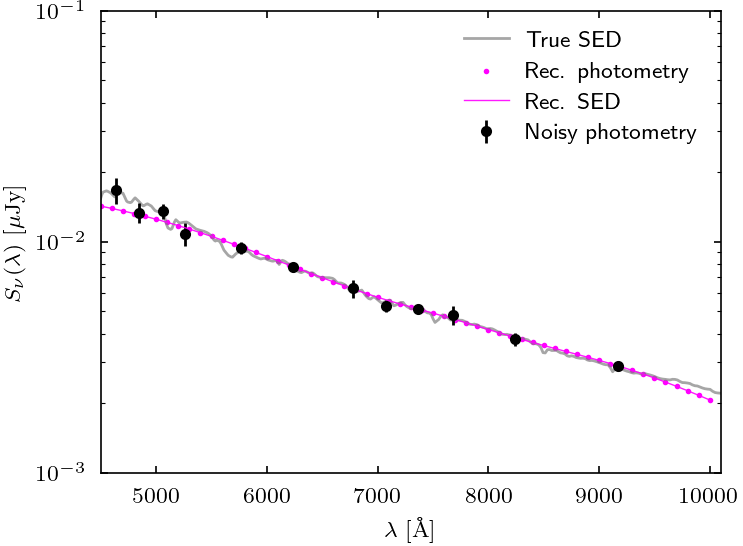

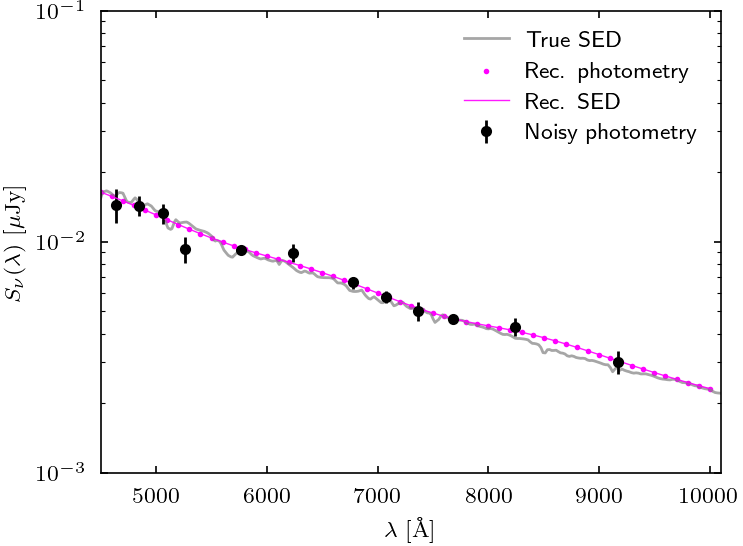

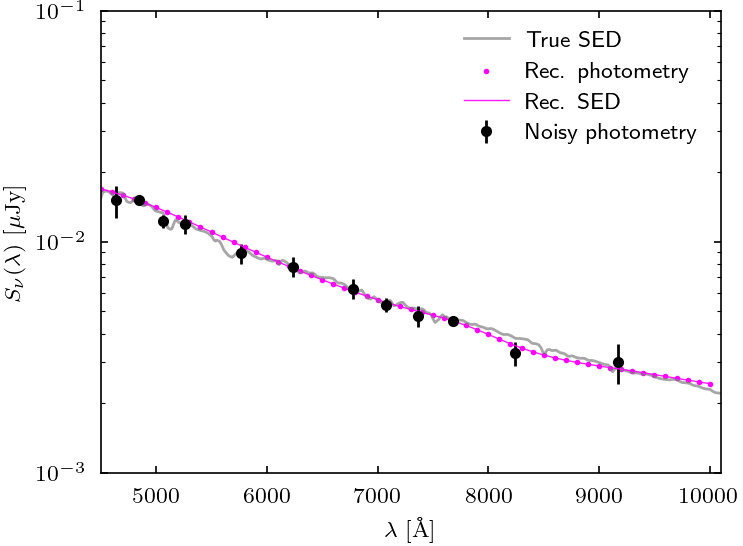

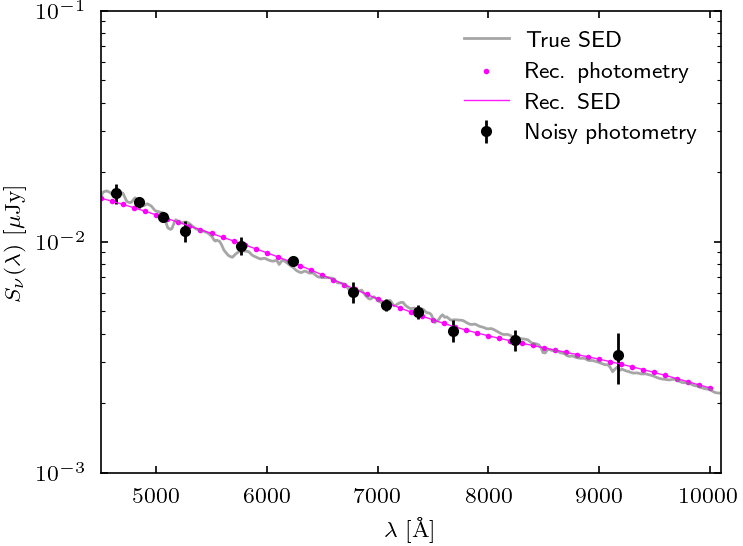

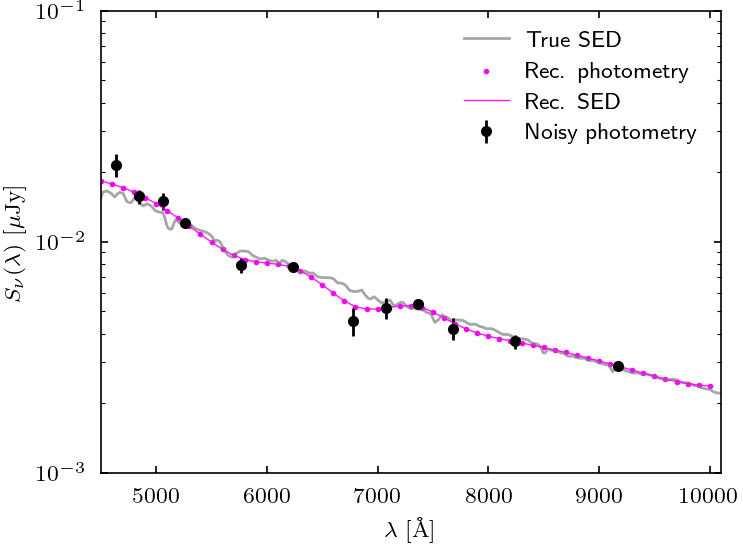

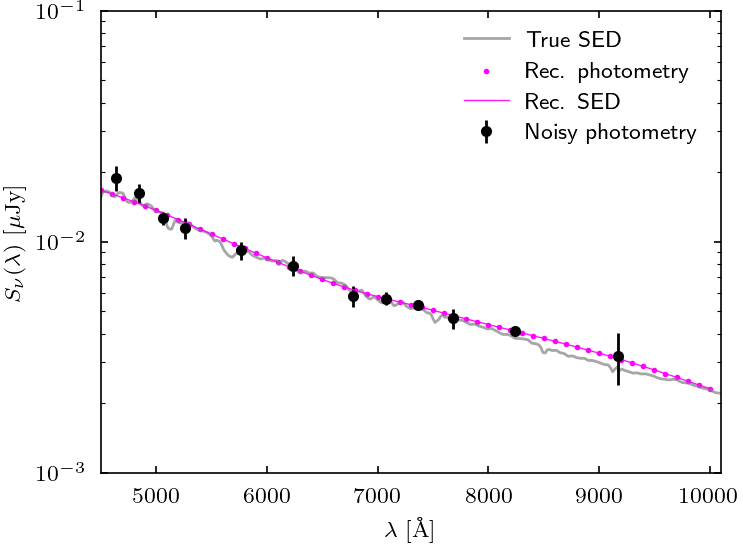

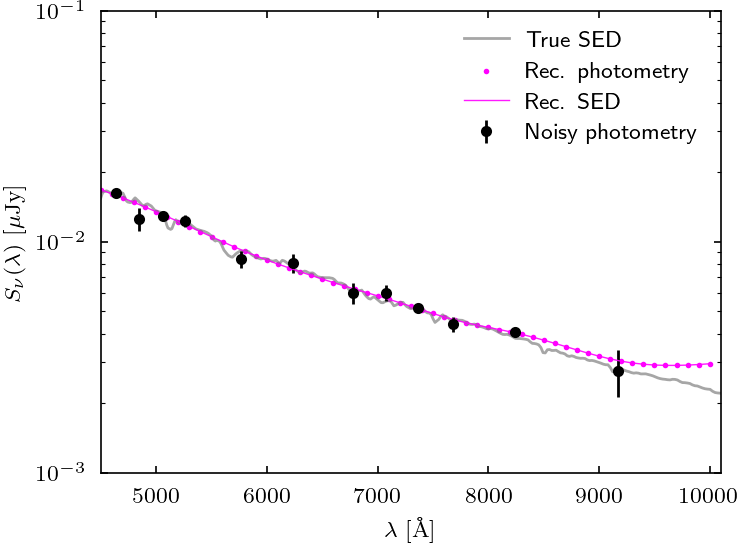

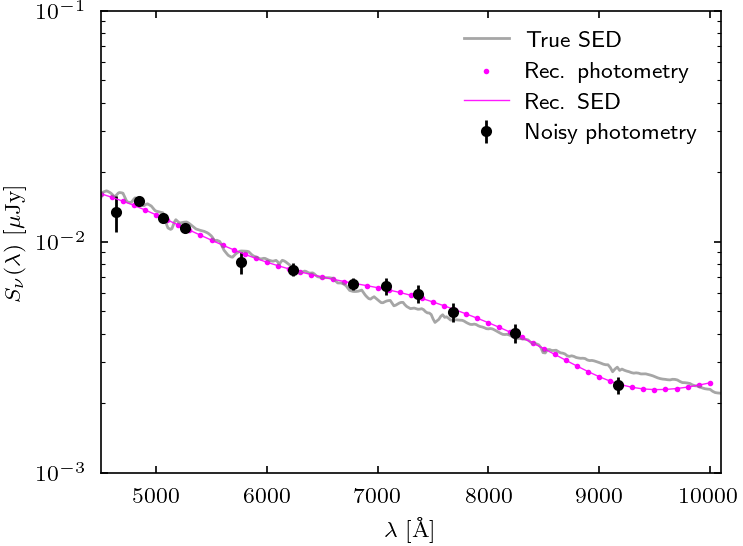

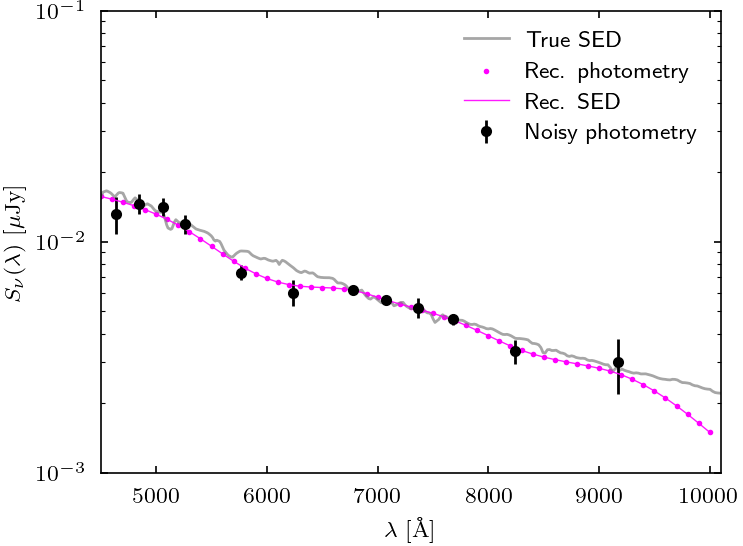

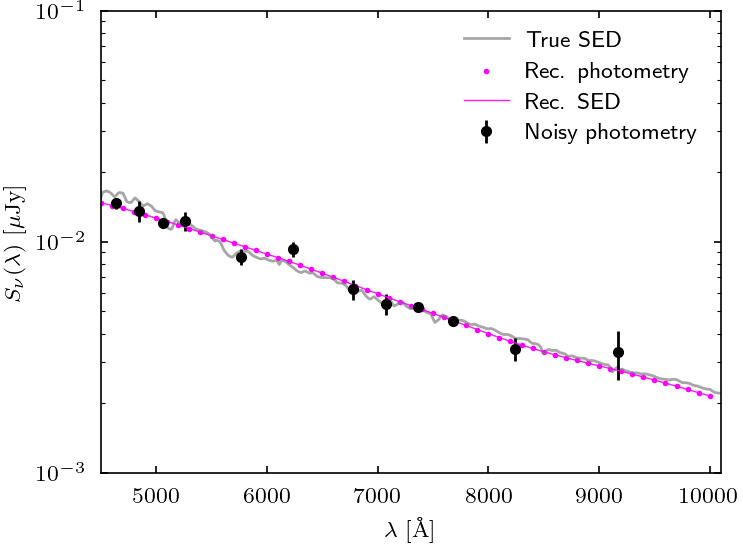

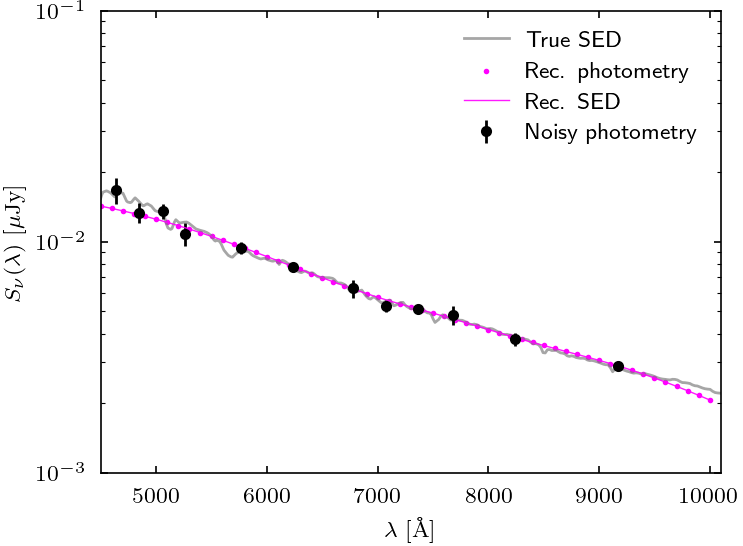

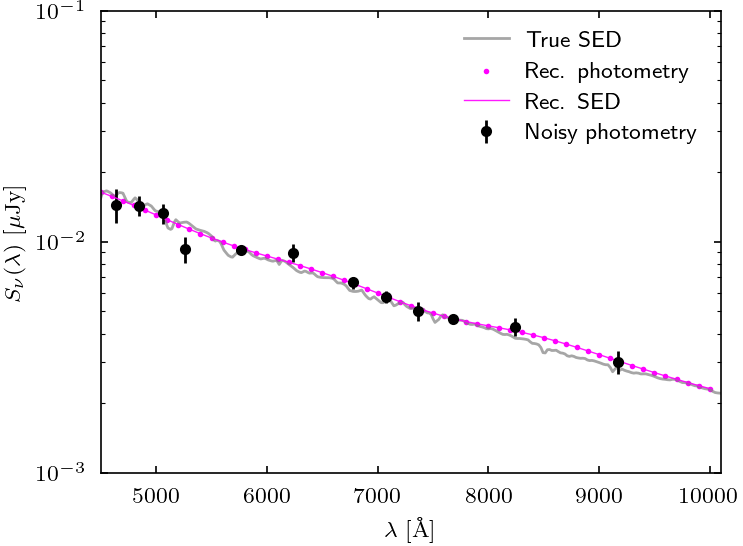

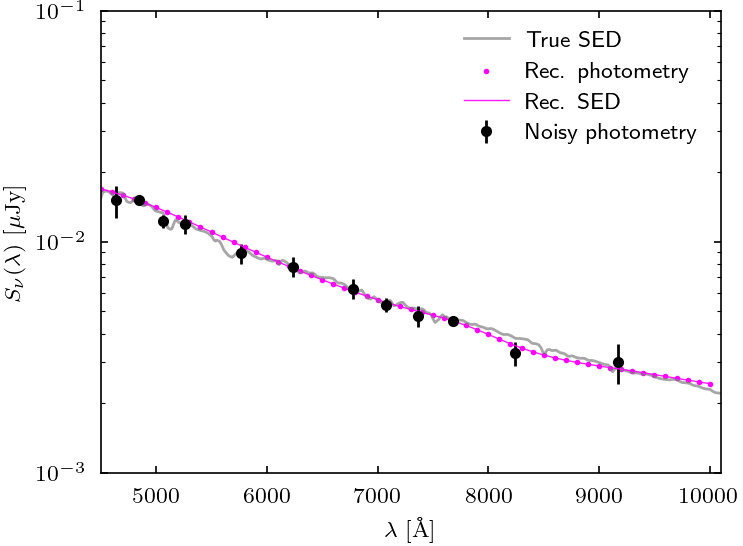

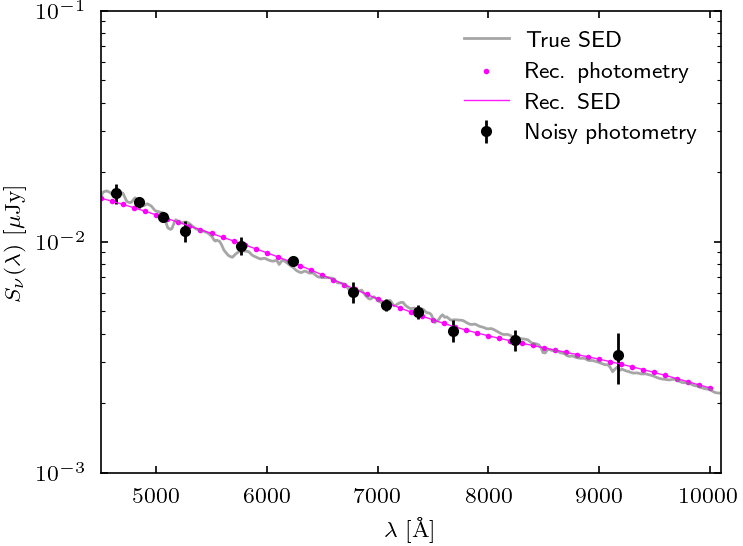

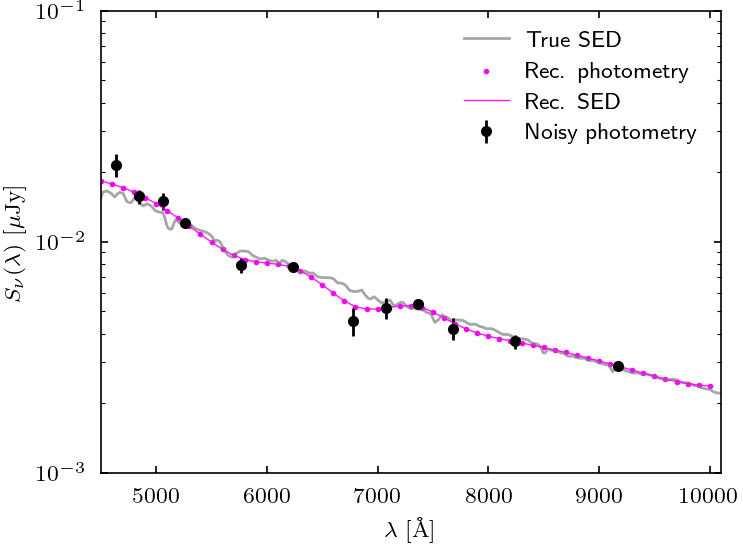

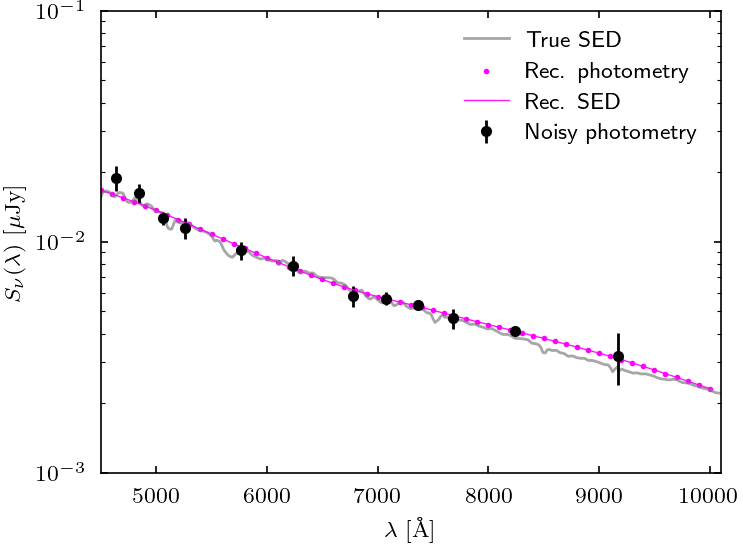

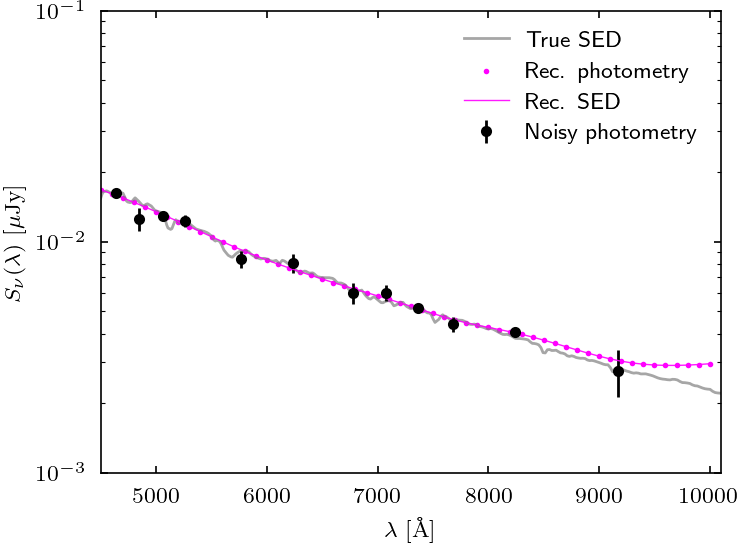

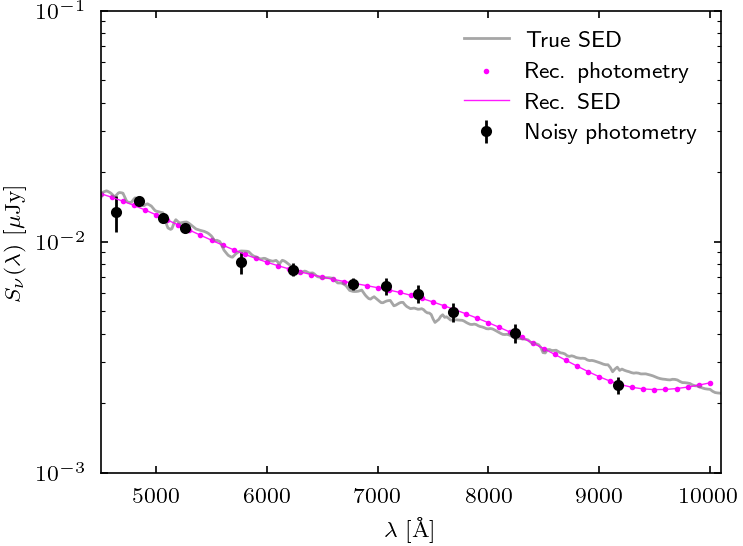

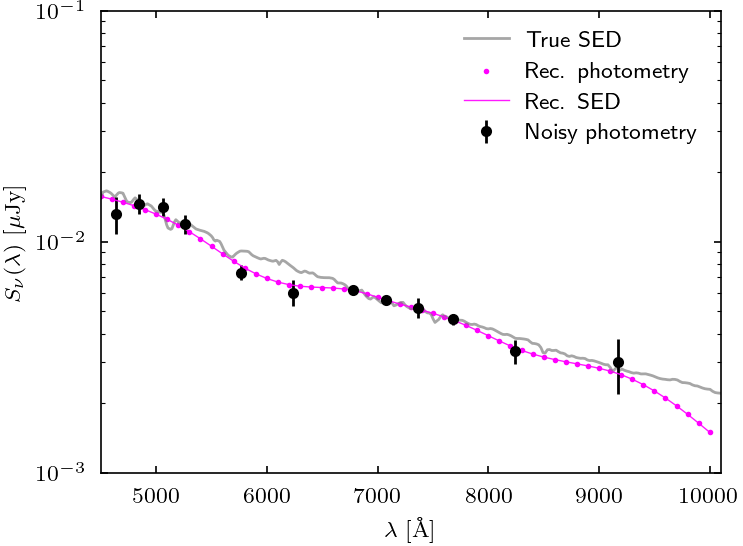

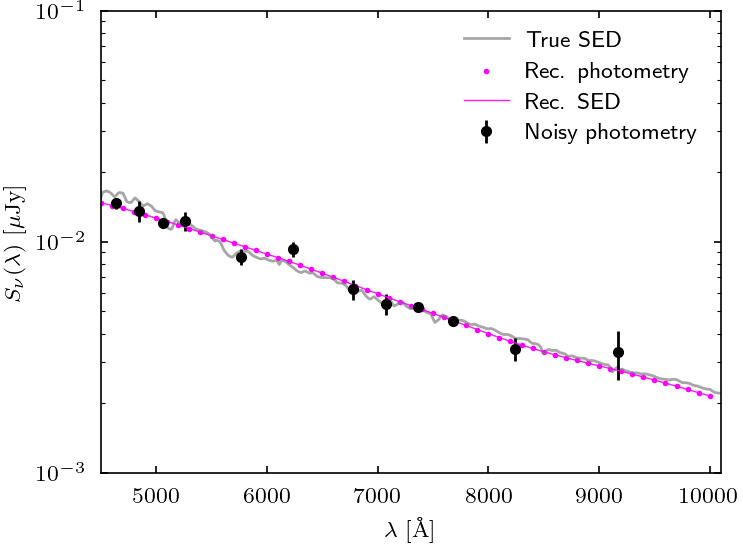

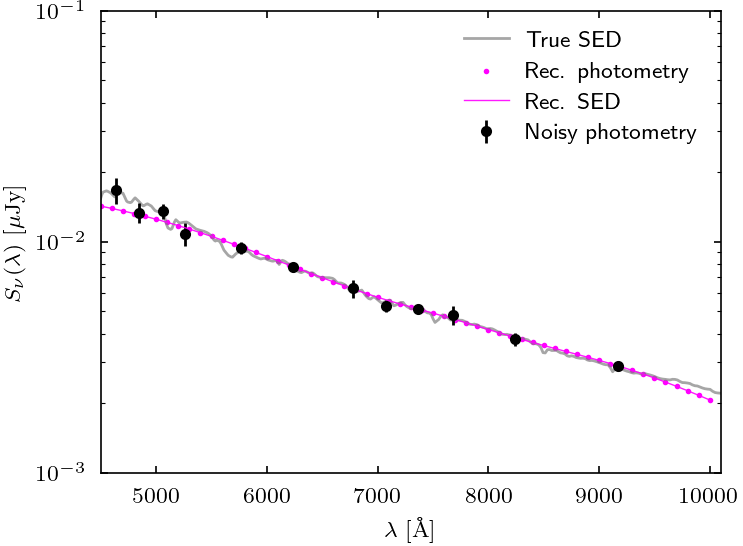

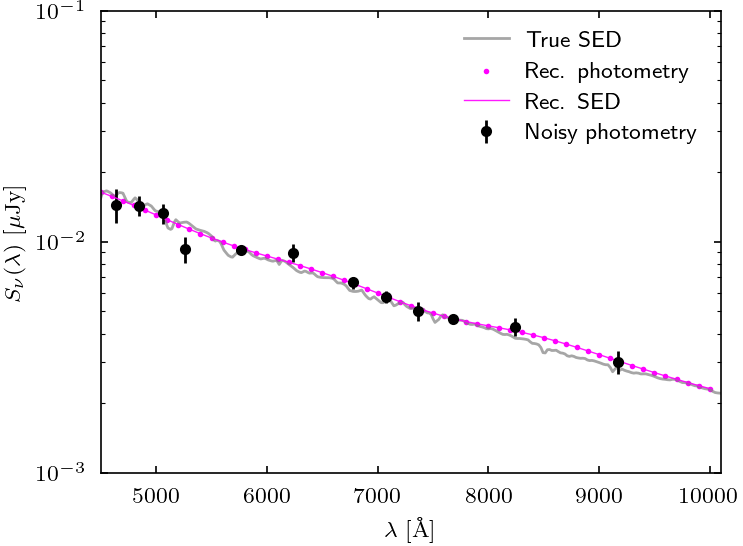

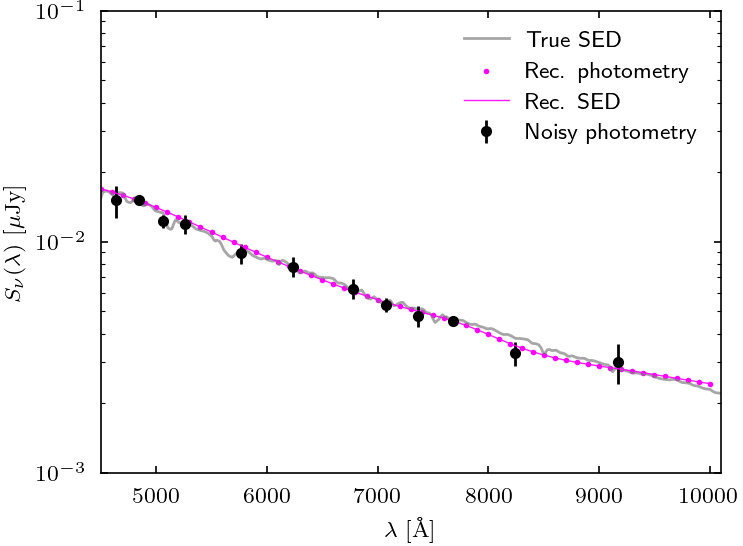

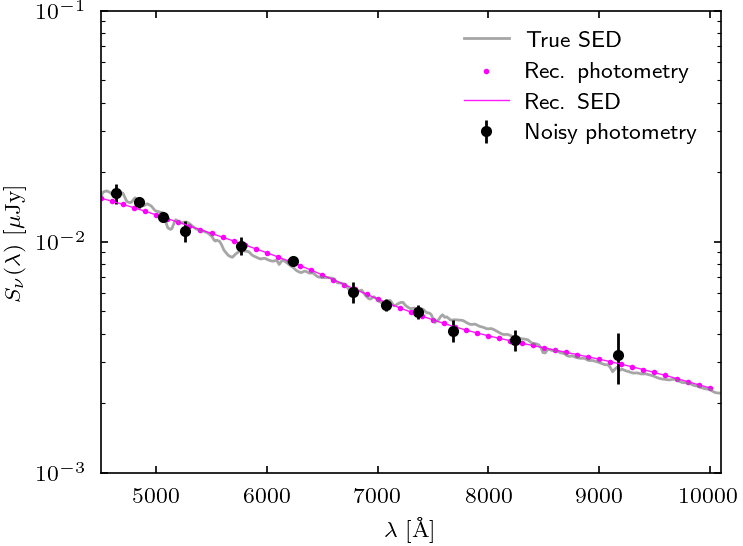

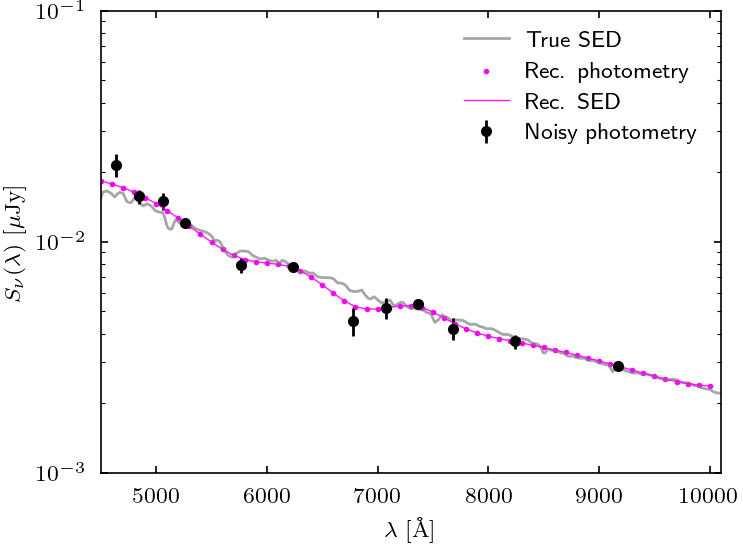

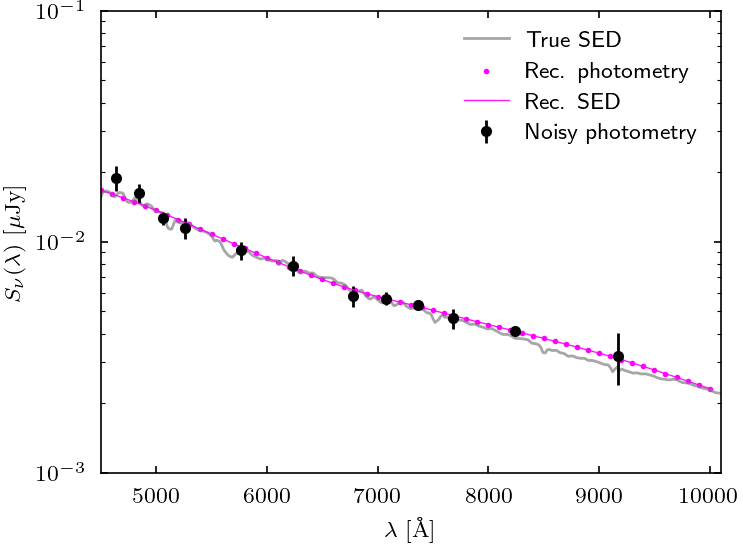

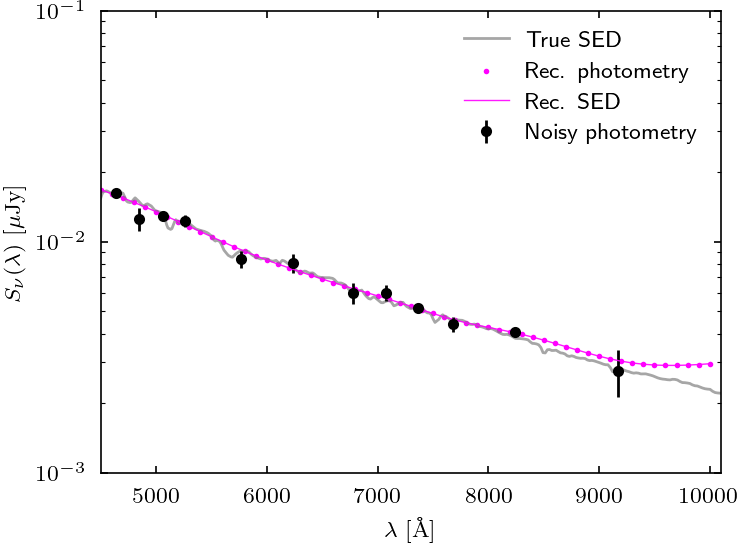

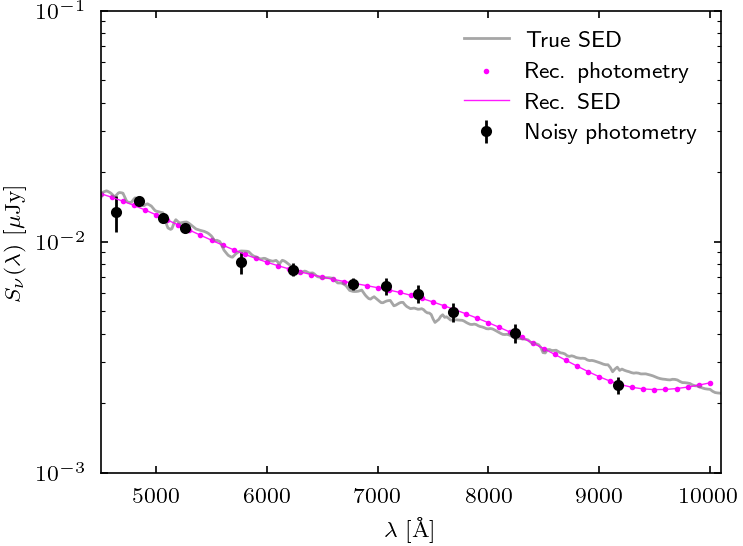

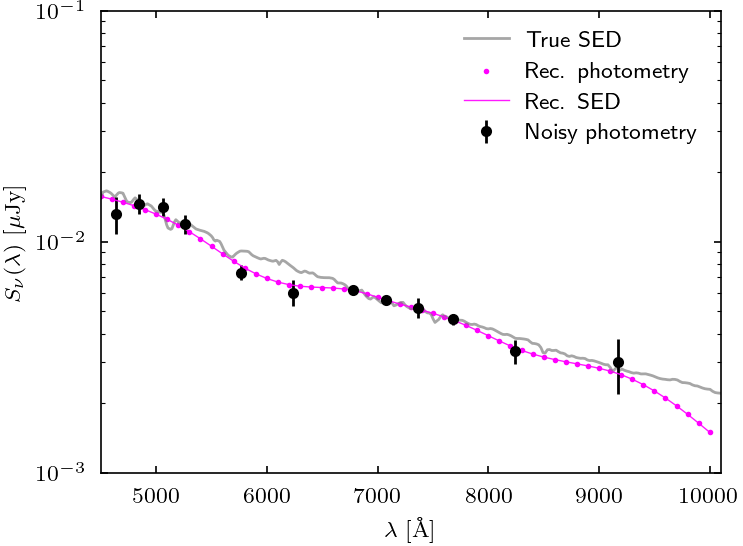

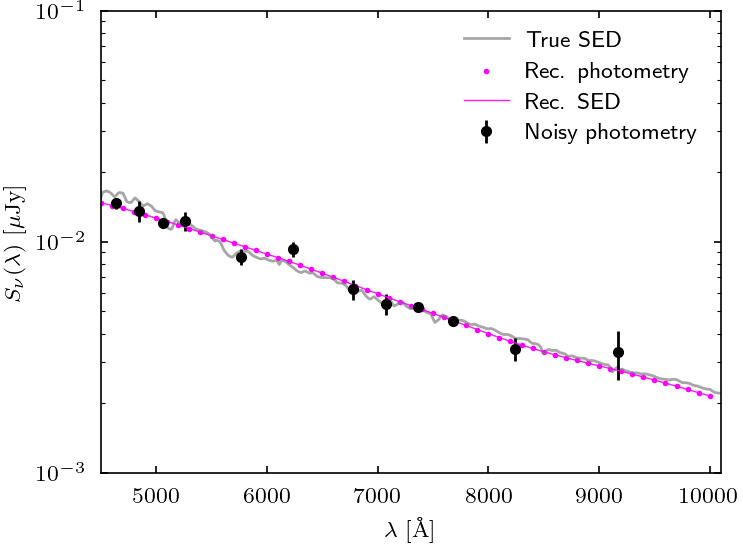

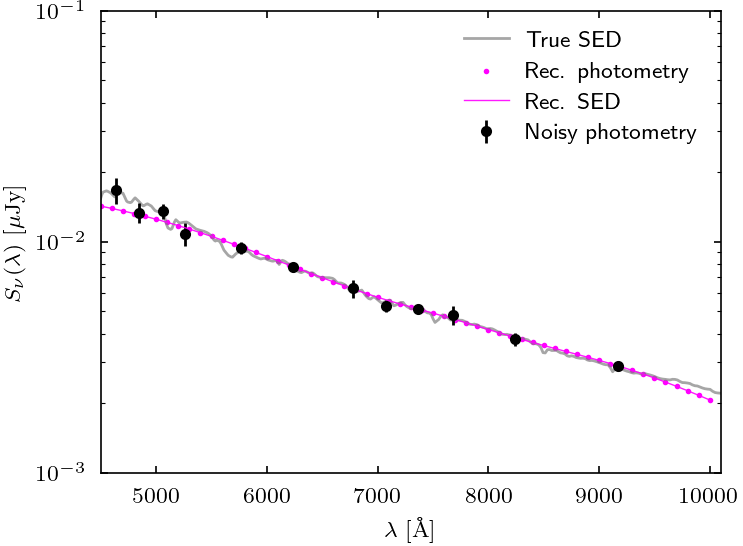

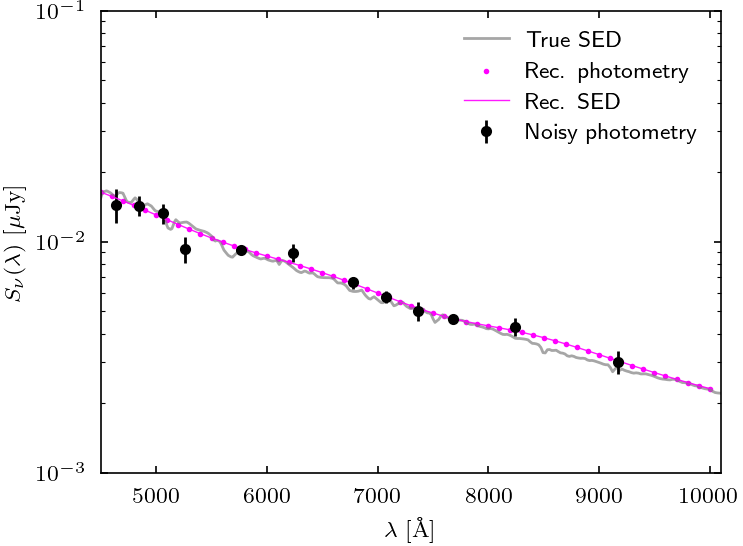

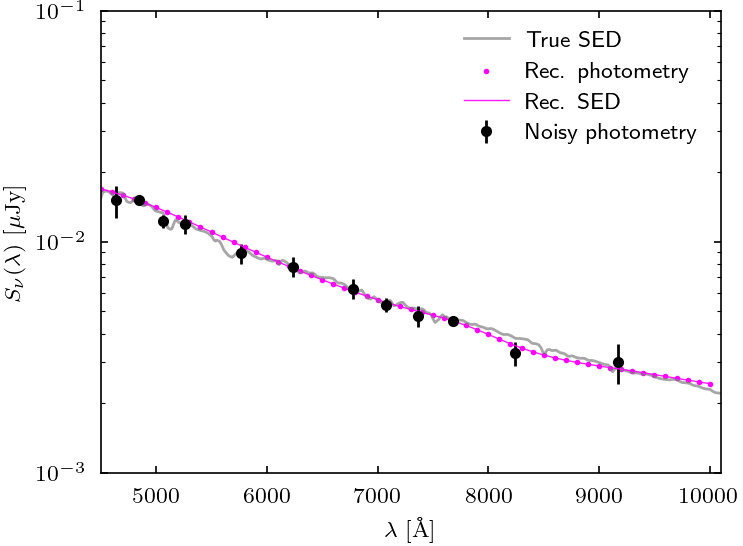

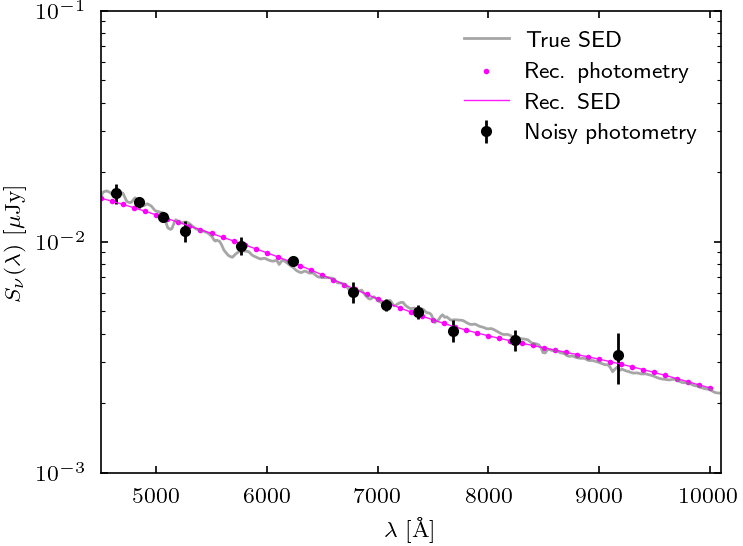

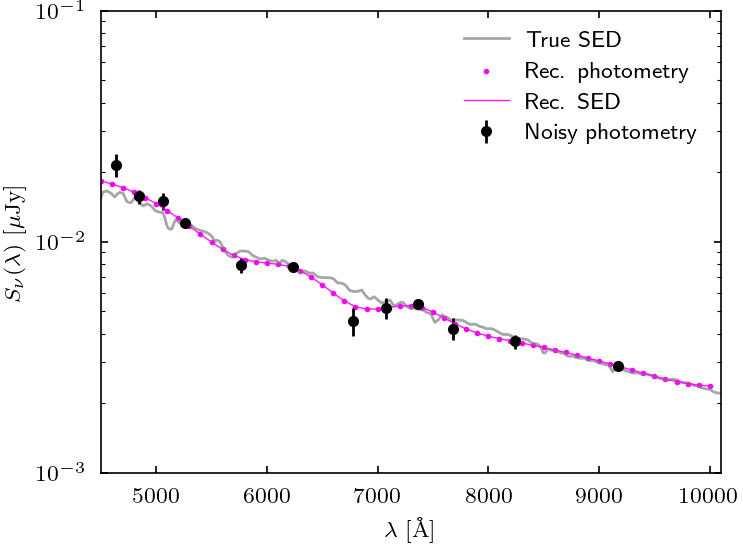

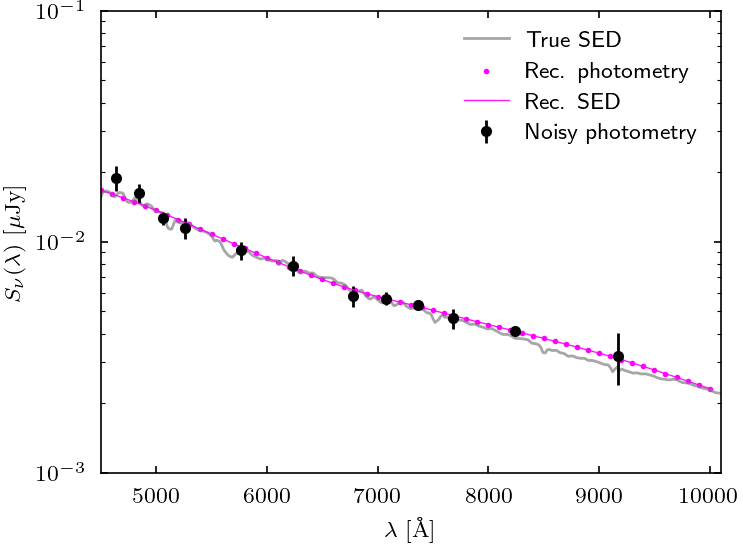

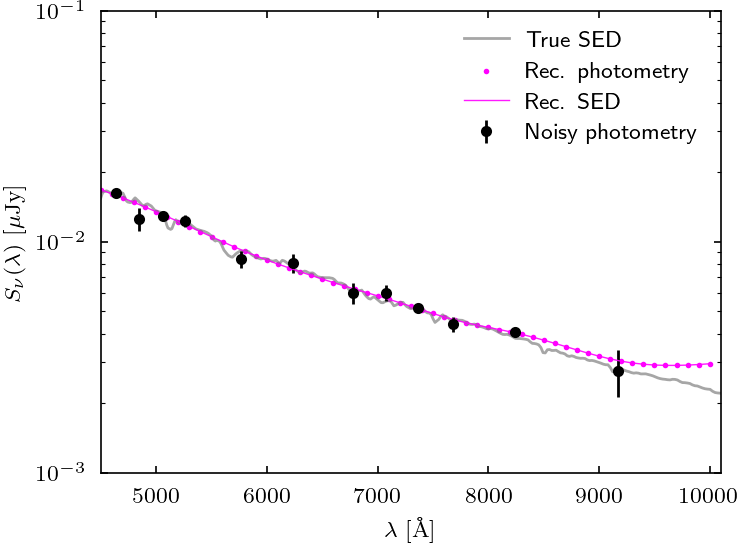

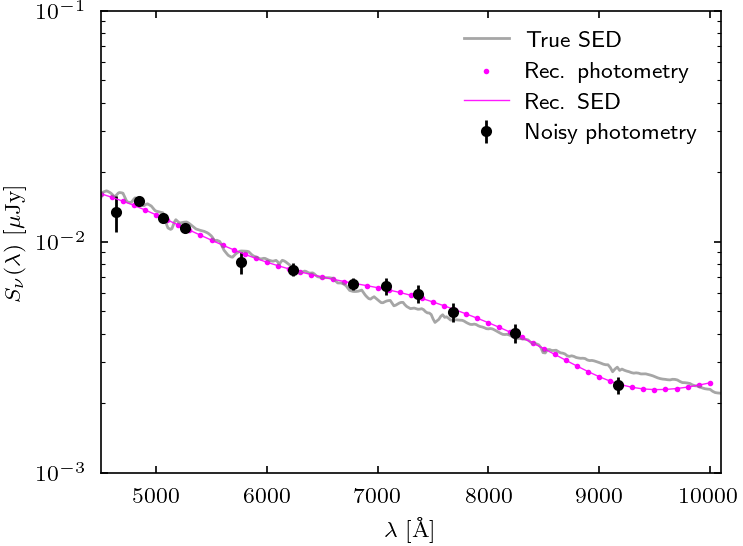

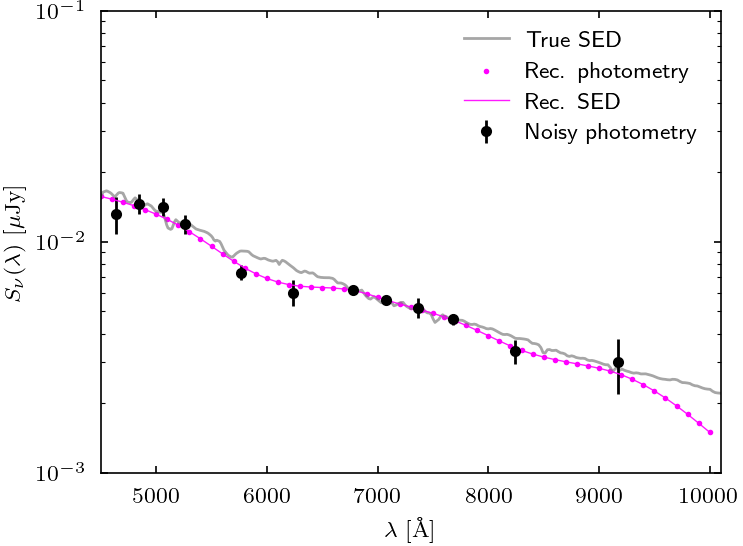

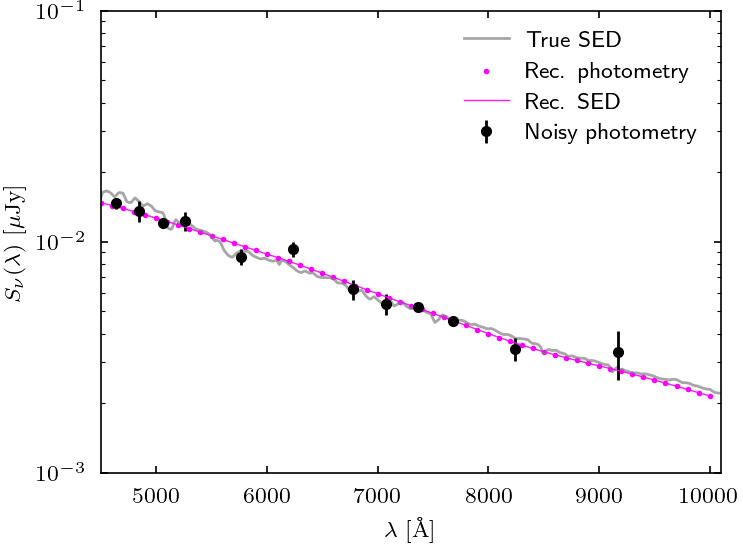

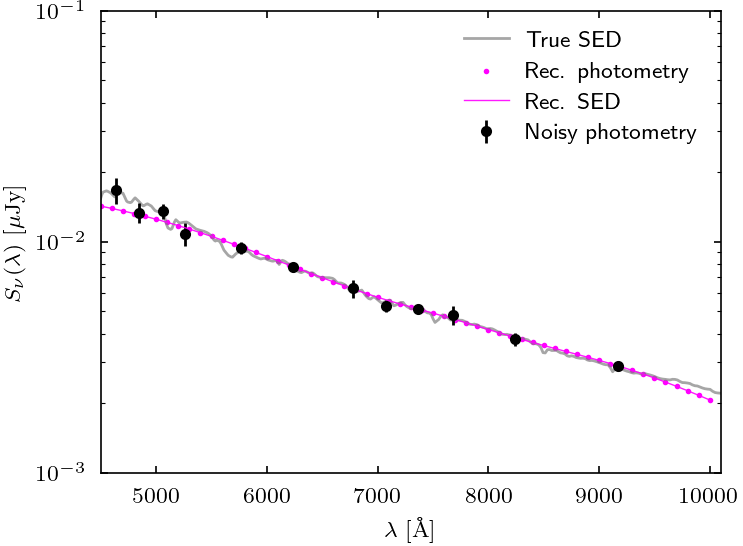

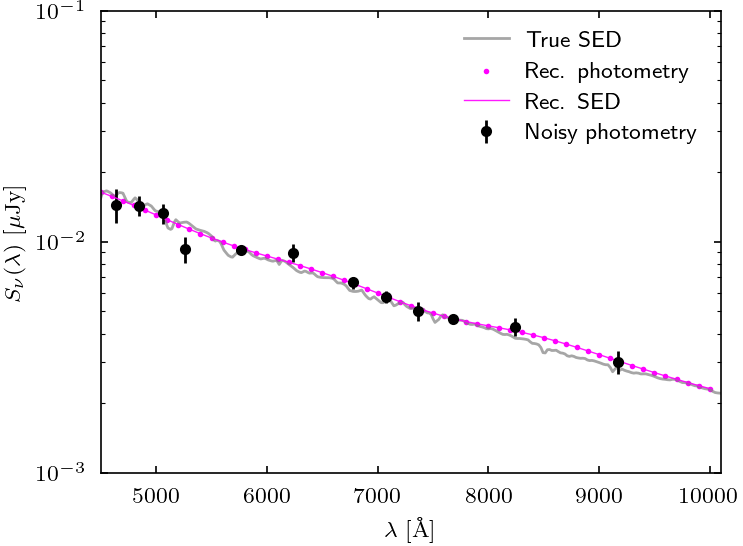

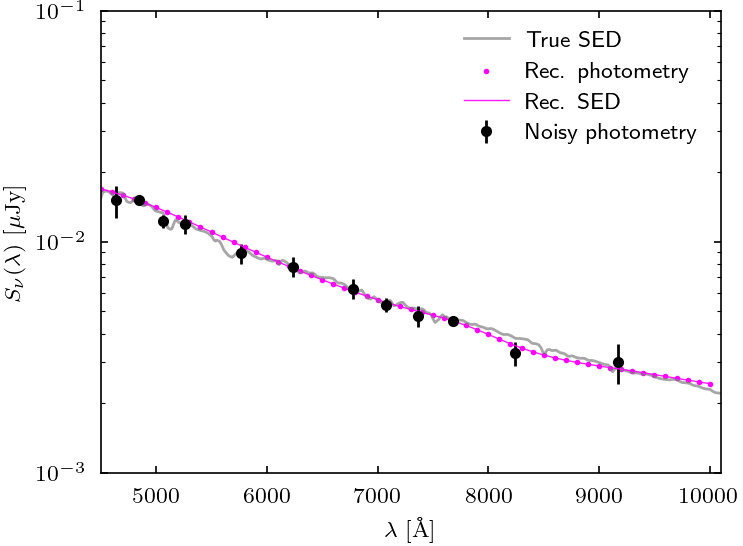

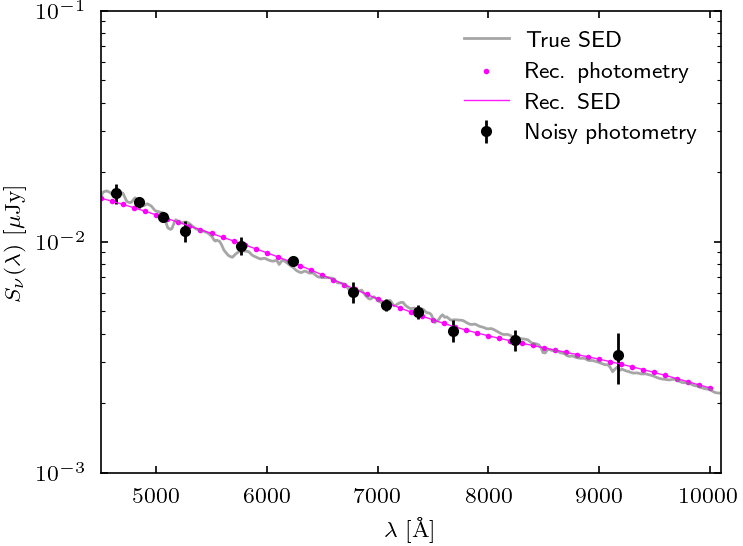

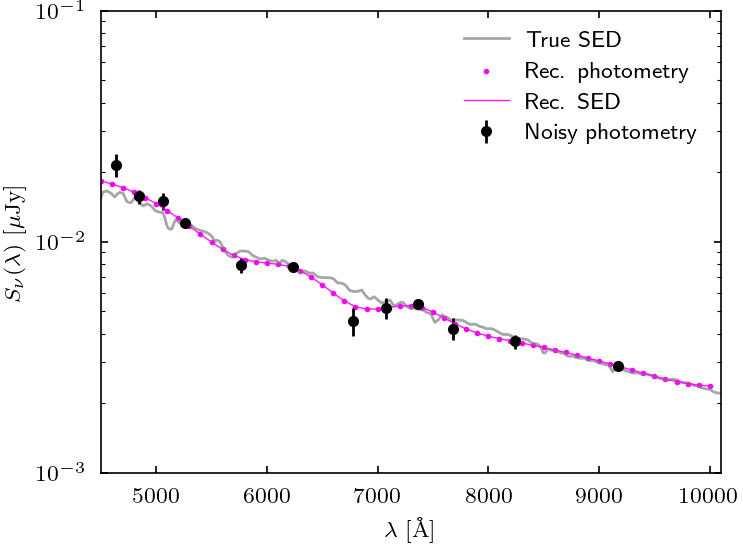

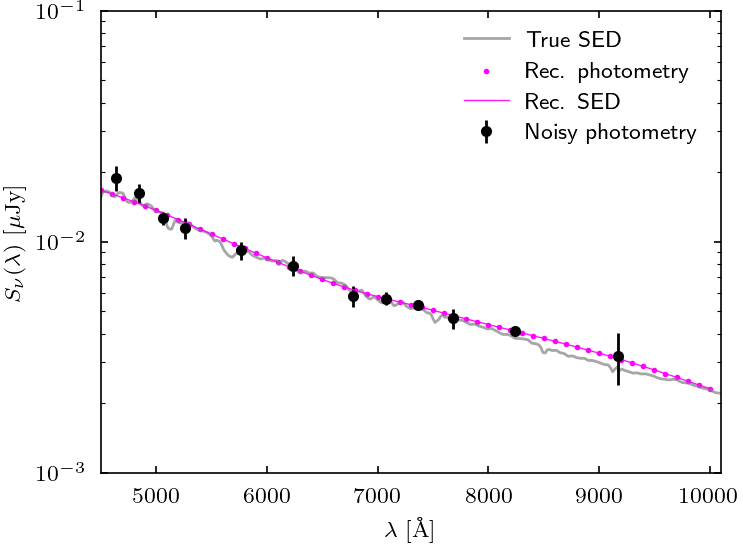

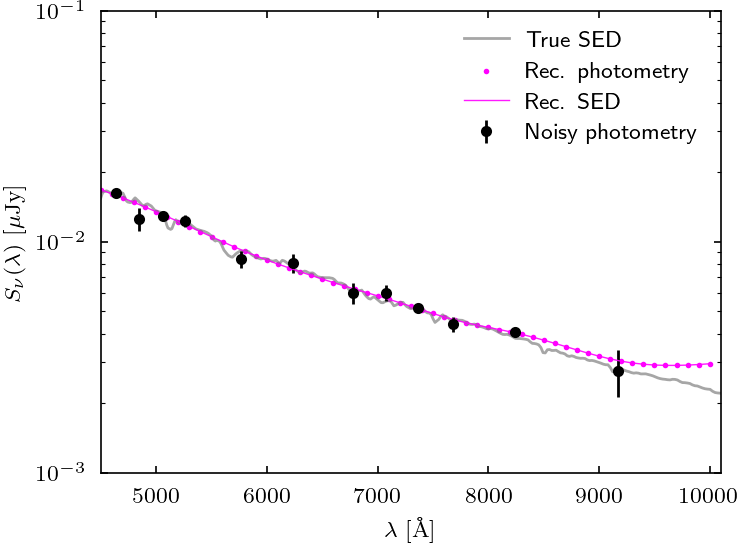

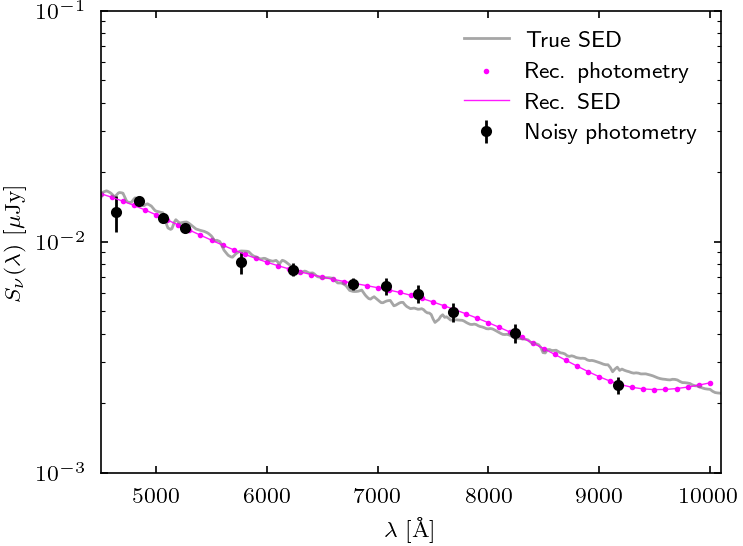

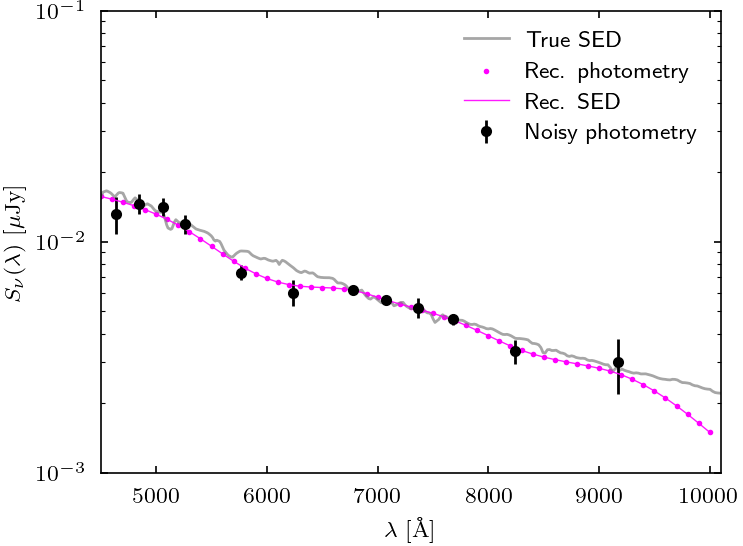

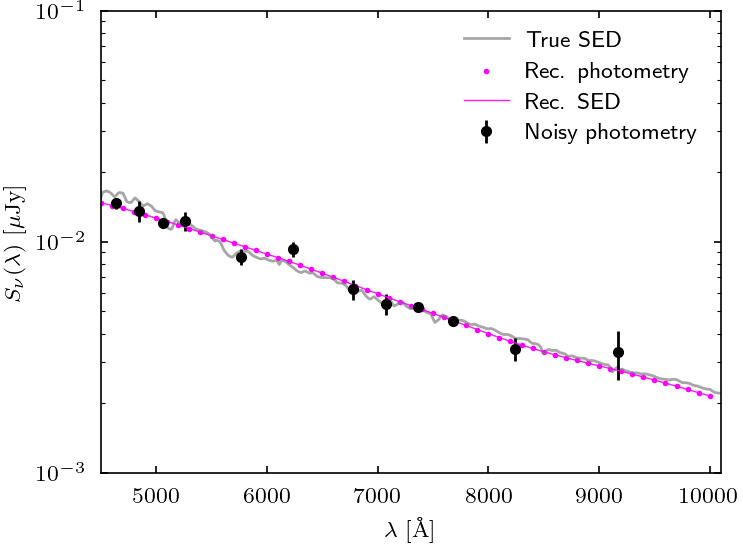

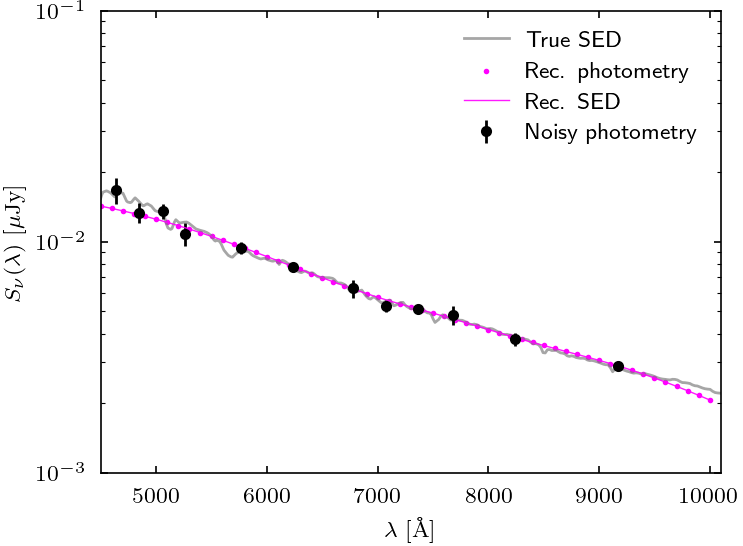

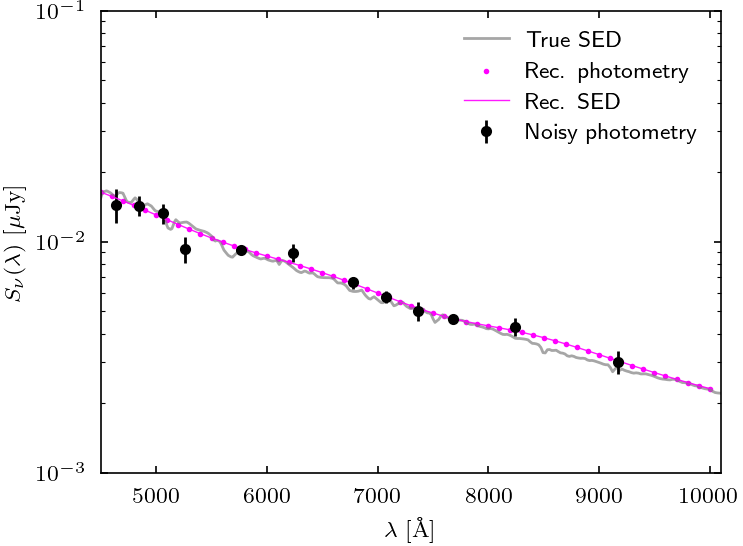

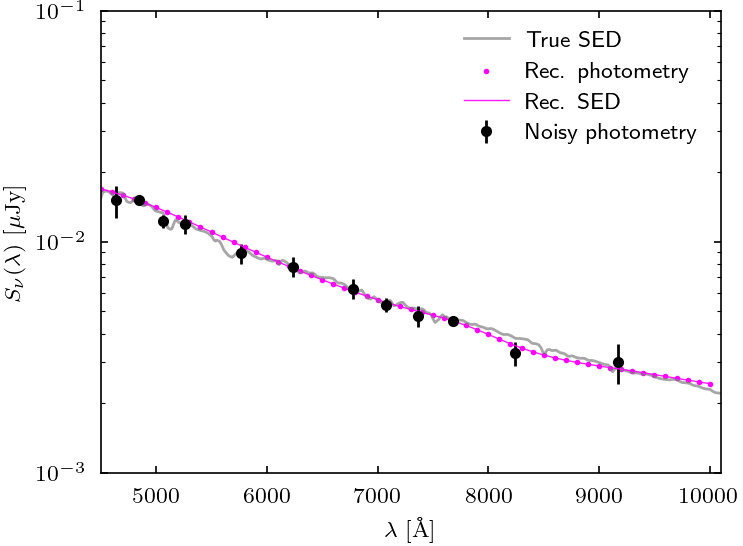

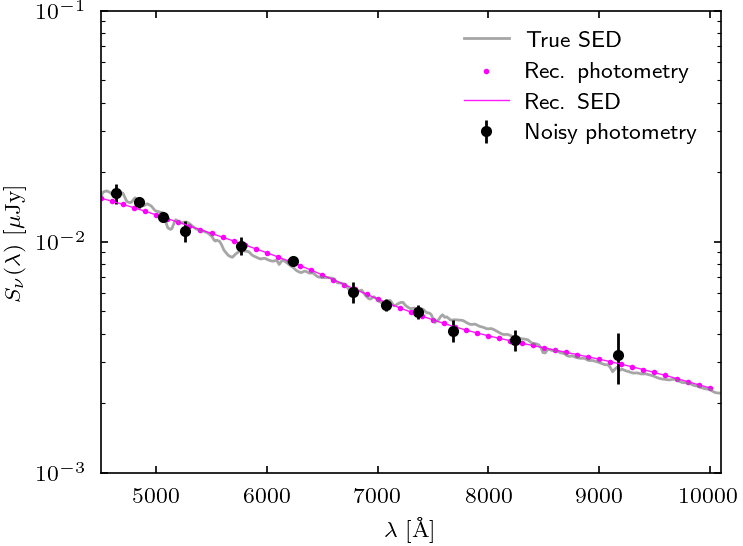

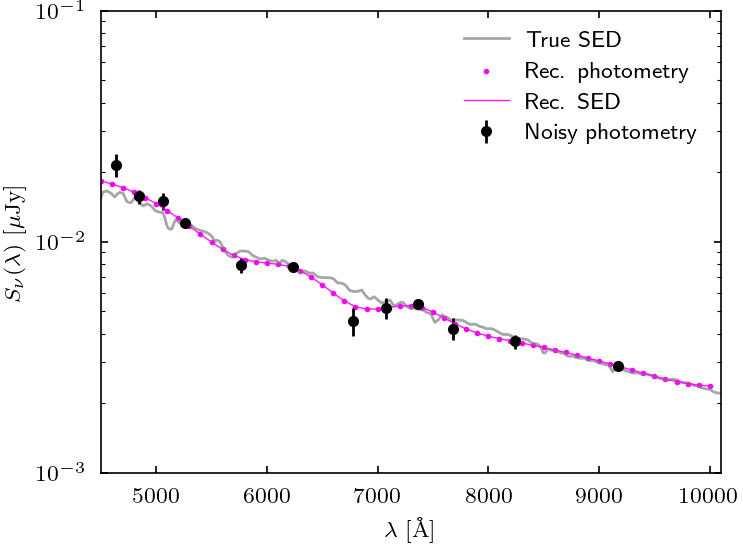

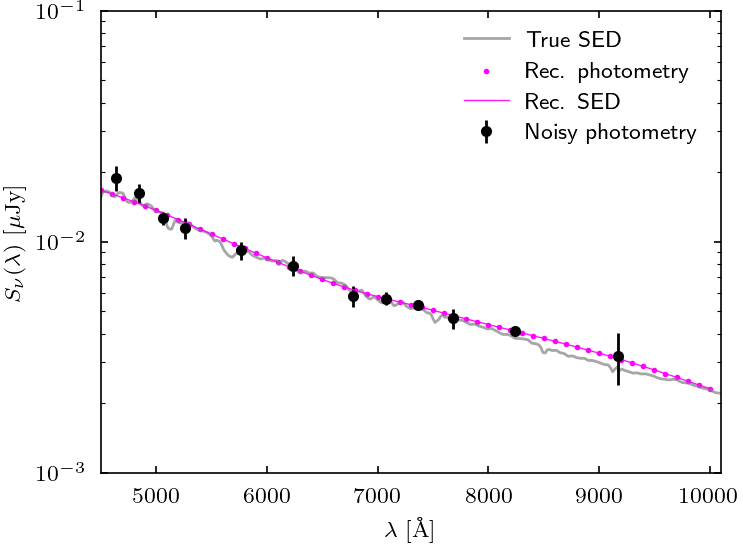

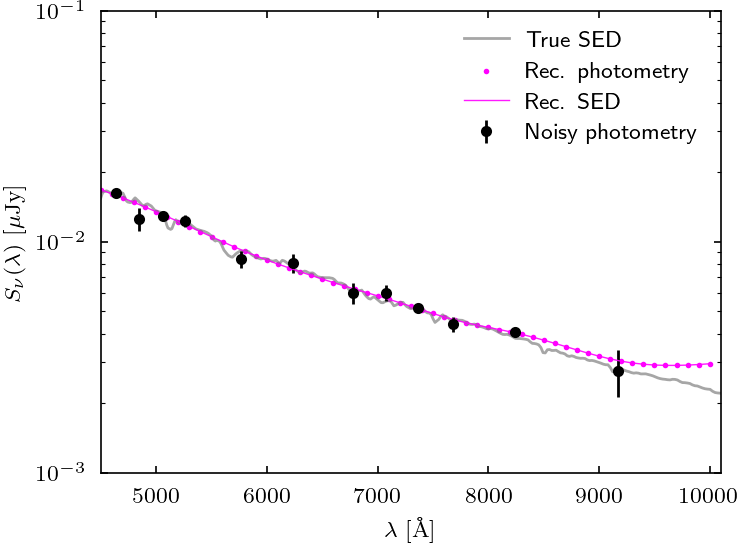

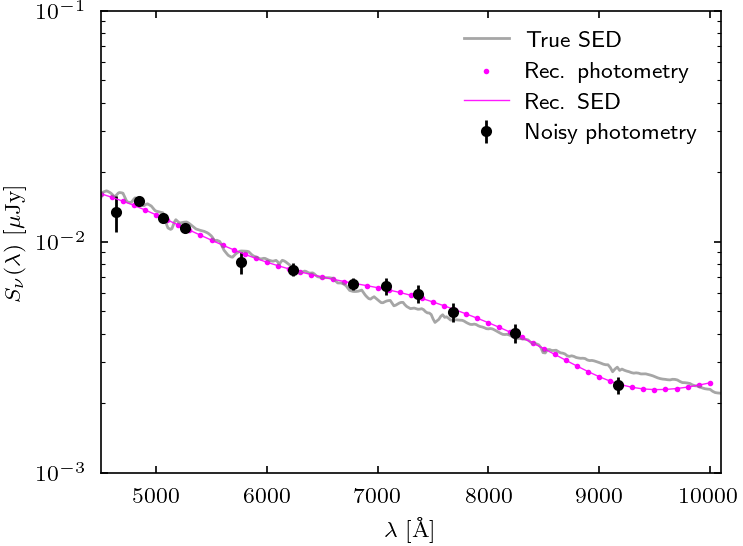

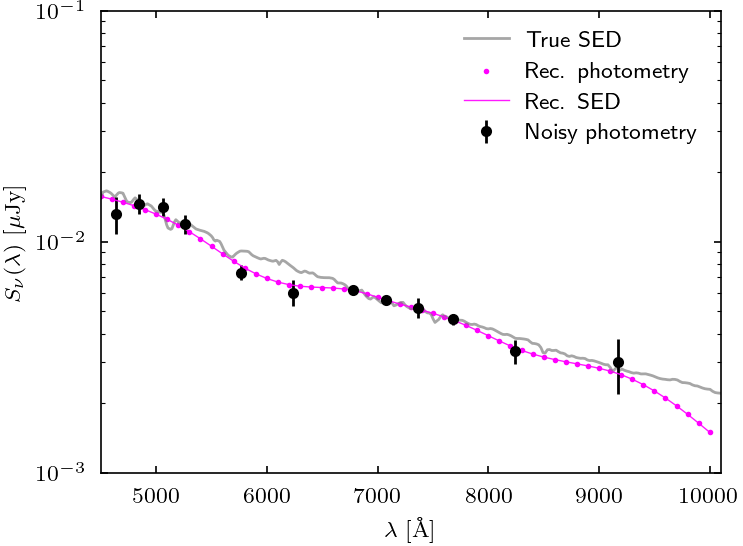

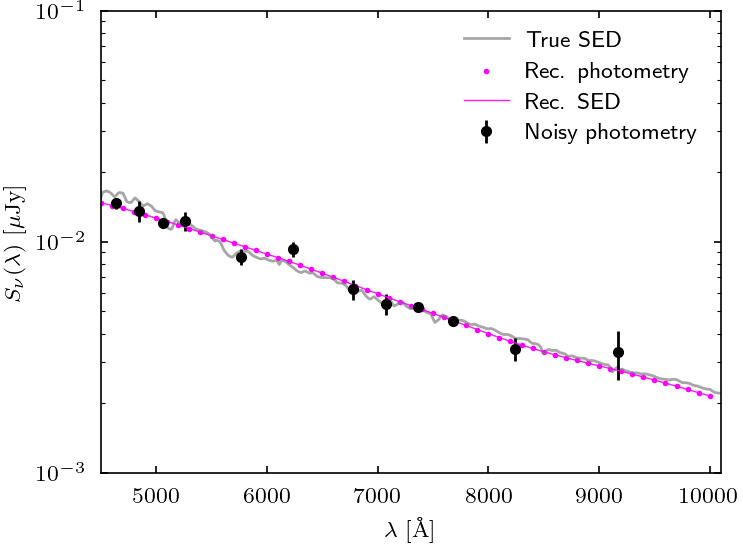

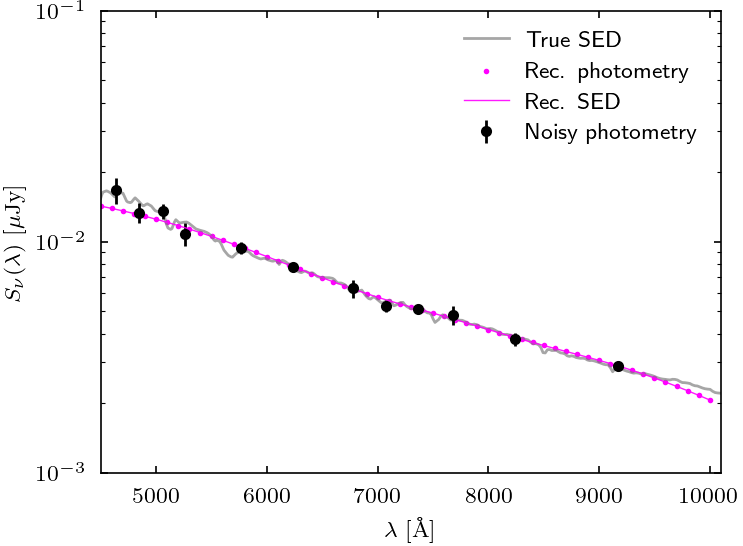

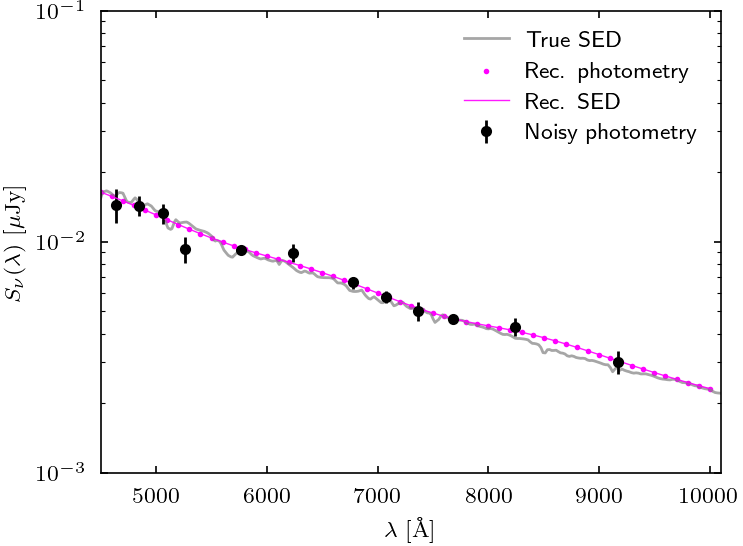

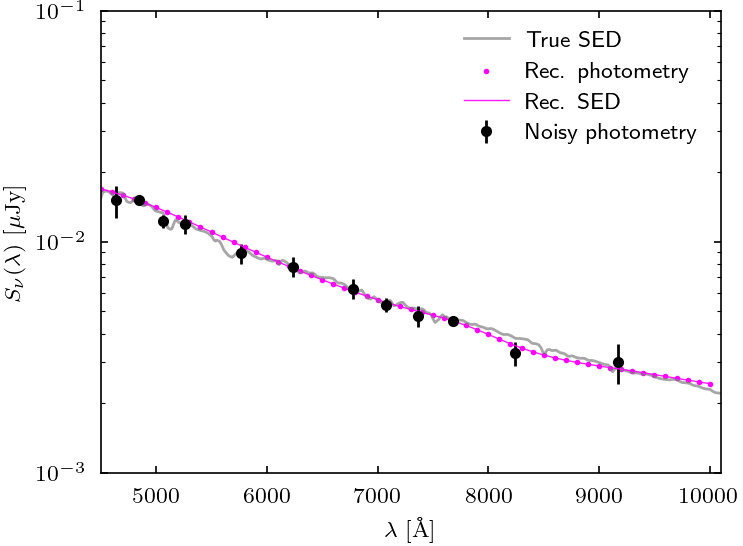

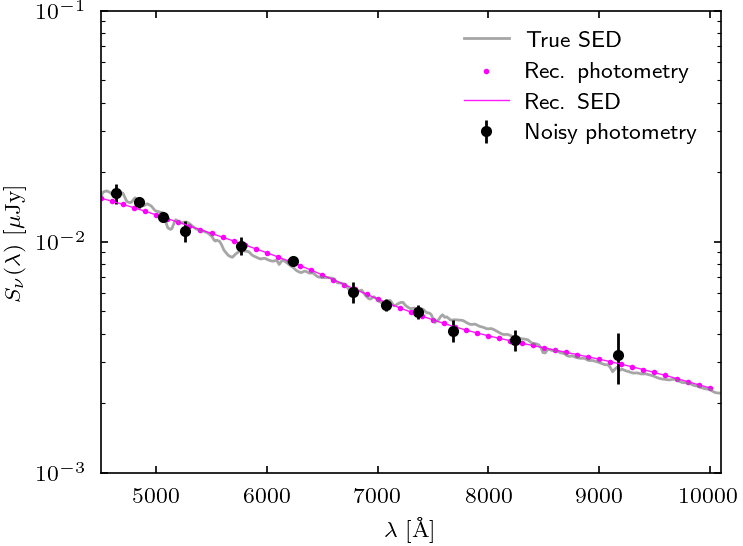

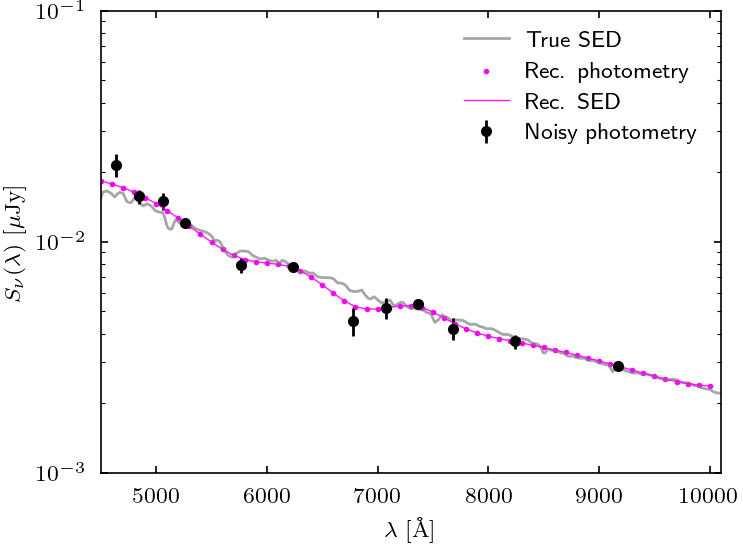

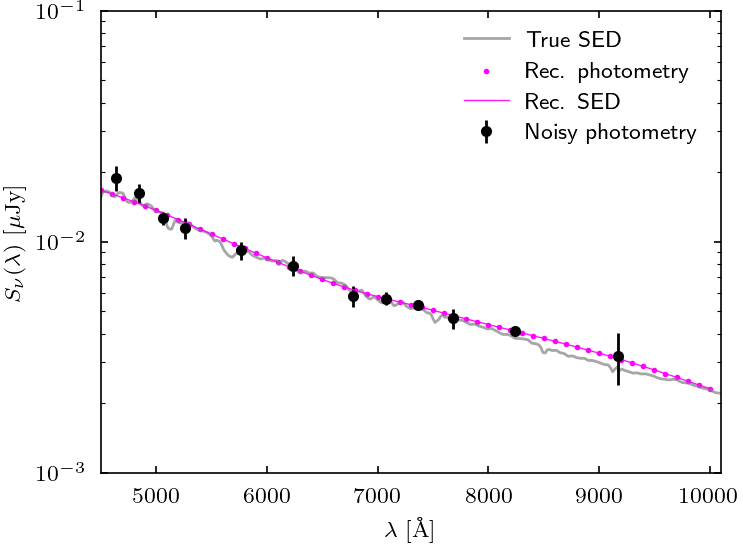

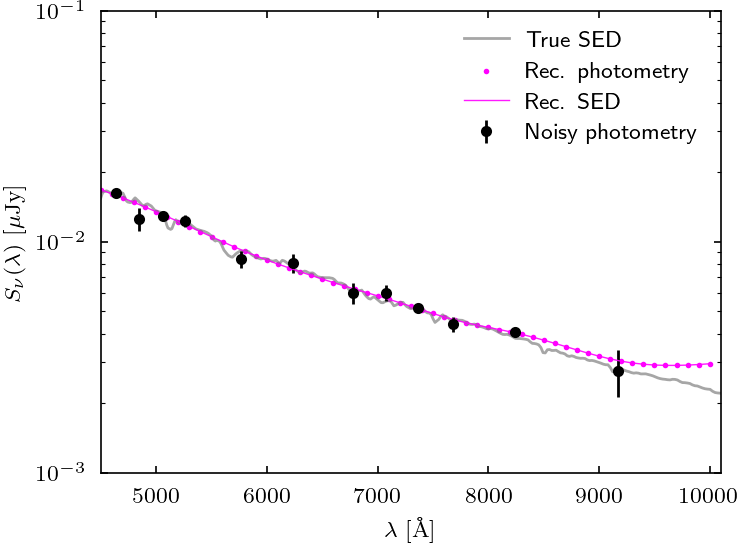

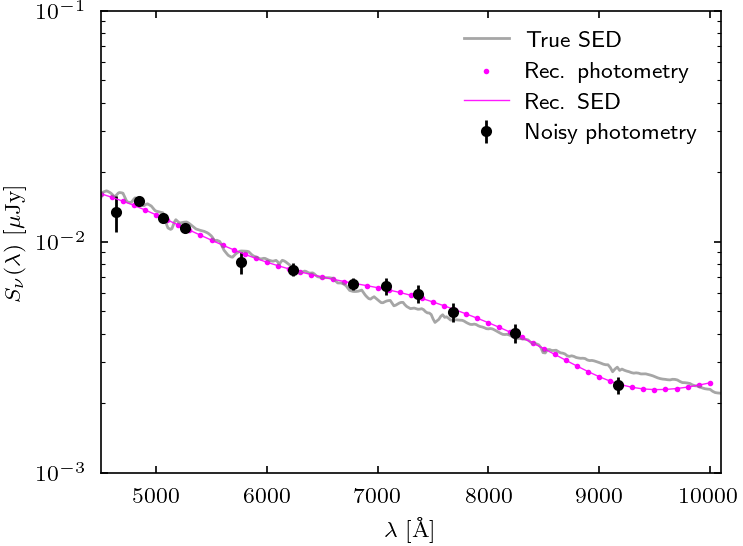

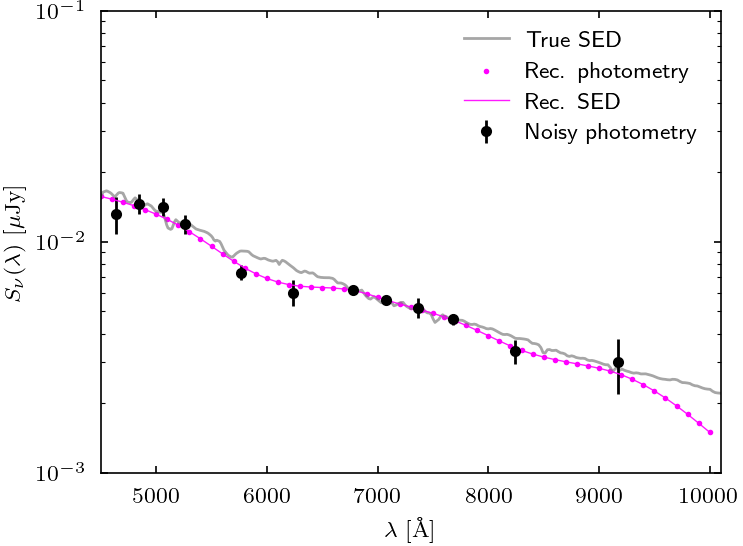

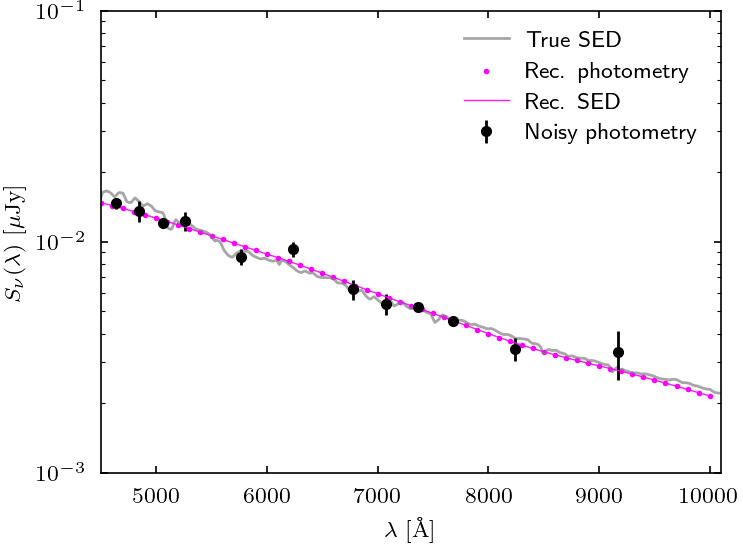

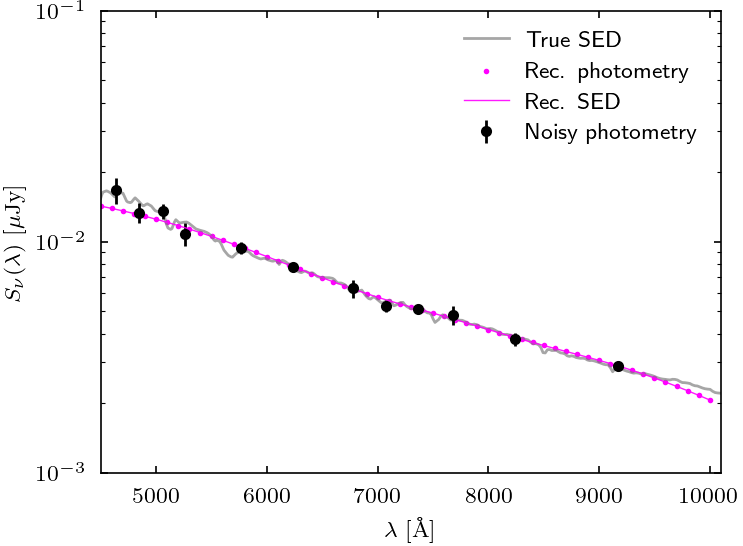

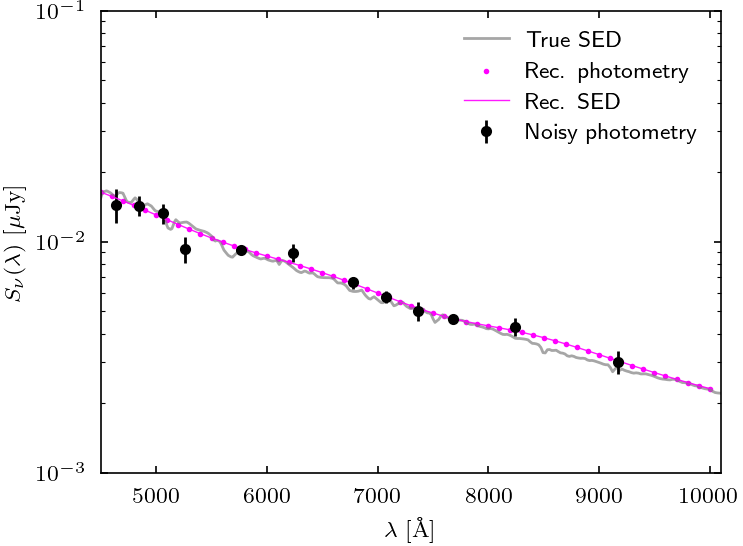

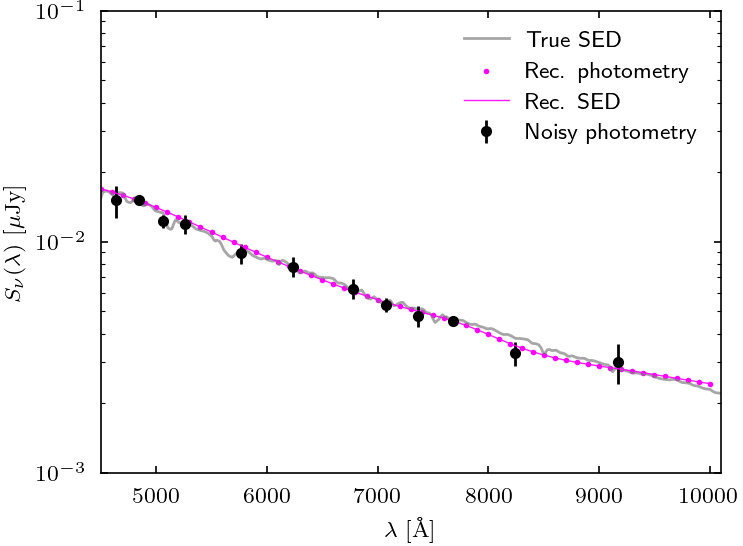

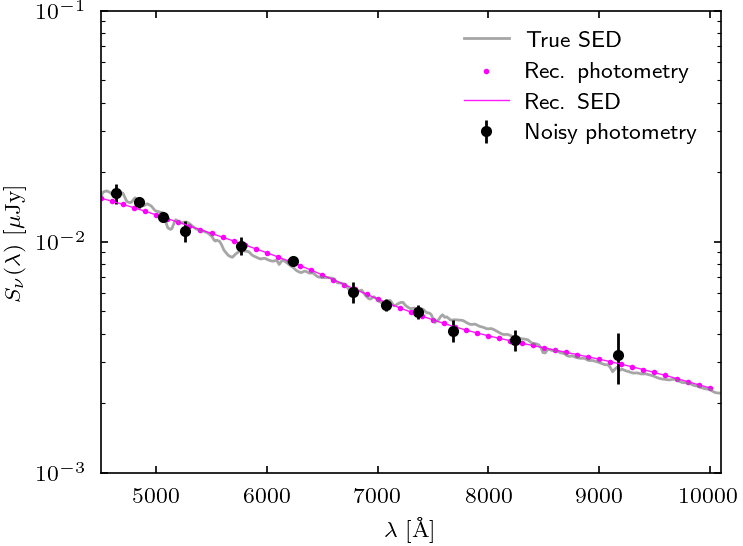

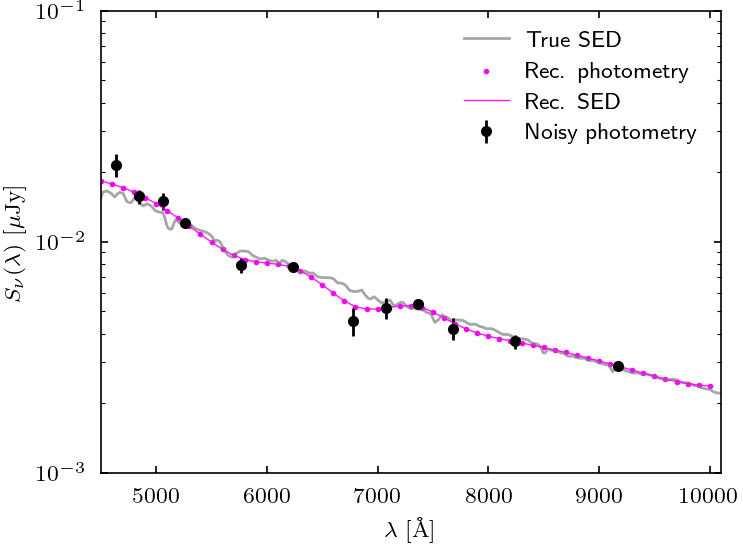

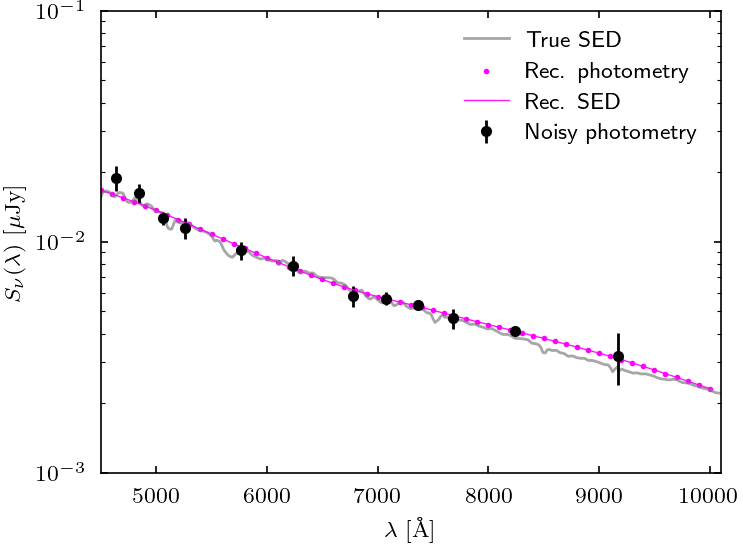

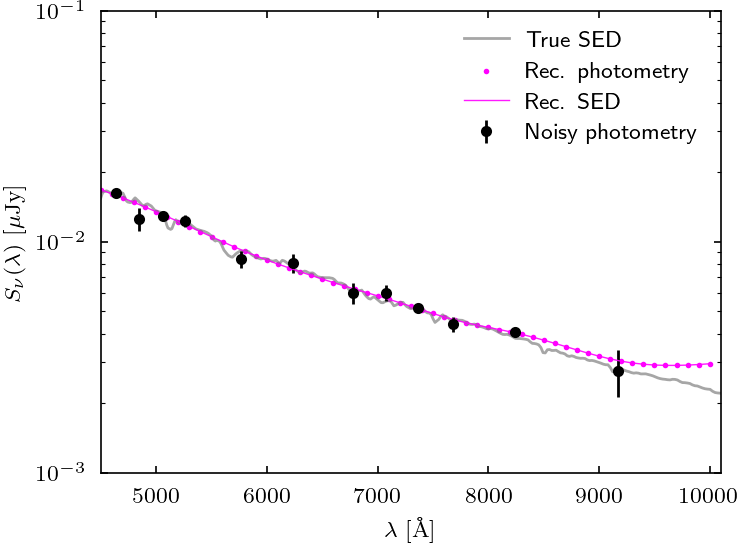

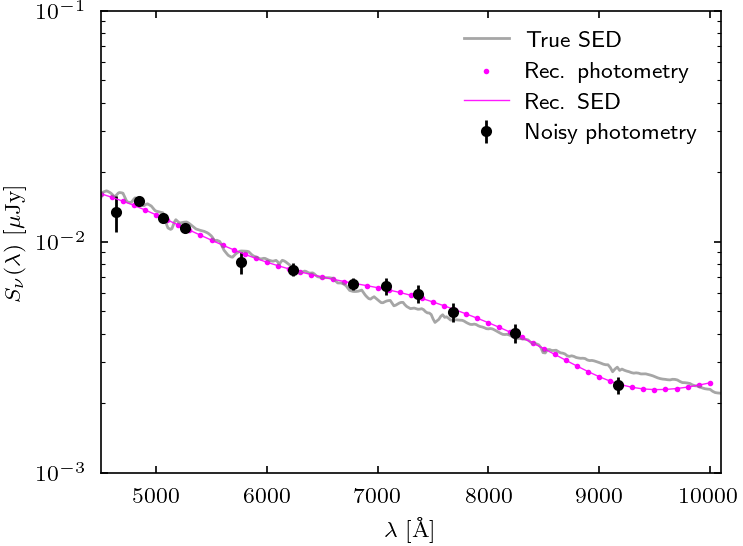

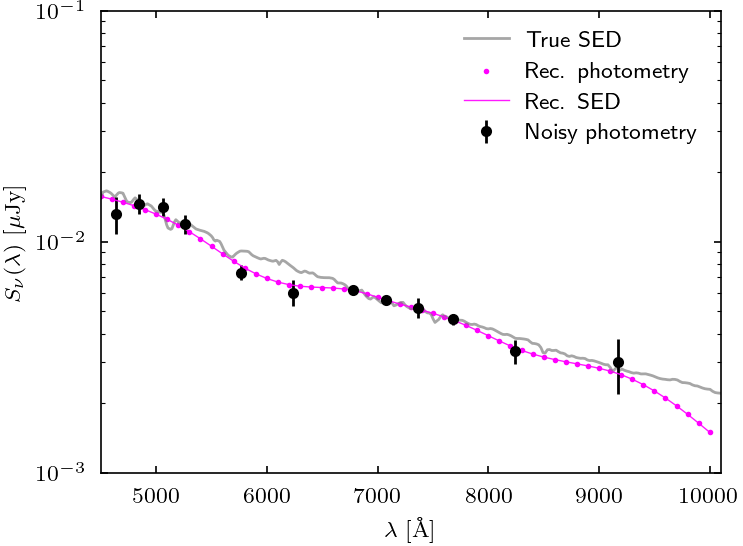

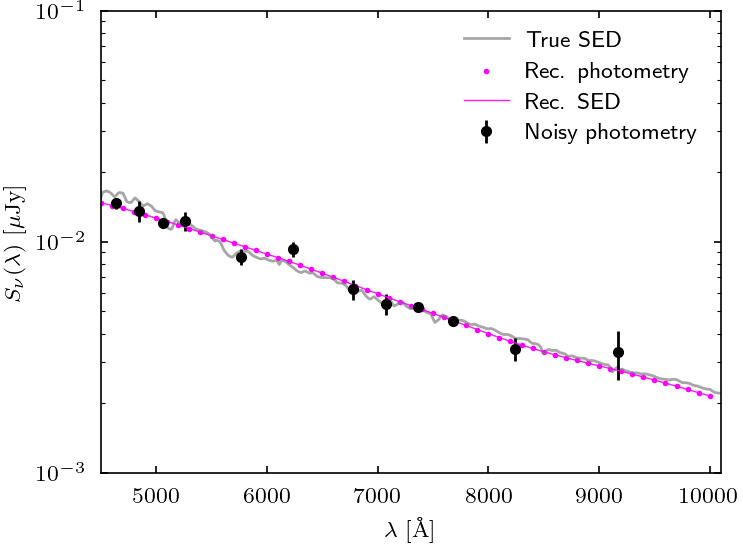

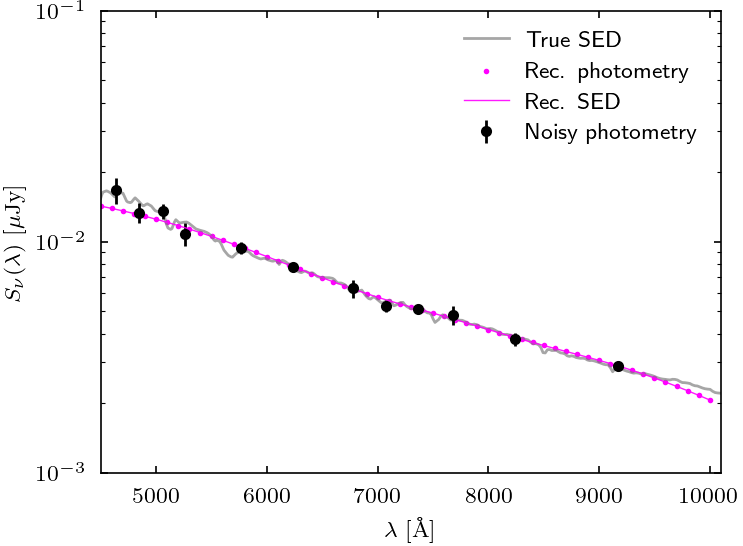

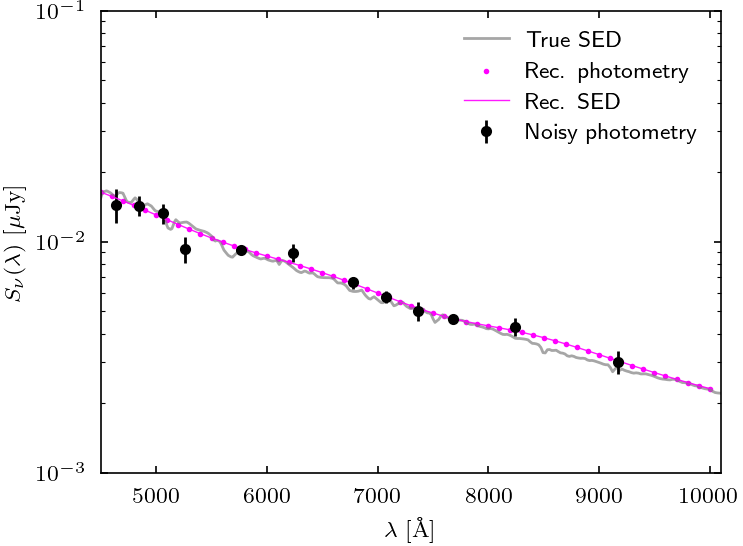

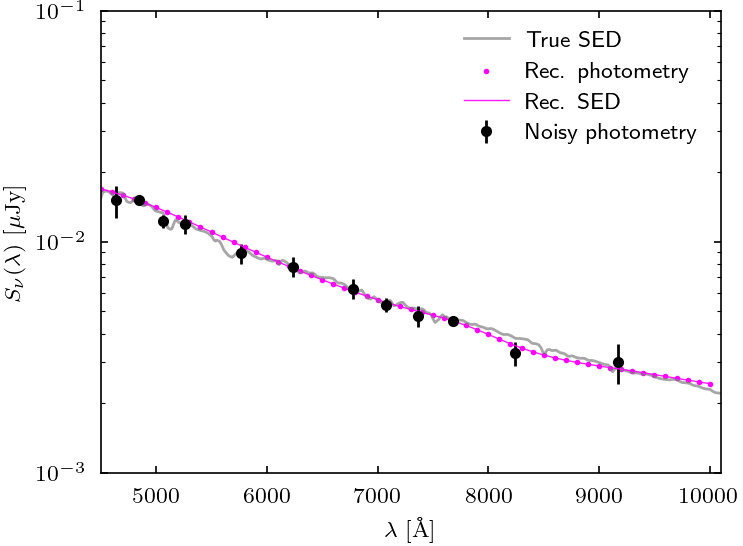

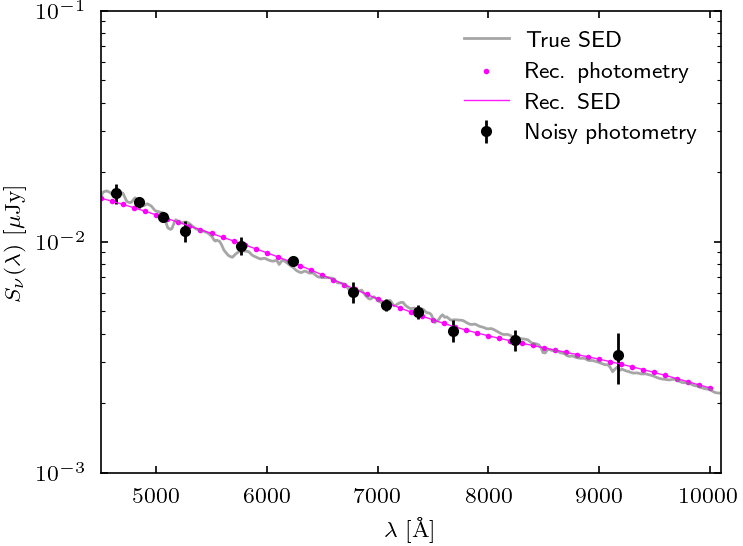

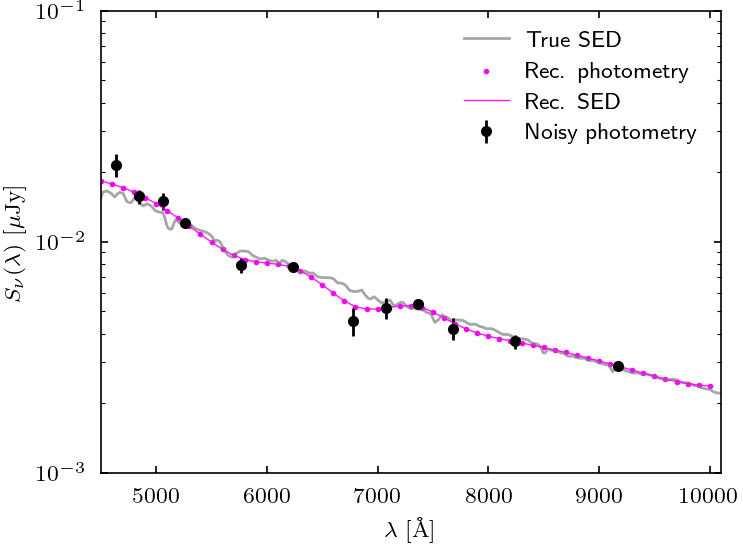

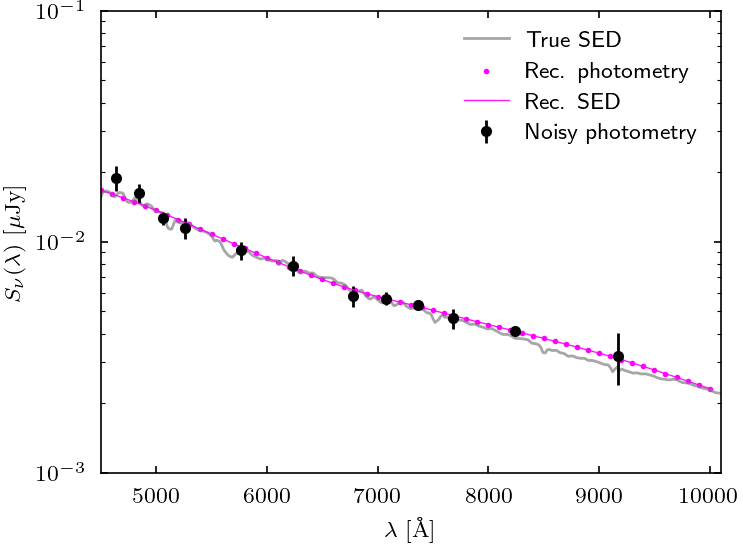

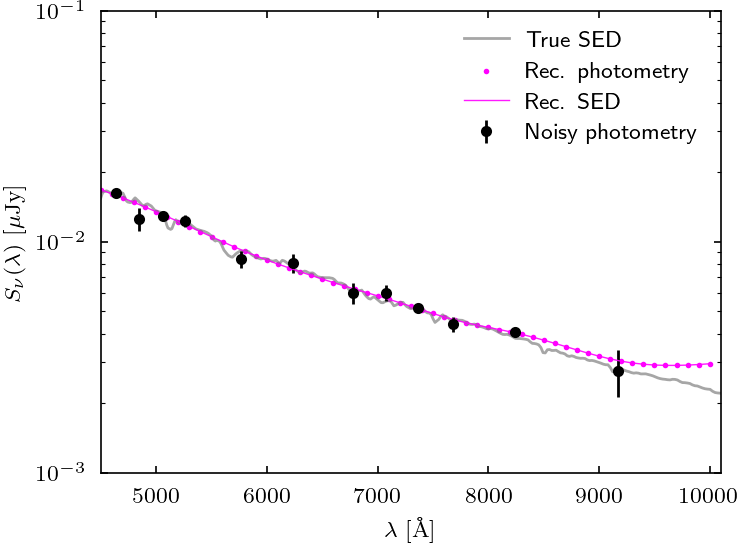

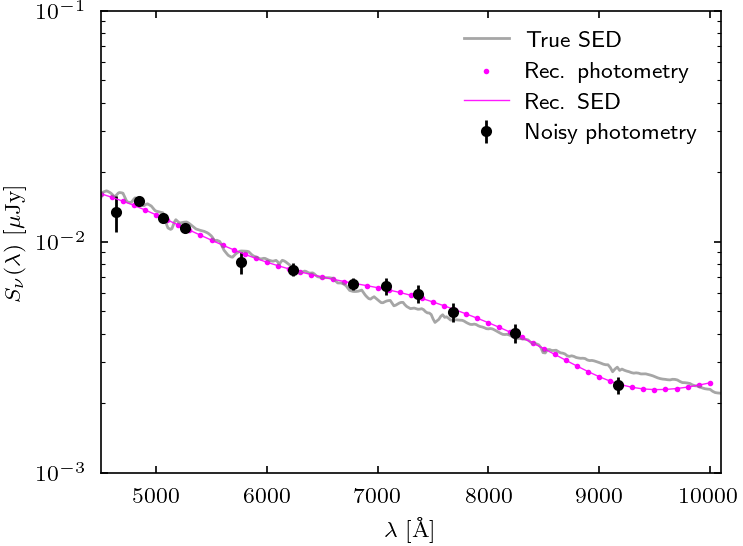

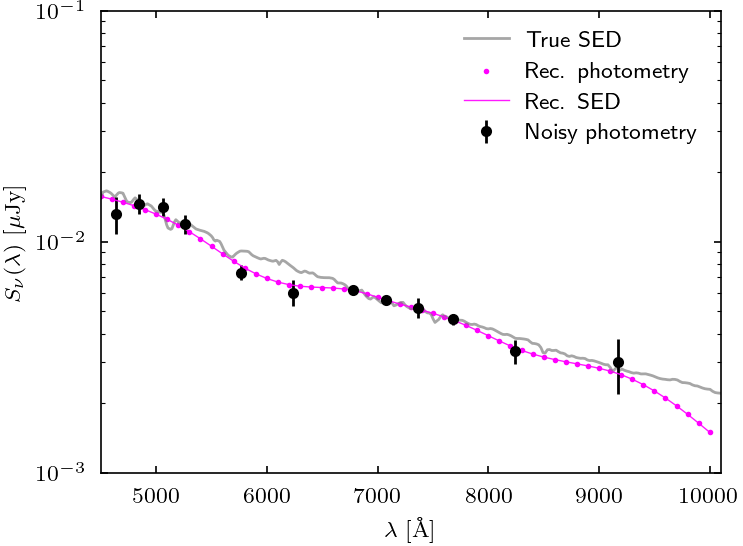

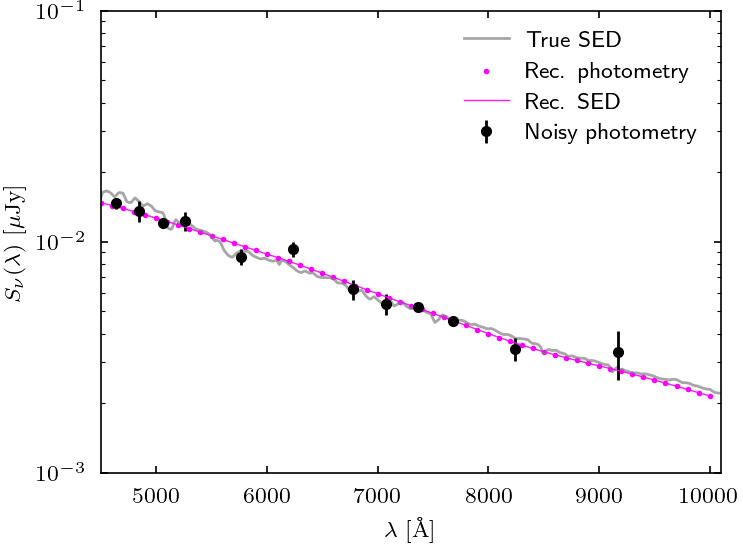

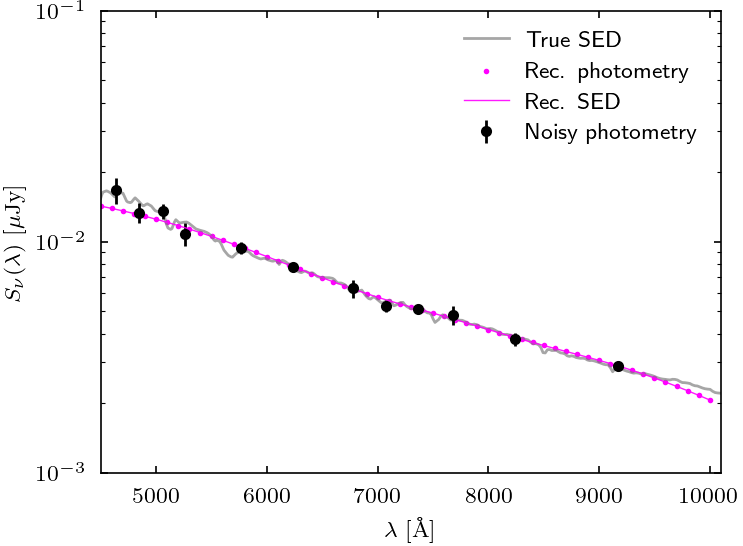

In [27]:
for n in range(0, len(row_sel)):
    row = row_sel.iloc[n]
    halo_id   = int(row["halo_id"])
    galaxy_id = int(row["galaxy_id"])
    
    # 1) Build the true SED
    wave_obs, F_obs = build_flagship_sed(row, templates, ext_laws)
    

    for n in range(0, 10):
        # 2) Retrieve the noisy flux points and plot them
        flux_noisy = []
        sigma_per_band = []
        for i in range(0, len(phot_cols)):
            flux_noisy.append(row_sel[phot_cols[i]][n])
            sigma_per_band.append(row_sel[phot_cols_err[i]][n])
        flux_noisy = np.array(flux_noisy)
        sigma_per_band = np.array(sigma_per_band)

        # 3) Read the reconstructed flux points and interpolate over them
        flux_rec = []
        flux_rec_err = []
        for i in range(0, len(gp_cols)):
            flux_rec.append(row_sel[gp_cols[i]][n])
            flux_rec_err.append(row_sel[gp_cols_err[i]][n])
        flux_rec = np.array(flux_rec)
        flux_rec_err = np.array(flux_rec_err)

        f_interp = interp1d(gp_waves[5:], flux_rec[5:], kind='linear', bounds_error=False)
        y_fine = f_interp(gp_waves[5:])
    
        # 4) Plot the true SED, the flux points and the reconstructed flux points and SED
        fig, ax = plt.subplots()
    
        # --- True SED
        ax.semilogy(wave_obs, F_obs, color="gray", alpha=0.7, label="True SED")
    
        # --- Noisy fluxes
        ax.errorbar(central_lambda, flux_noisy, yerr=sigma_per_band,
                    fmt='o', color="black", markersize=3, label="Noisy photometry")

        # --- 55 reconstructed fluxes
        ax.scatter(gp_waves[5:], flux_rec[5:], color="magenta", s=1, label="Rec. photometry")
        ax.plot(gp_waves[5:], y_fine, color="magenta", lw=0.5, alpha=0.9, label="Rec. SED")
    
        ax.set_xlim(4500, 10100)
        ax.set_ylim(1e-3, 1e-1)
        ax.set_xlabel(r"$\lambda\ [\mathrm{\AA}]$")
        ax.set_ylabel(r"$S_\nu (\lambda)\ [\mu\mathrm{Jy}]$")
        ax.legend(frameon = False)
        plt.show()

### B) Example of how to reconstruct the SED from the .fits catalogue

In [29]:
# Access the catalogue
tab = fits.open("../data/gp_sed_reconstructions.fits")[1].data
# tab = fits.open("../gp_sed_reconstructions.fits")[1].data

In [30]:
# Select the first galaxy, for which we have 10 noisy realisations
halo_id_sel = tab['halo_id'][0]
print(halo_id_sel)
row_sel = tab[tab['halo_id']==halo_id_sel]
row_sel

5844560344819


FITS_rec([(5844560344819, 0, 0, 2.657112, 0.01906613, 28, 30, 3, 4, 0., 0., 0.68577623, 0.02129777, 0.00122516, 0.02145452, 0.00220813, 0.01443894, 0.00240381, 0.01430557, 0.00144017, 0.01325814, 0.0012825 , 0.00925934, 0.00118823, 0.00921237, 0.00038792, 0.00897463, 7.77587860e-04, 0.00666632, 4.00388840e-04, 0.00578698, 3.53535966e-04, 0.00501446, 4.64086489e-04, 0.00464028, 4.58155148e-05, 0.00427432, 0.00038598, 0.00301522, 3.34148310e-04, 0.00217569, 0.00043469, 0.01967357, 0.01904955, 0.01840646, 0.01774591, 0.0170713 , 0.01638851, 0.01570363, 0.01502269, 0.0143511 , 0.01369383, 0.01305629, 0.01244432, 0.01186471, 0.01132541, 0.01083033, 0.01037782, 0.00996584, 0.0095924 , 0.00925547, 0.00895048, 0.00866913, 0.00840278, 0.00814286, 0.00788125, 0.00761539, 0.00734633, 0.00707514, 0.0068029 , 0.0065307 , 0.00626055, 0.00599658, 0.00574324, 0.00550461, 0.00528411, 0.00508505, 0.00490905, 0.00475538, 0.00462315, 0.00451036, 0.00441204, 0.00432277, 0.00423715, 0.00414976, 0.00405539, 

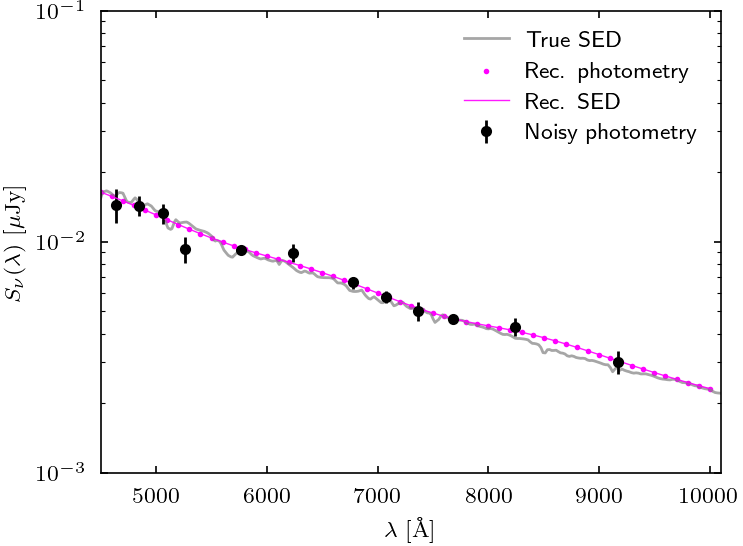

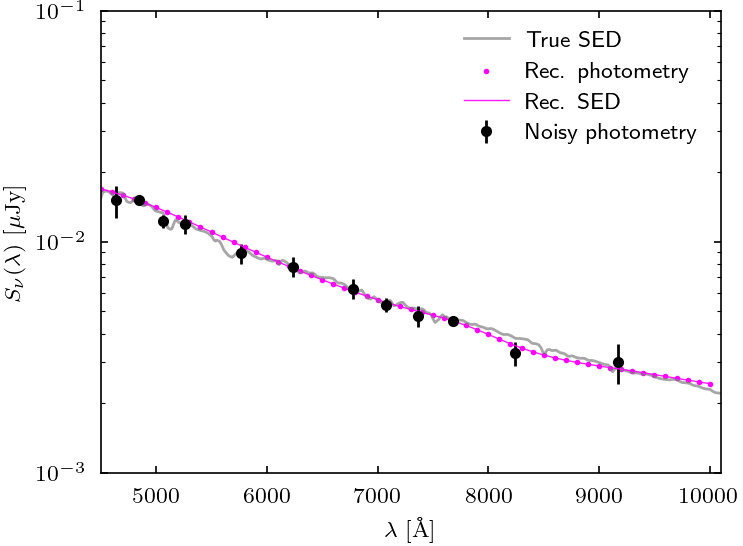

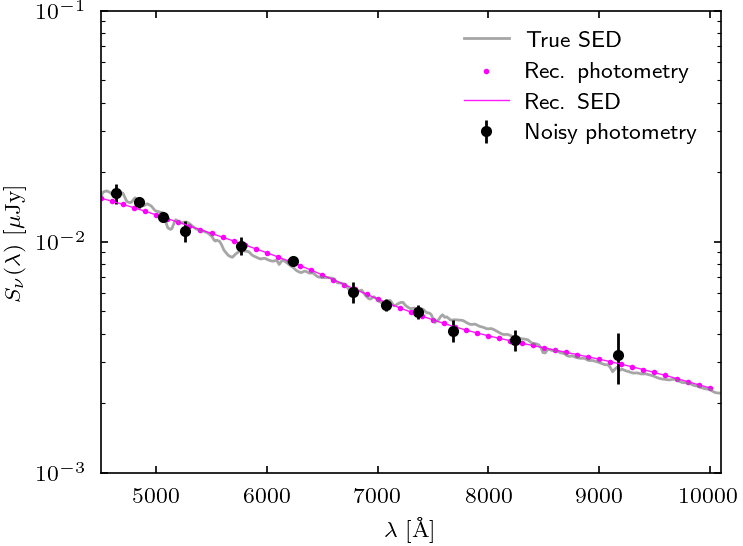

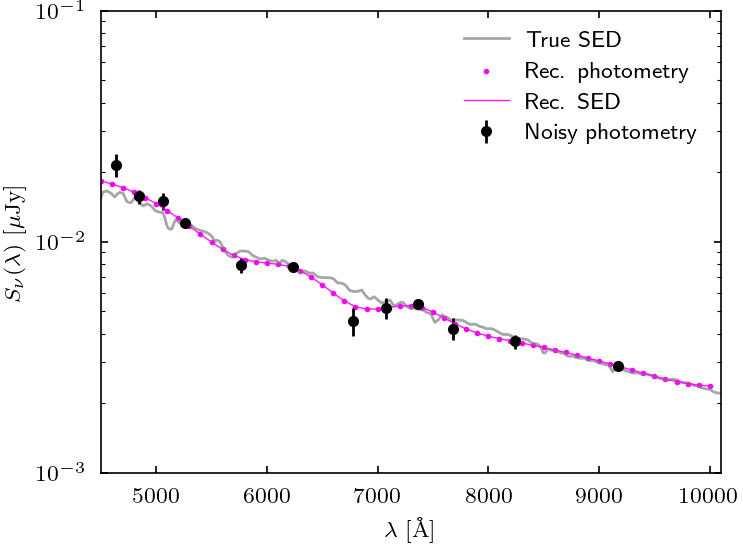

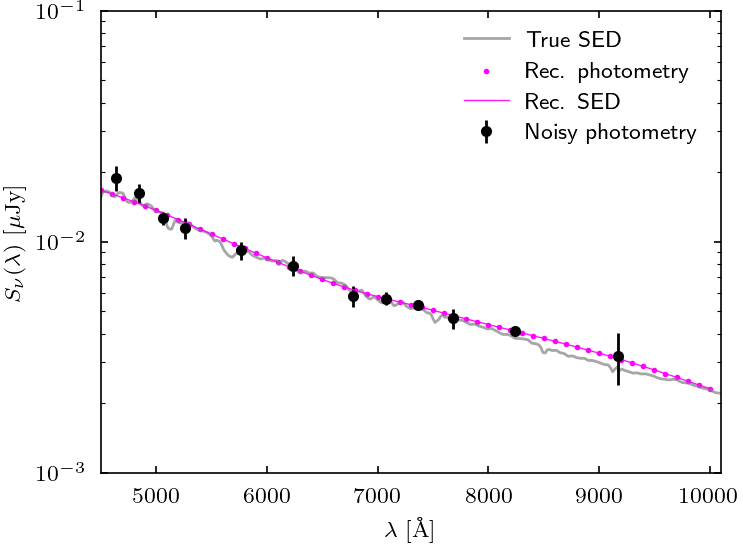

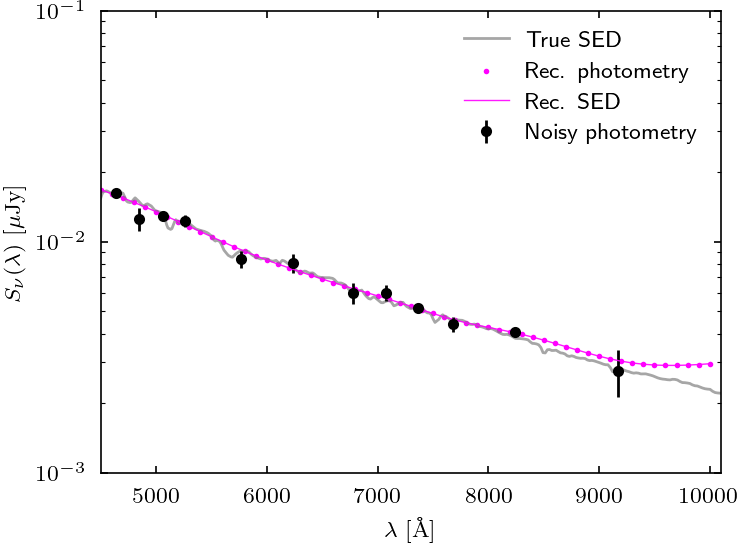

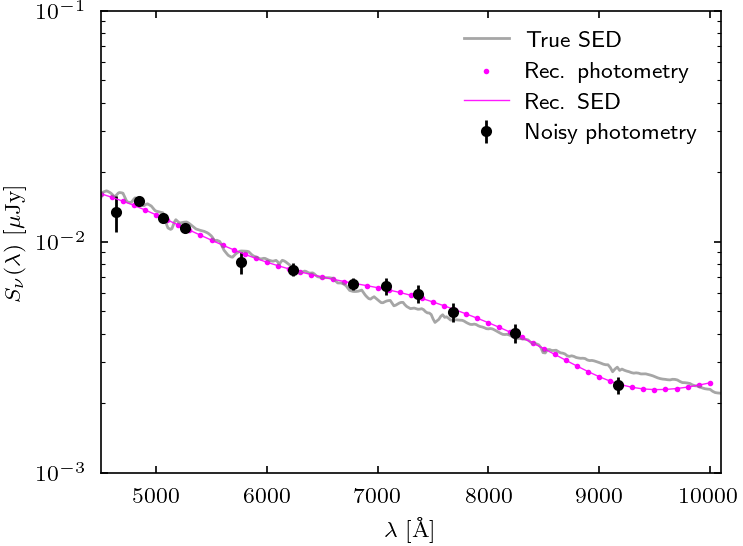

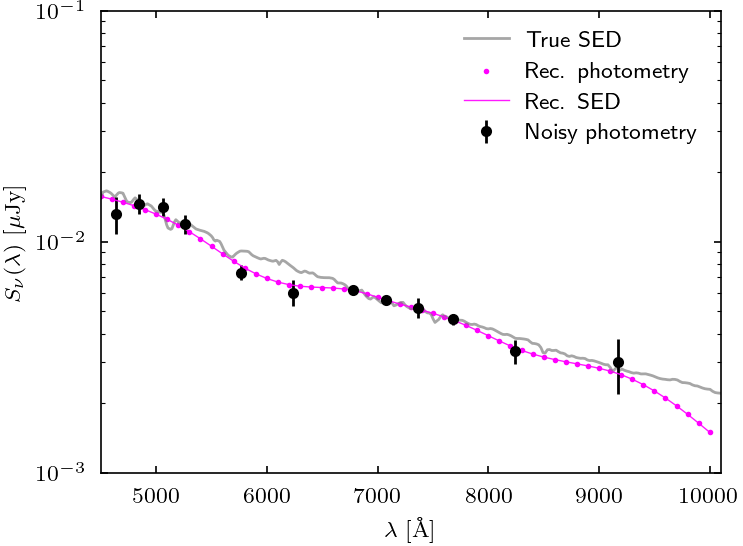

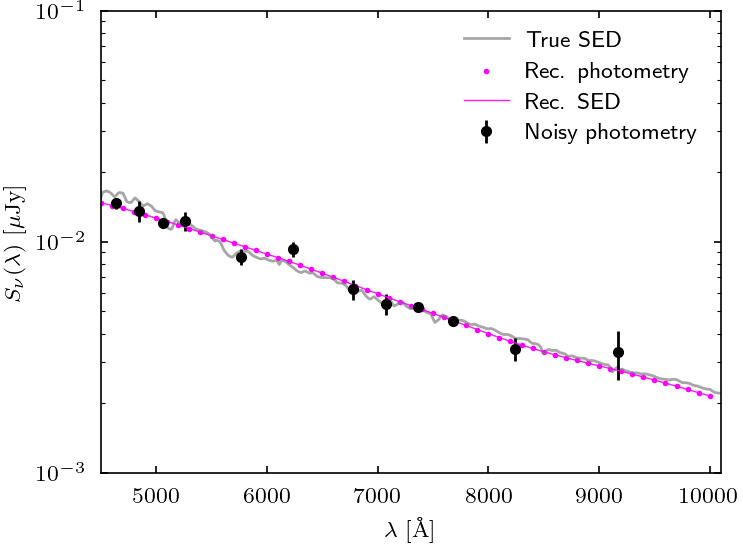

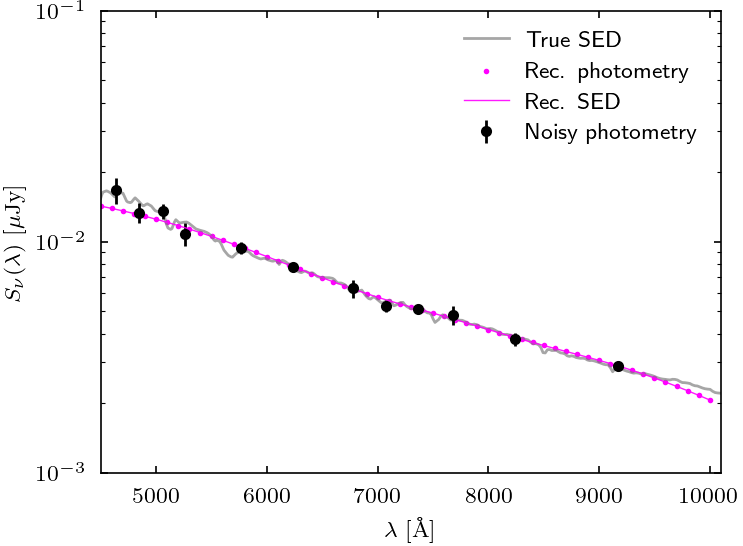

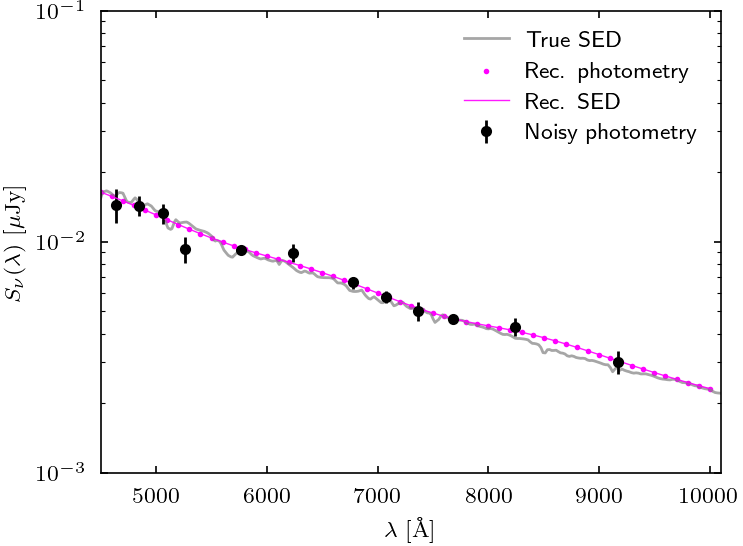

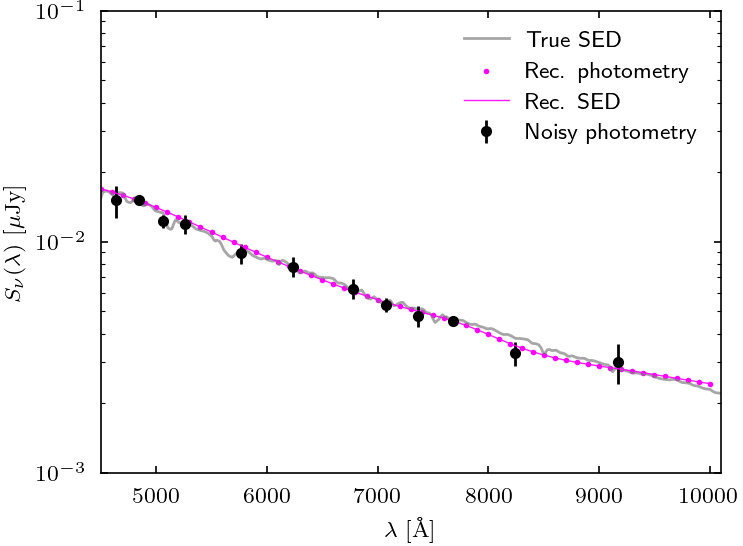

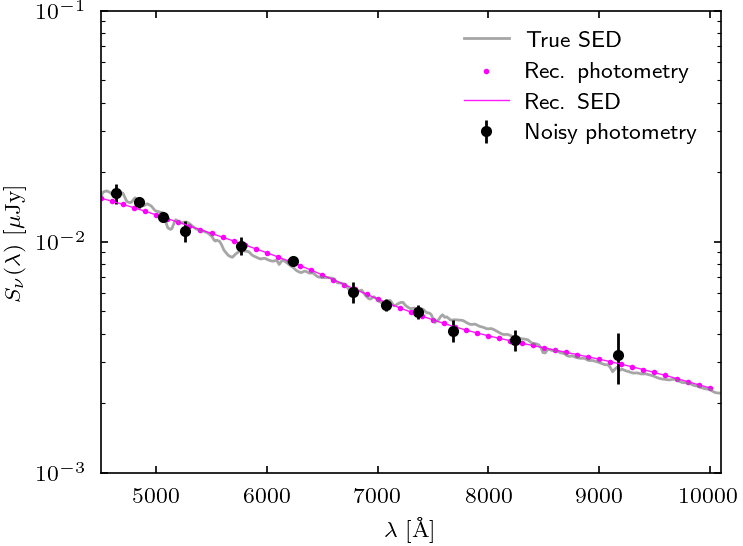

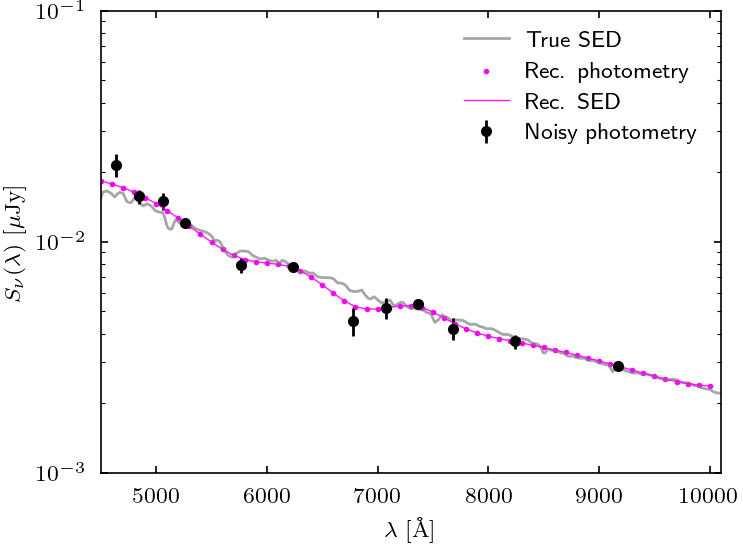

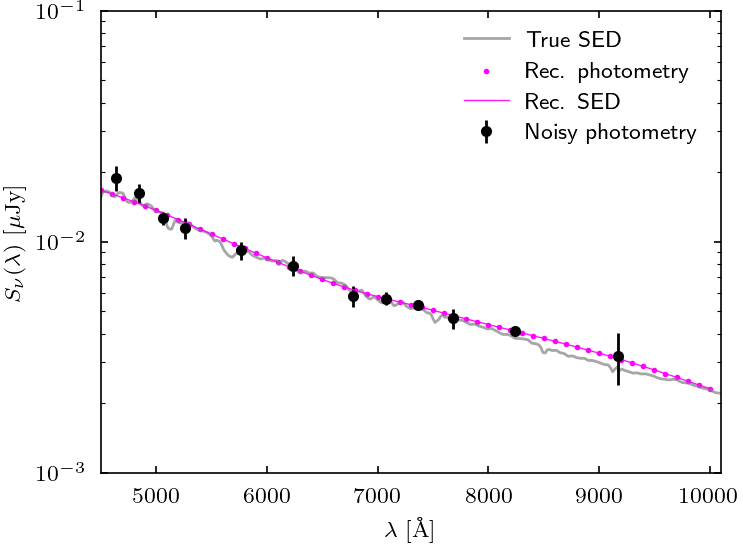

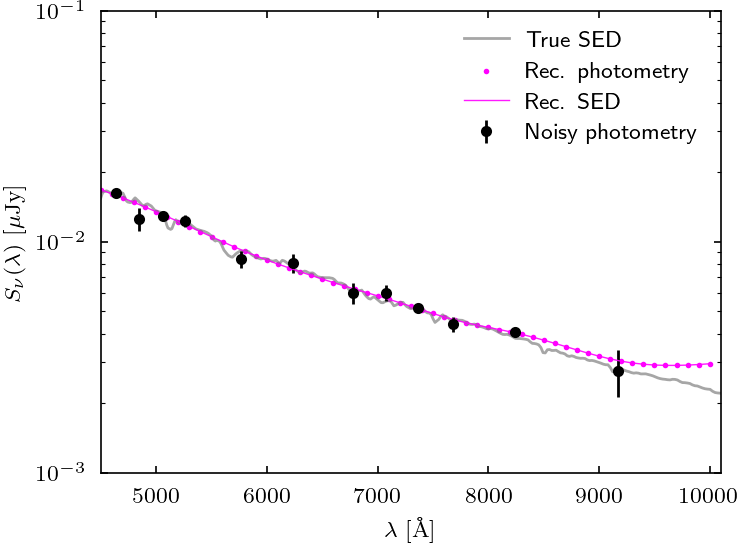

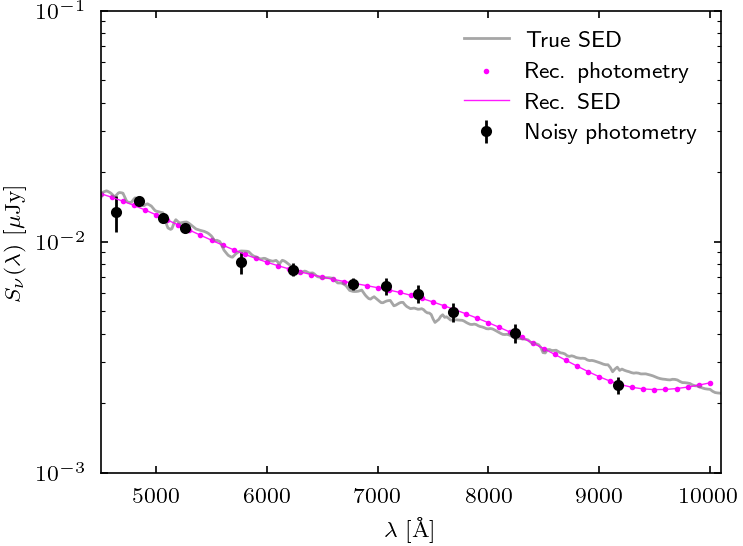

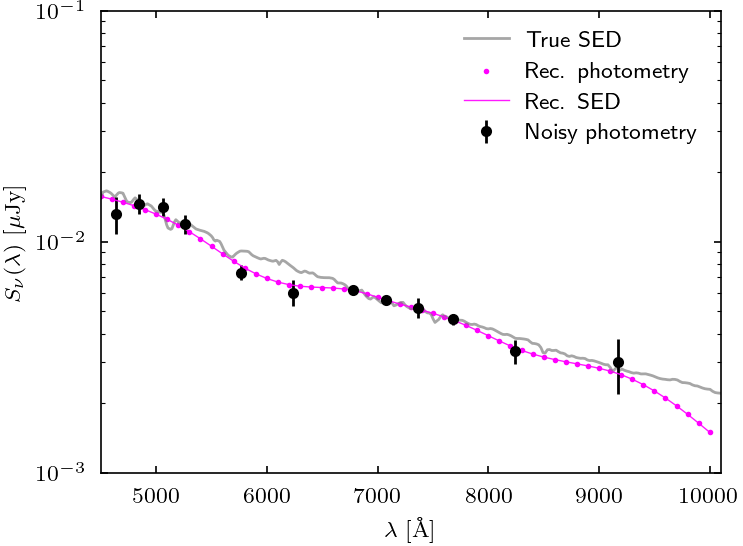

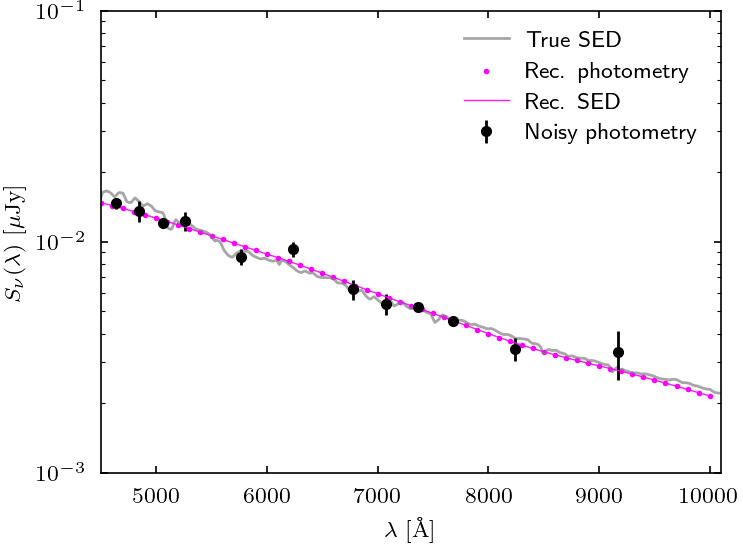

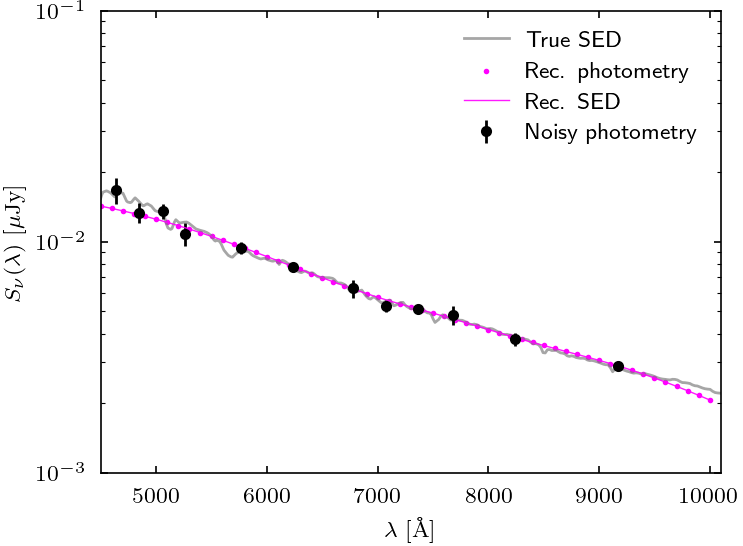

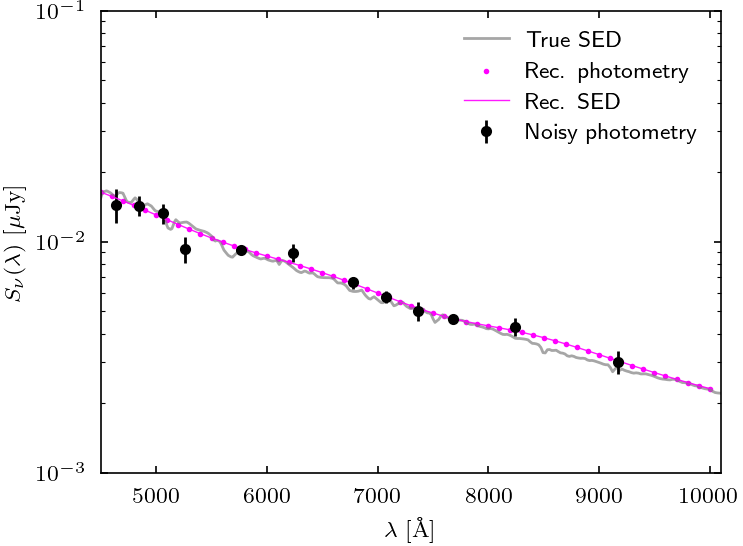

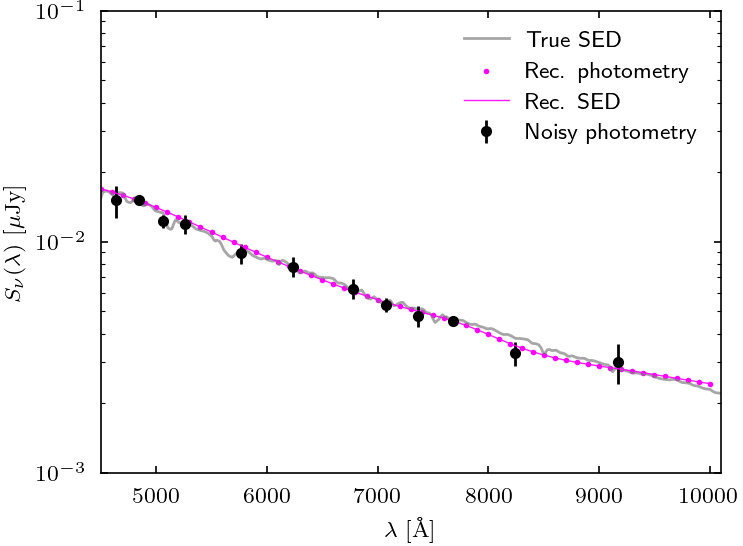

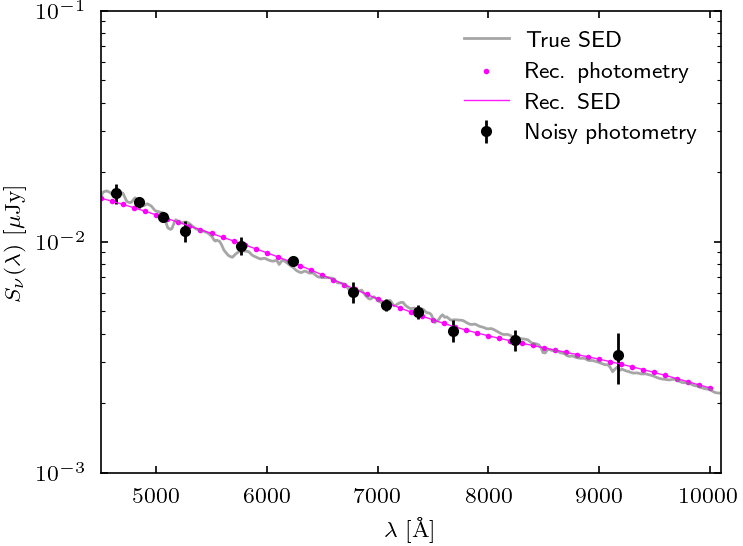

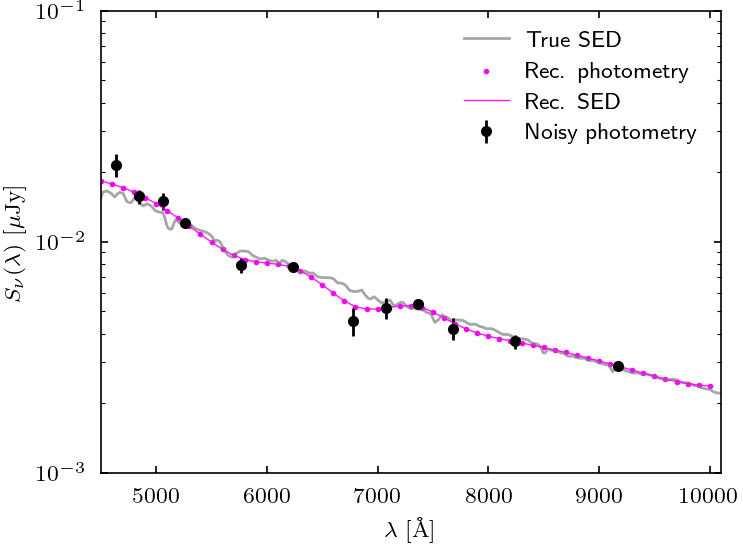

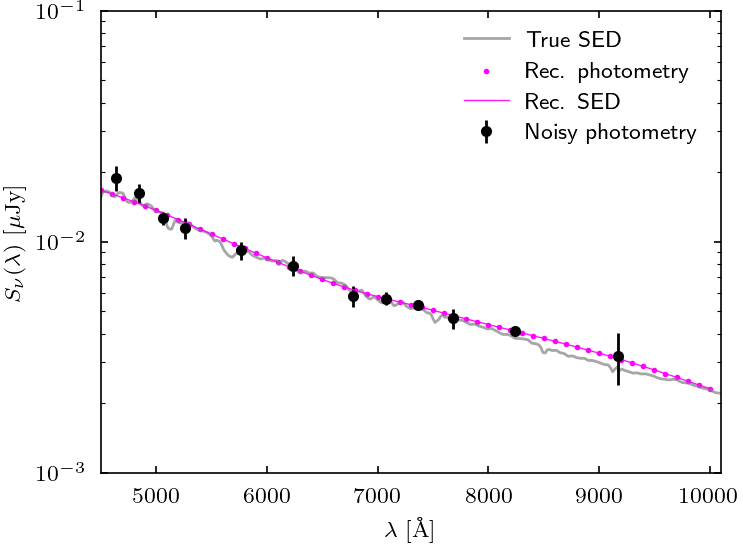

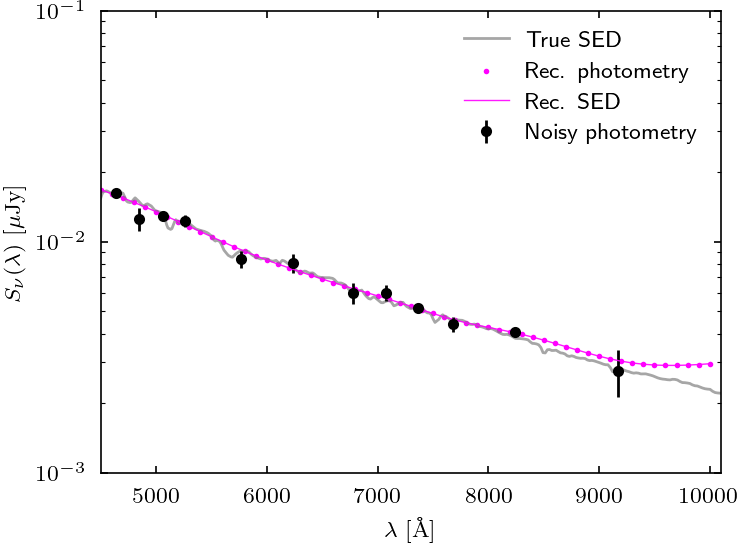

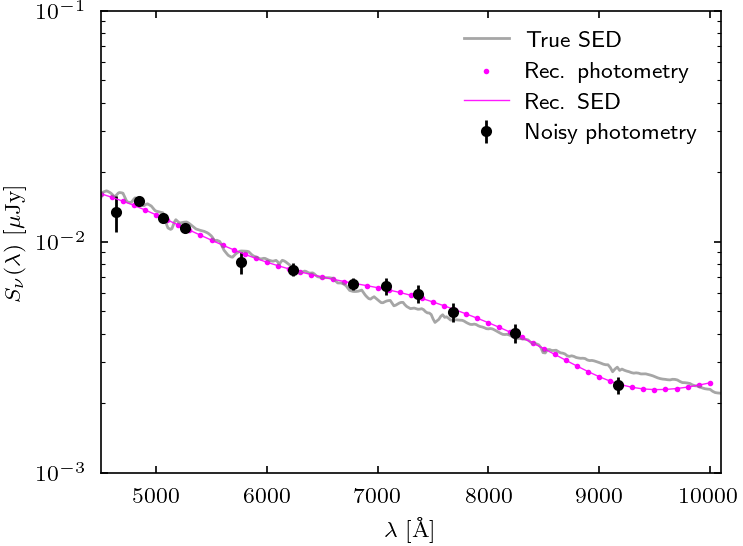

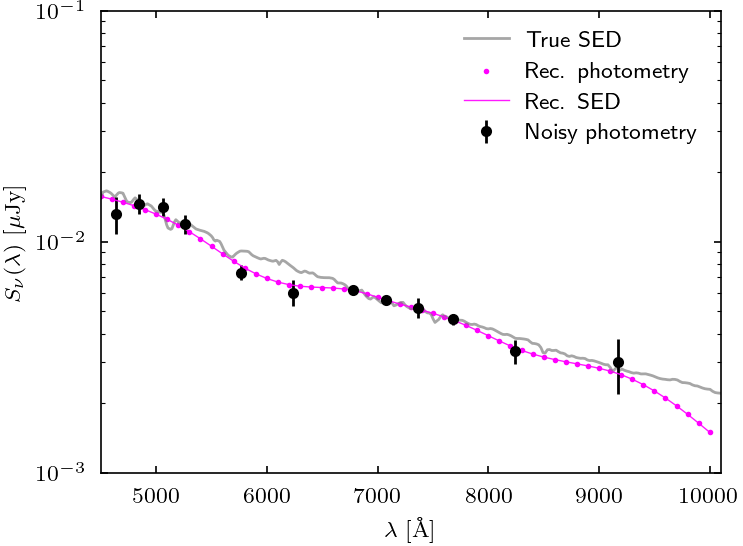

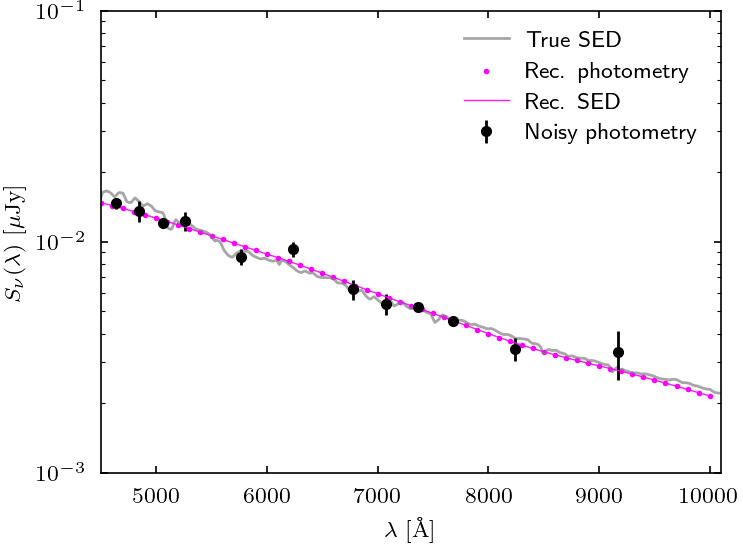

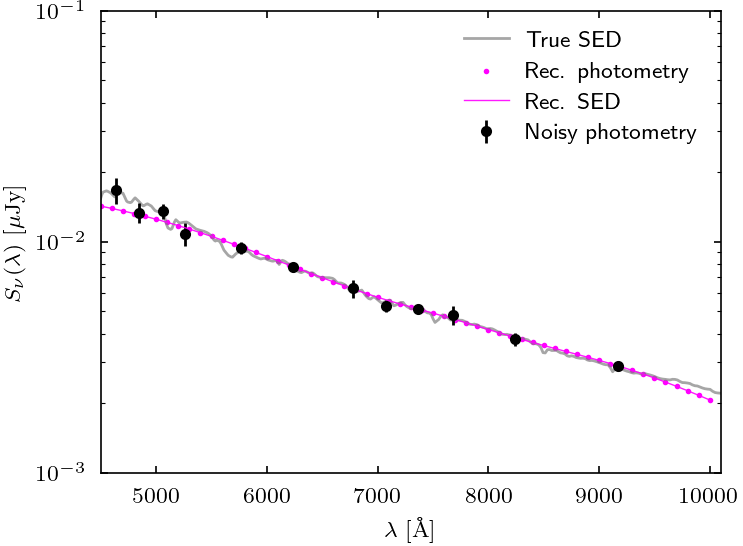

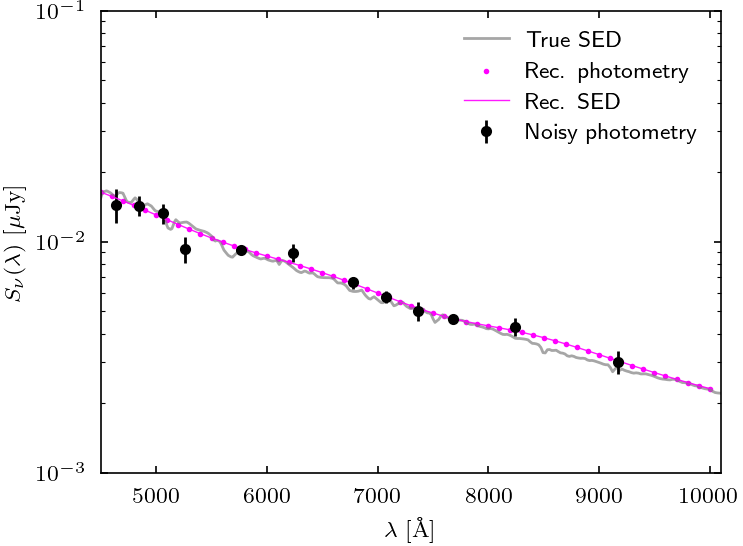

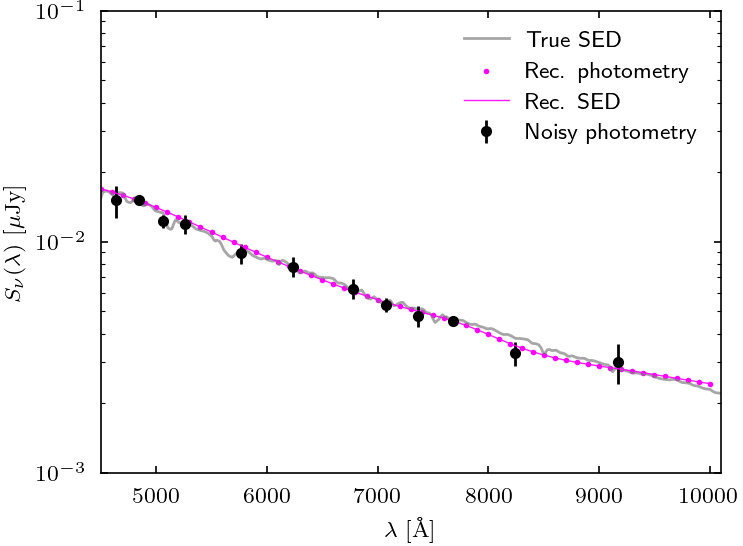

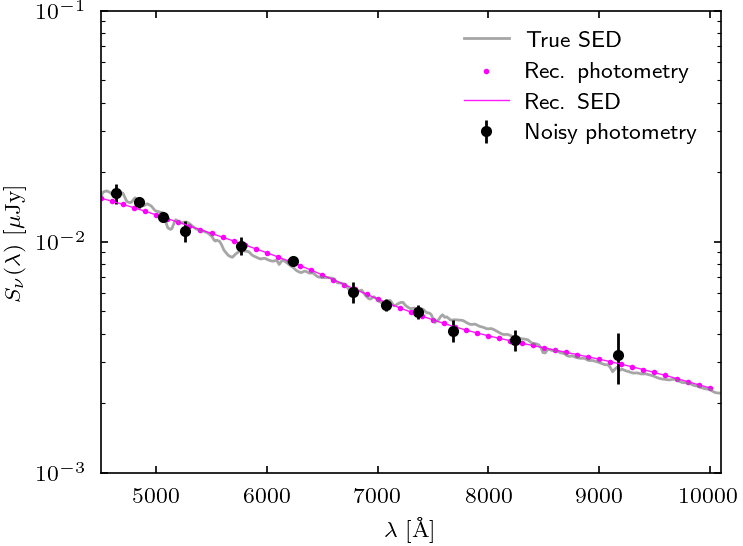

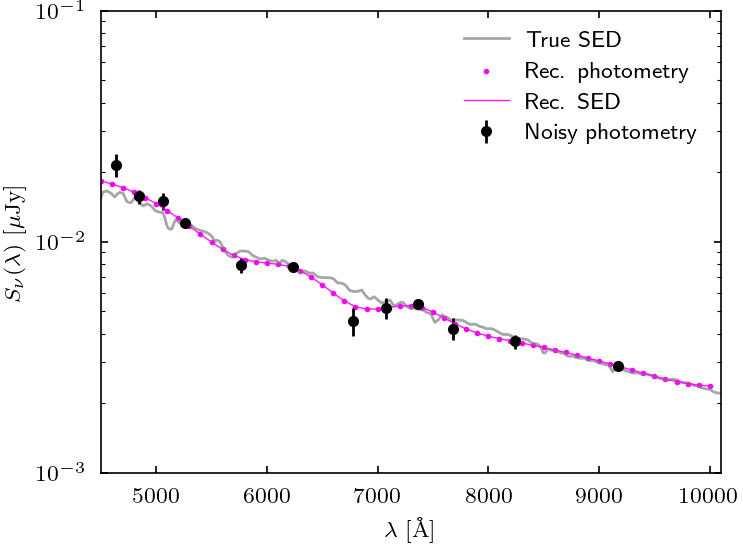

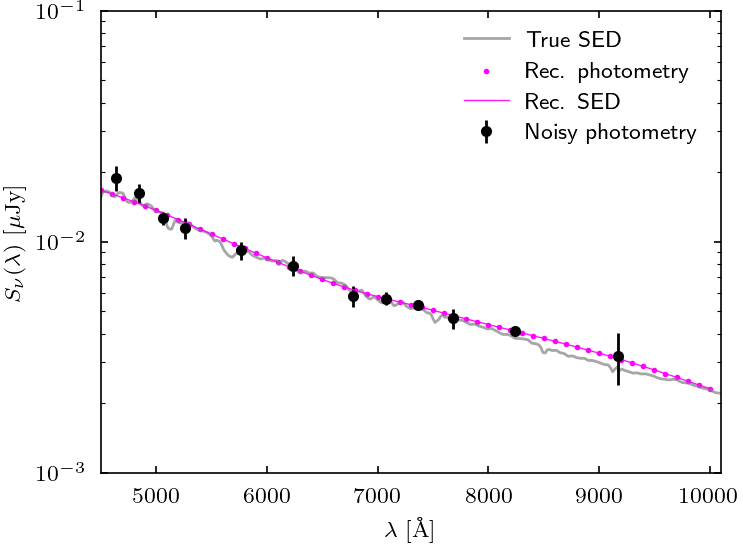

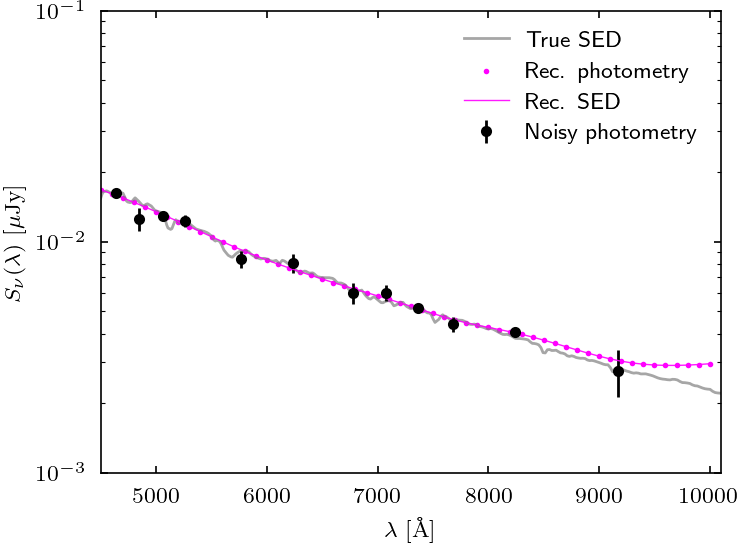

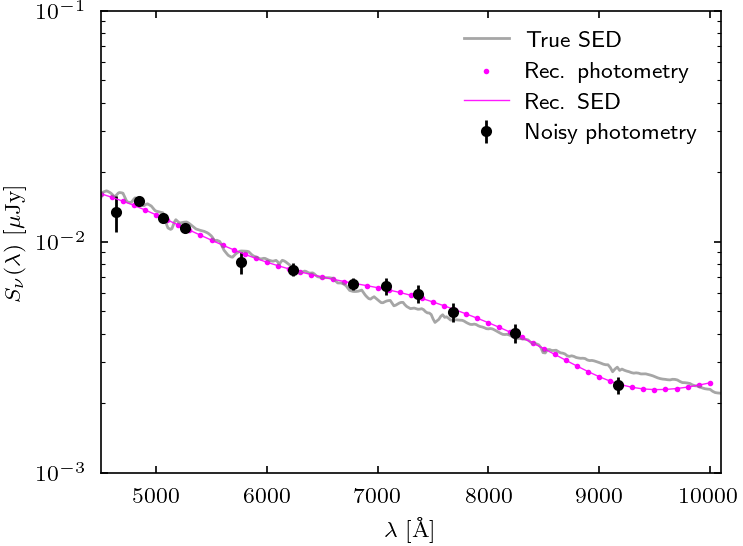

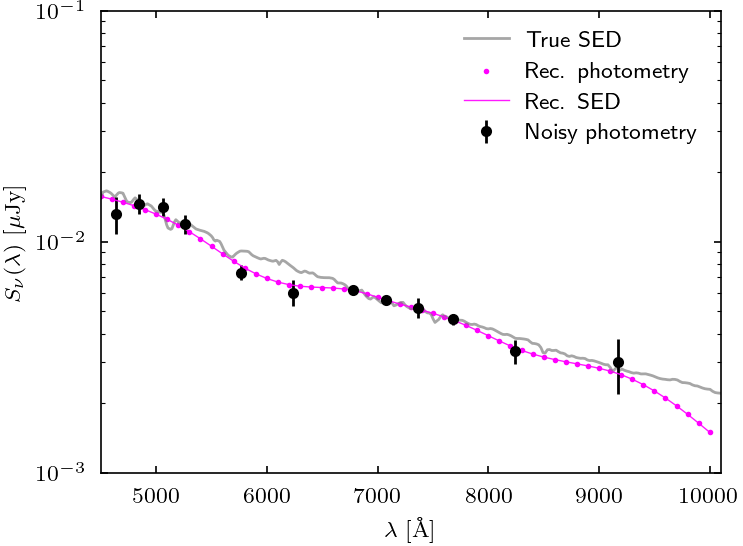

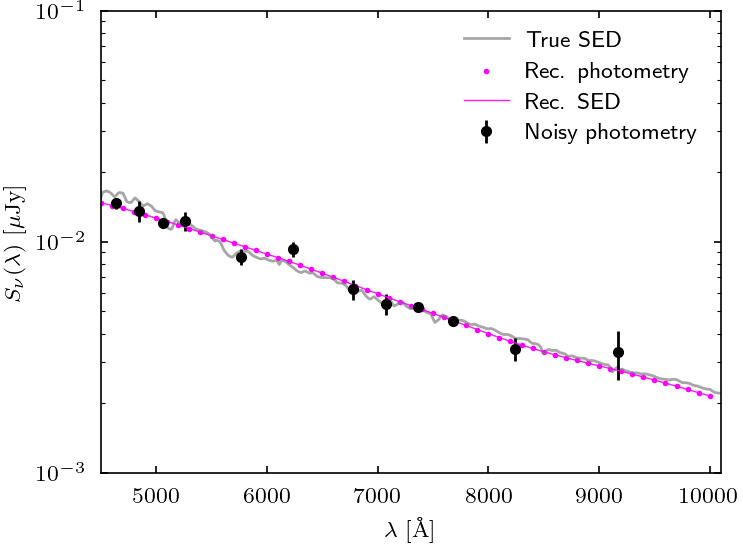

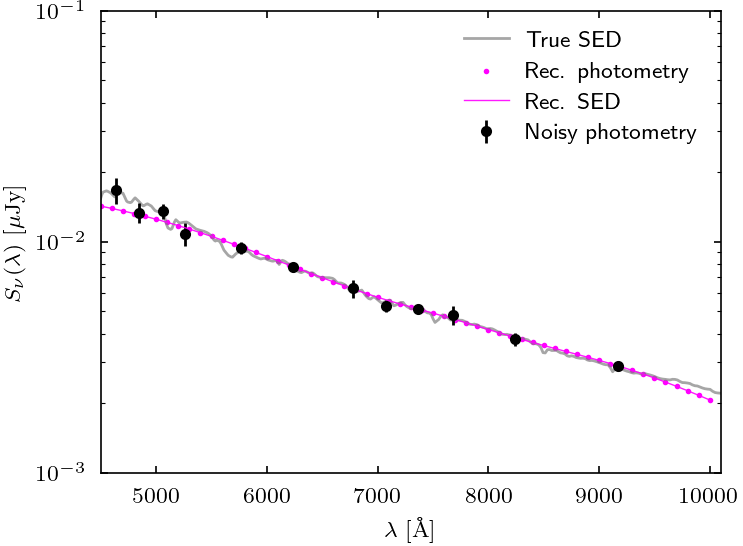

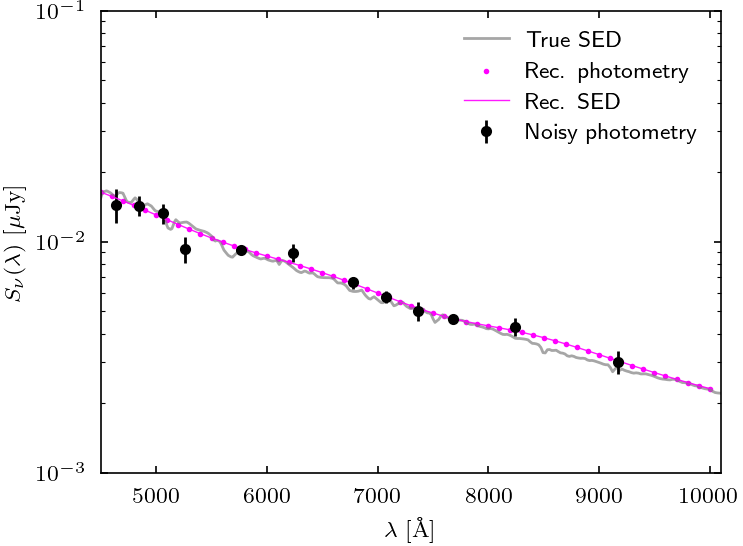

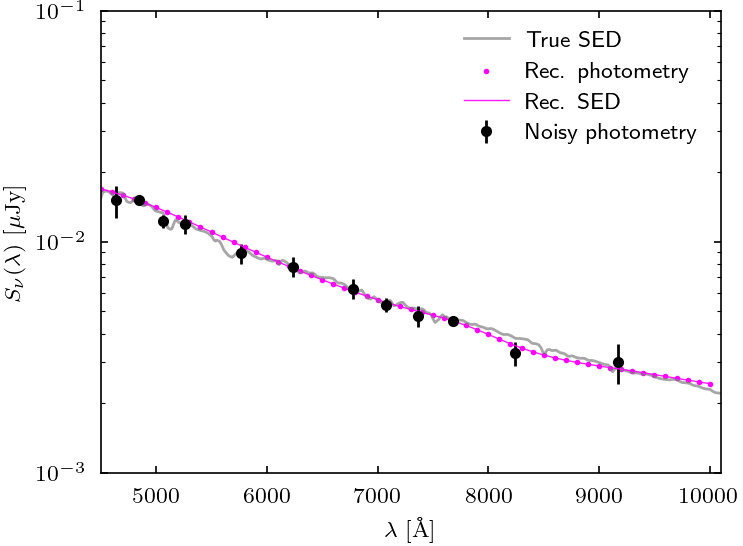

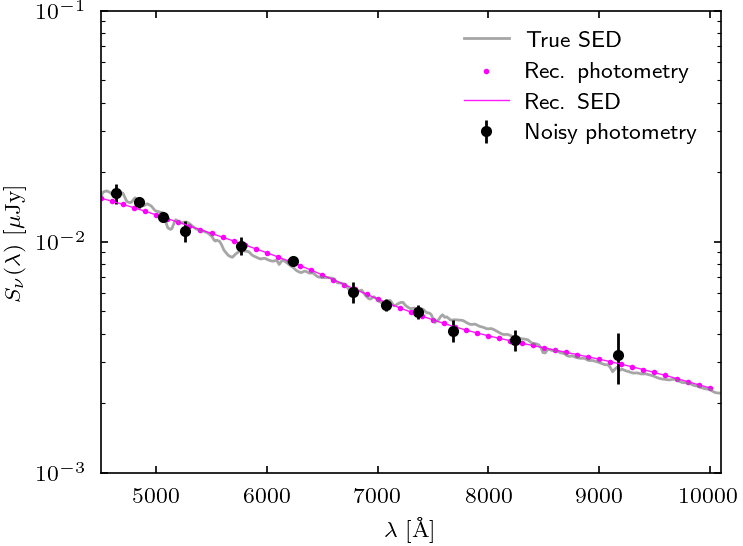

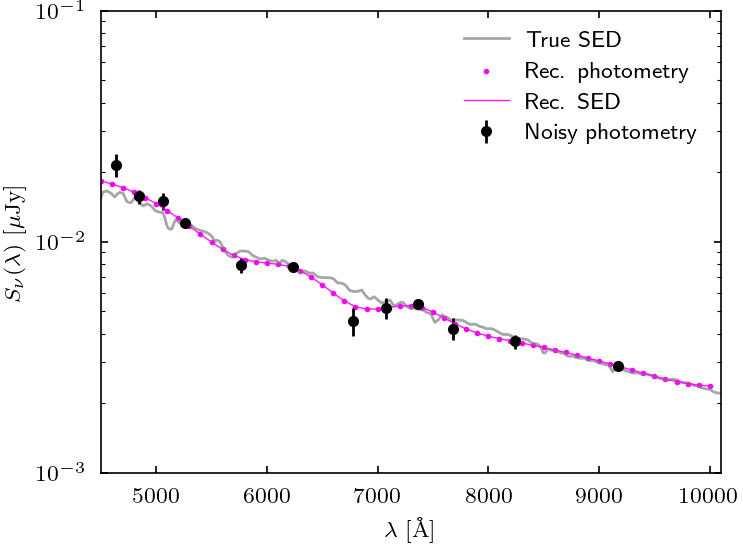

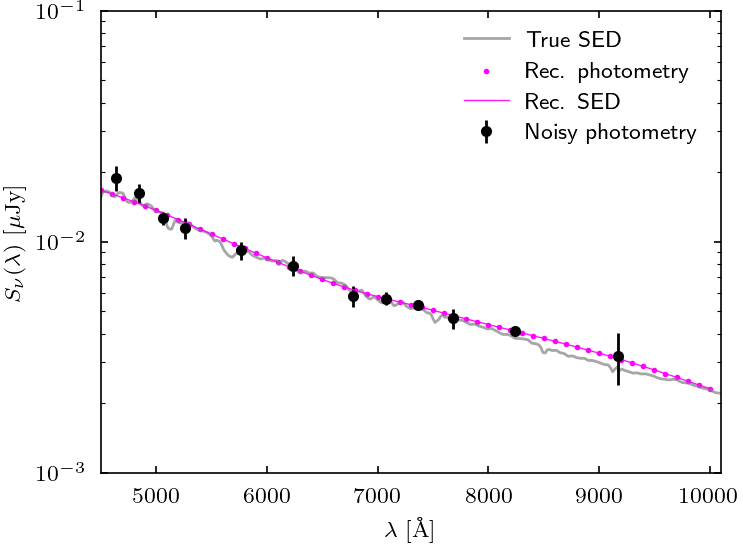

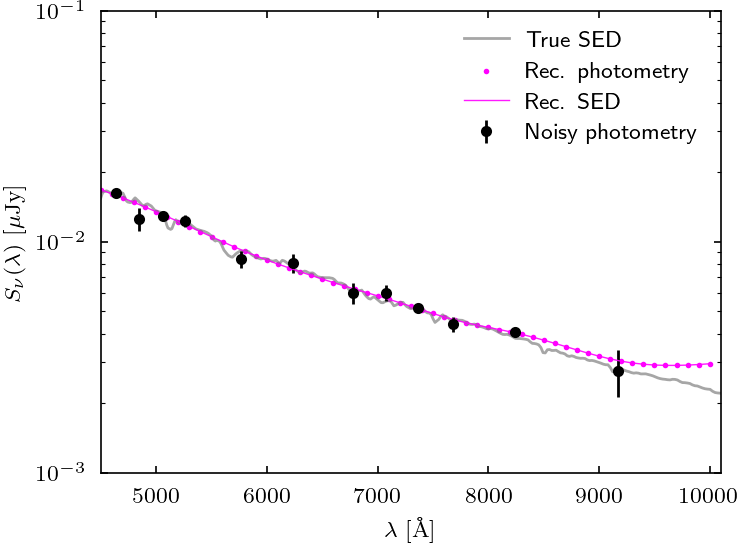

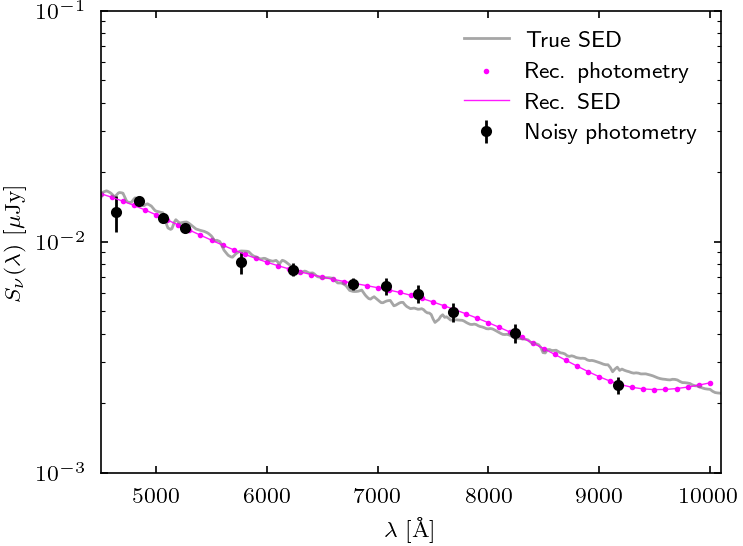

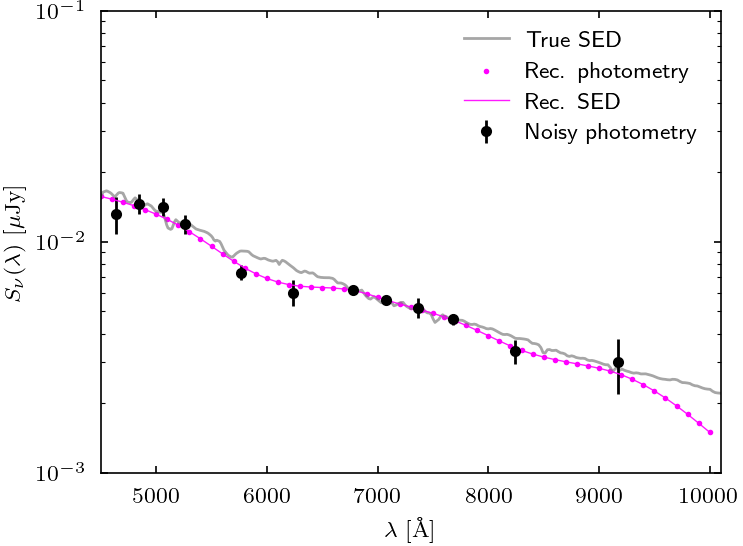

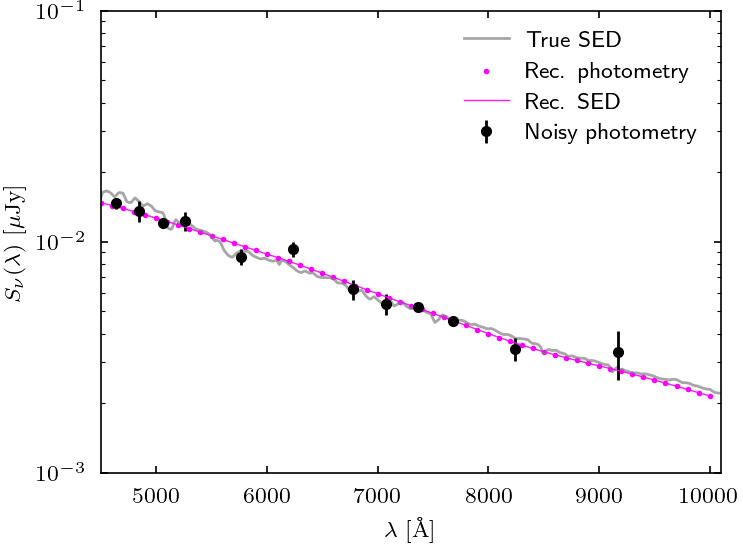

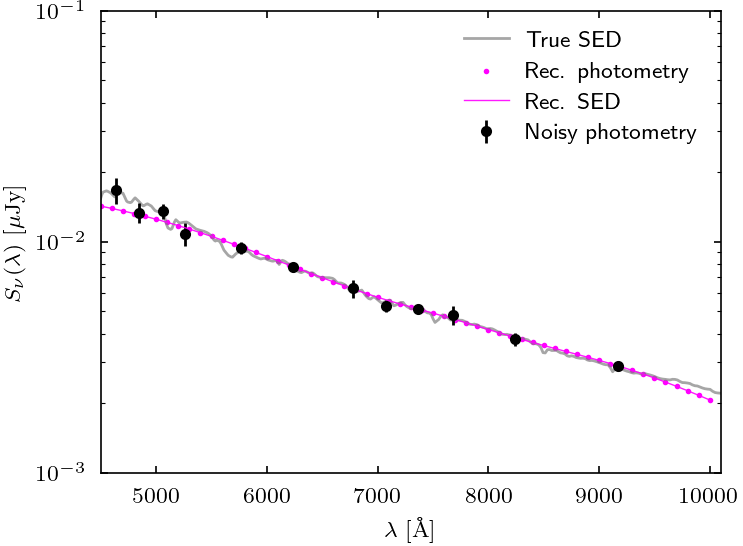

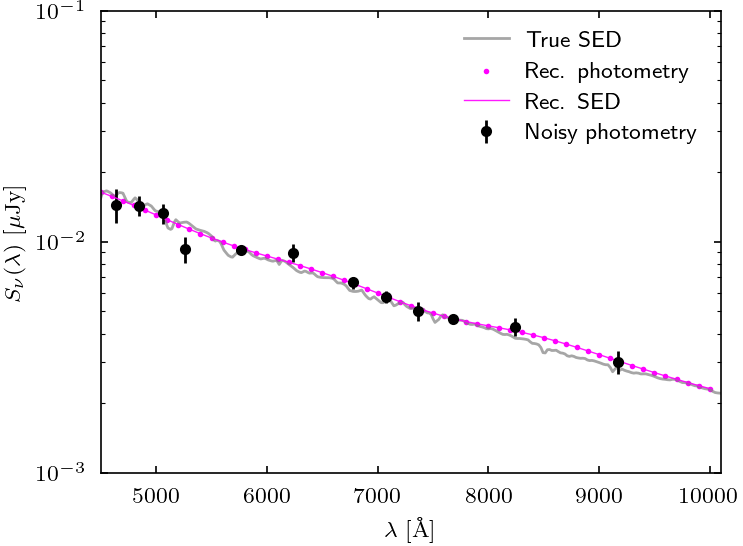

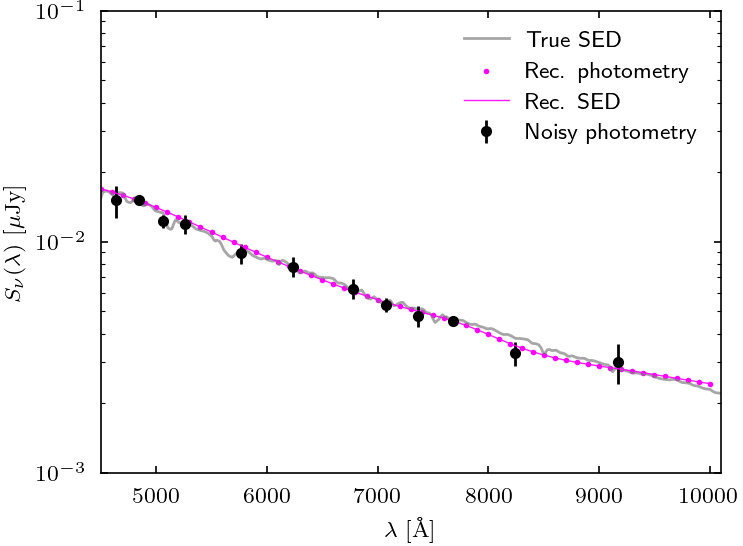

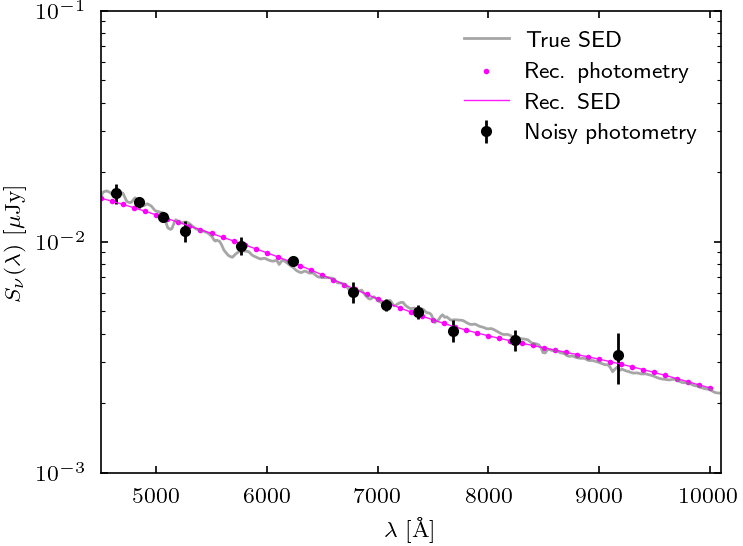

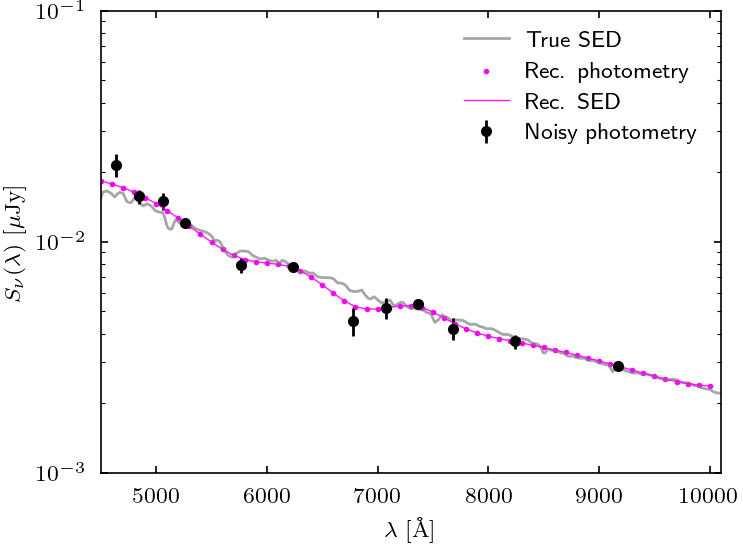

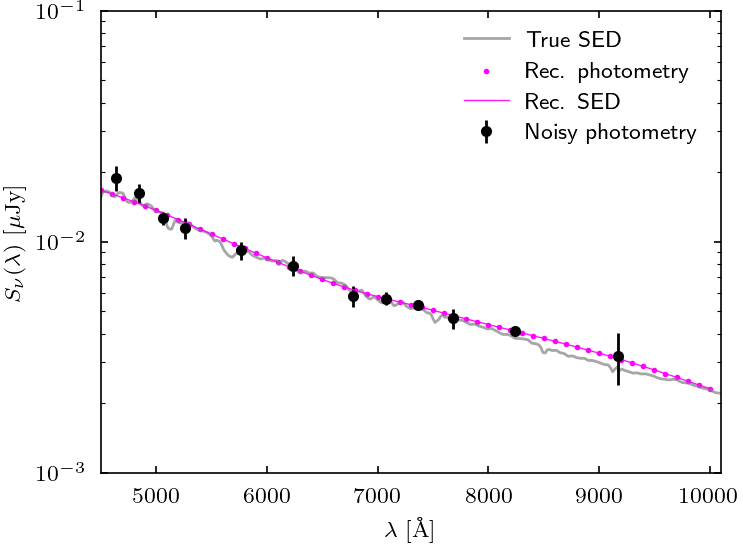

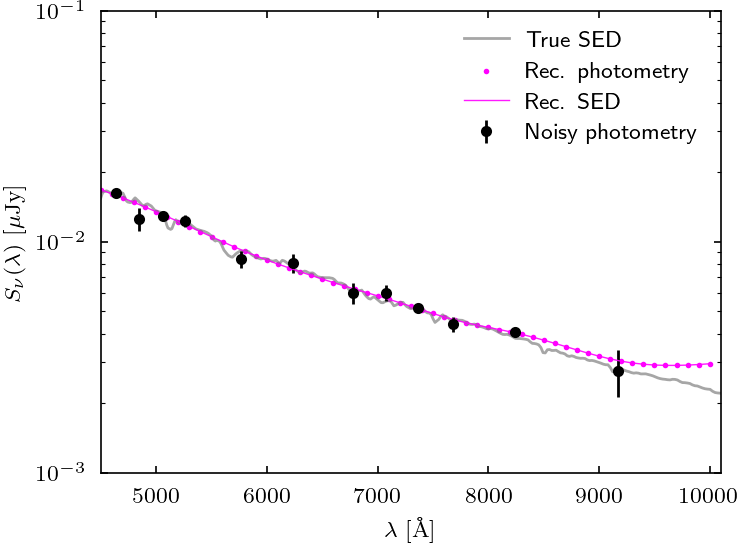

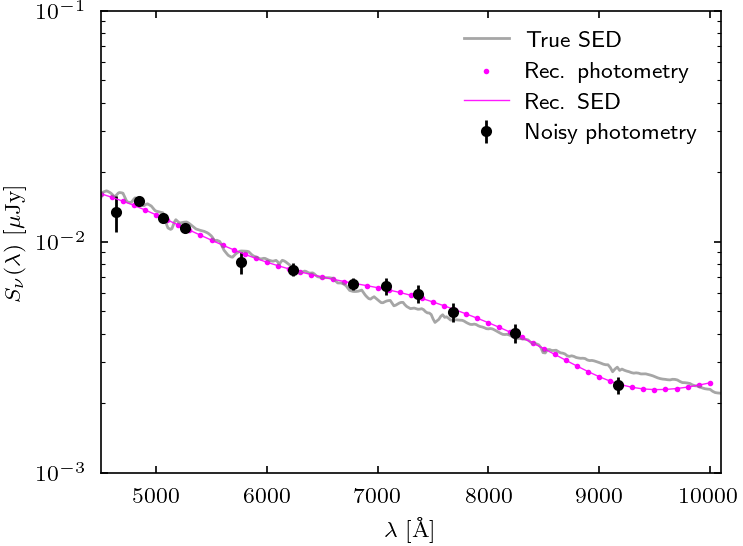

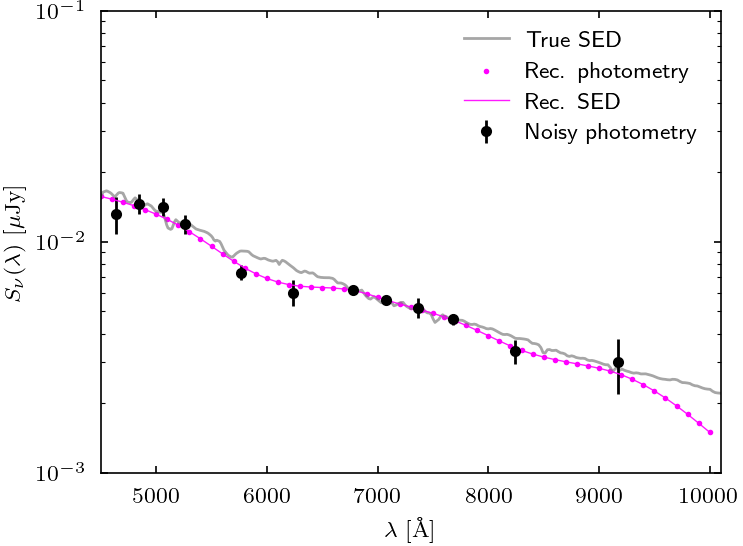

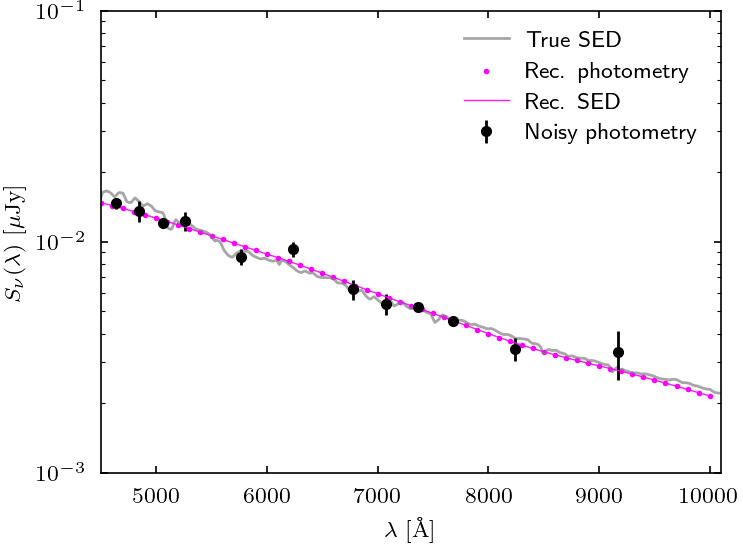

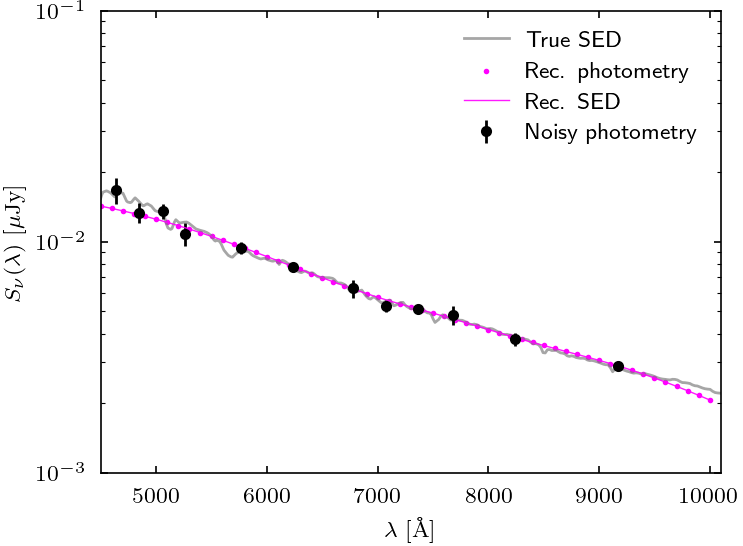

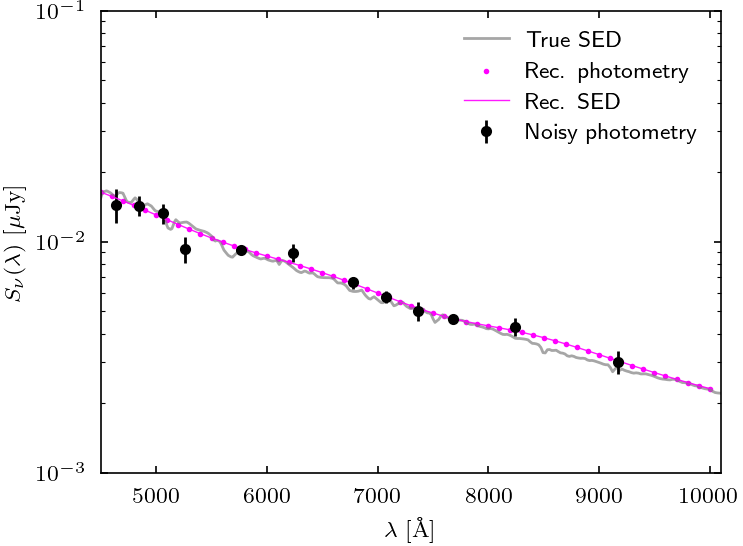

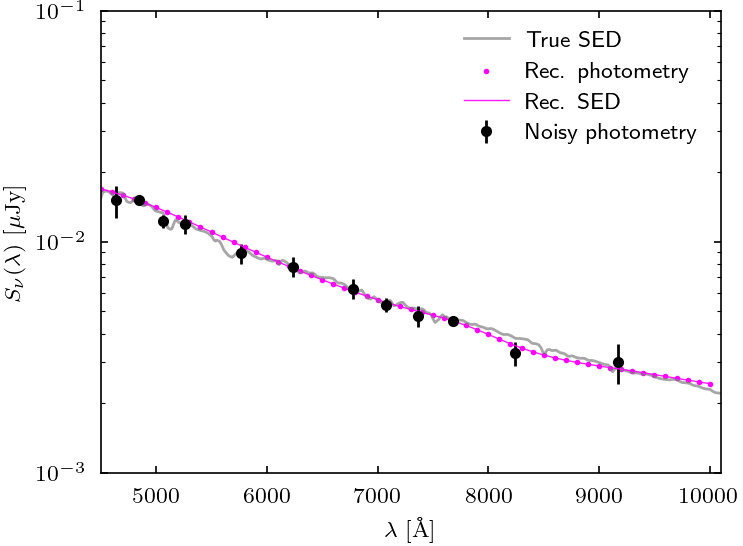

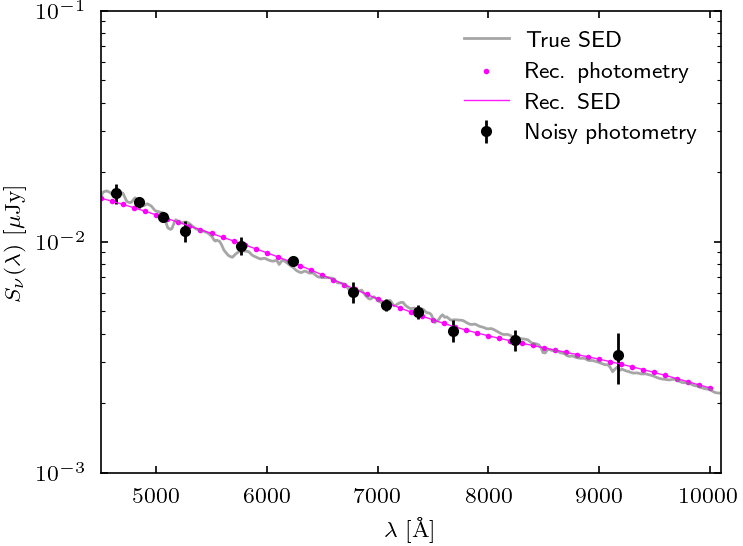

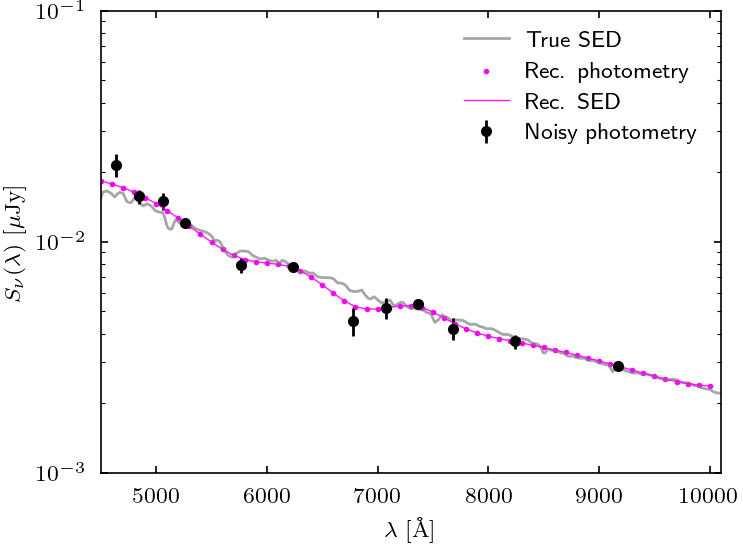

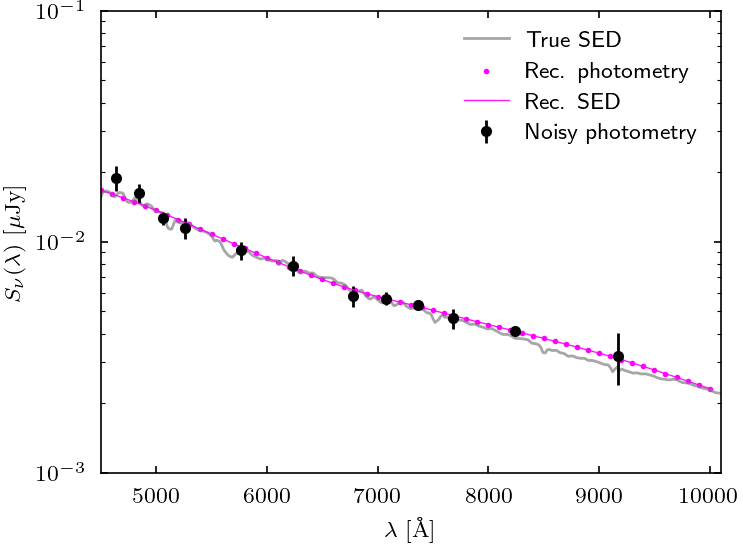

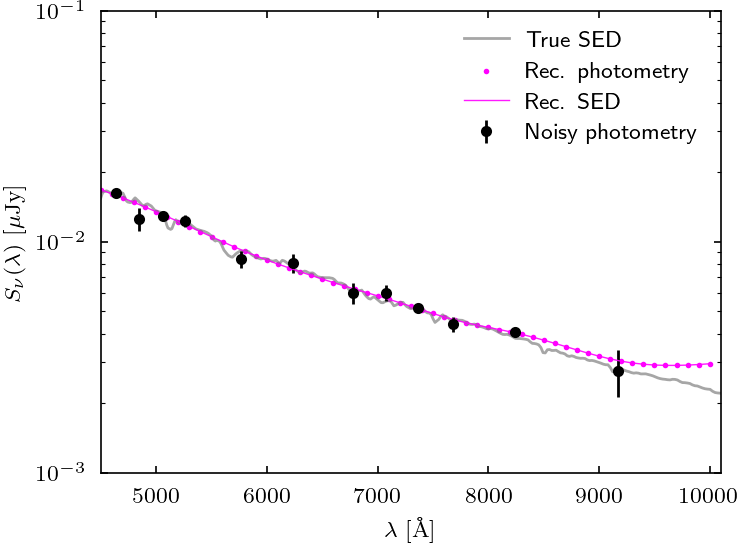

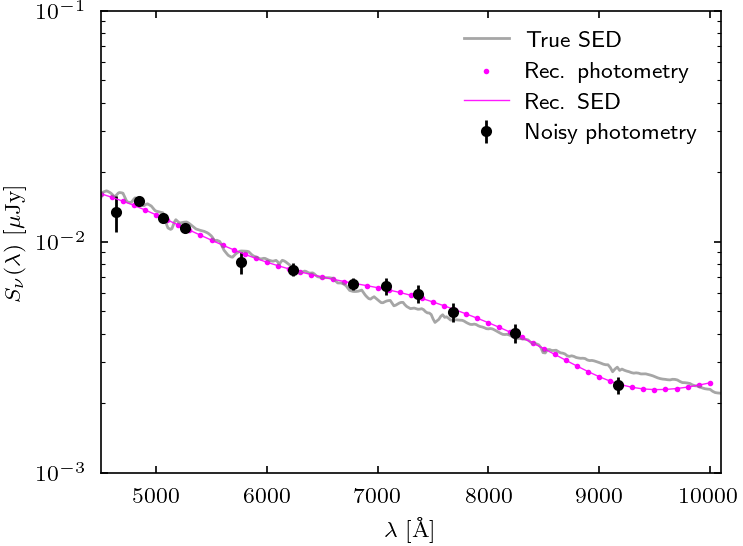

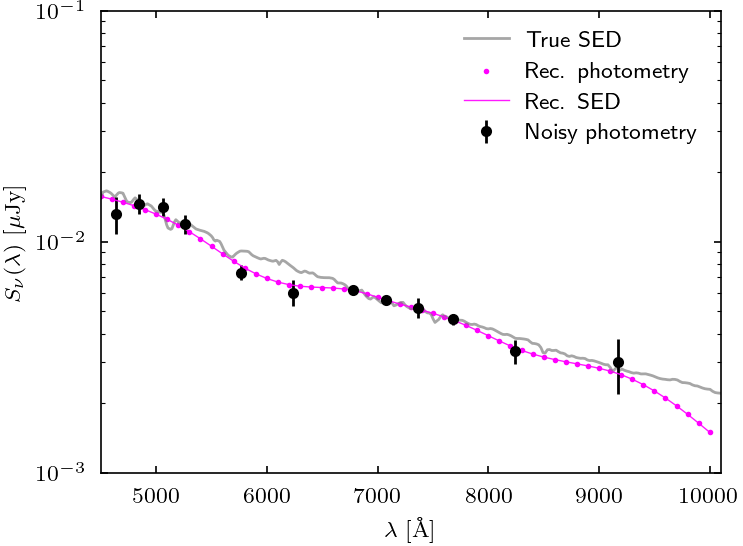

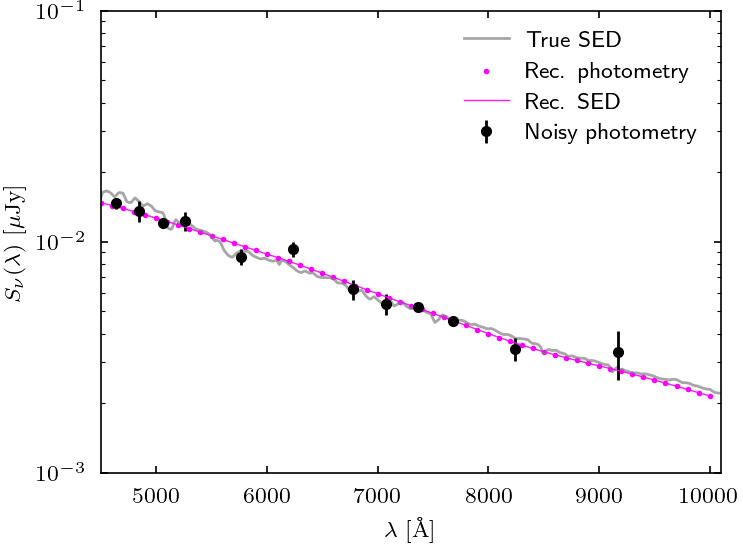

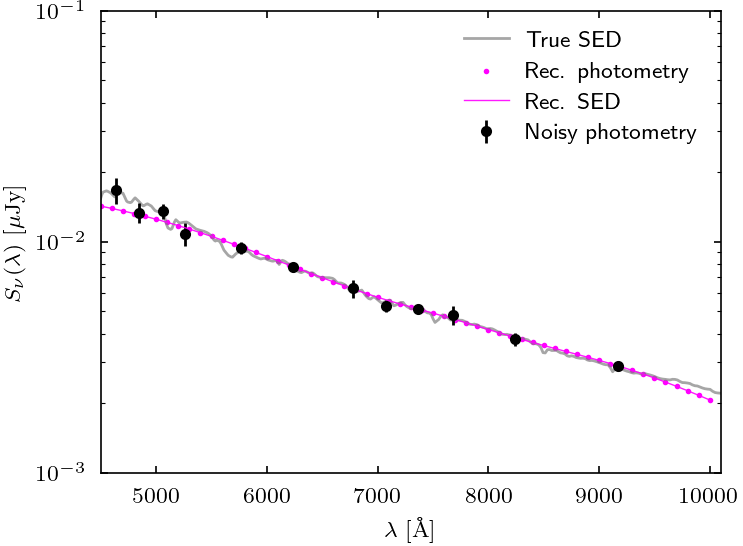

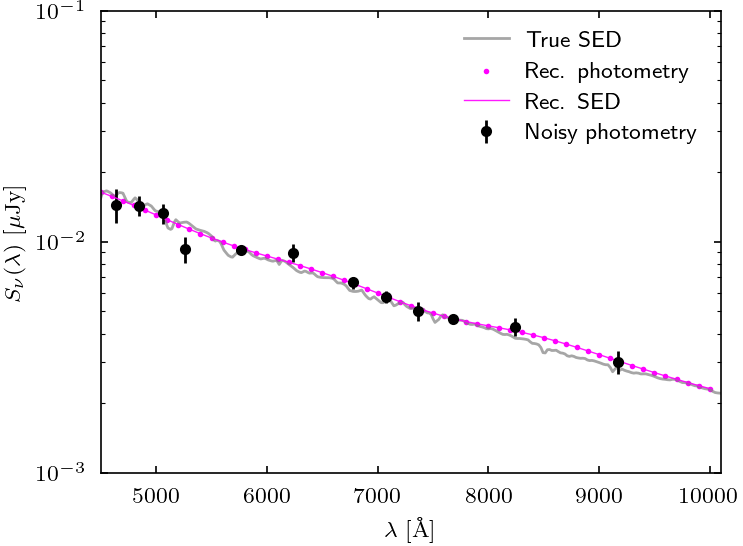

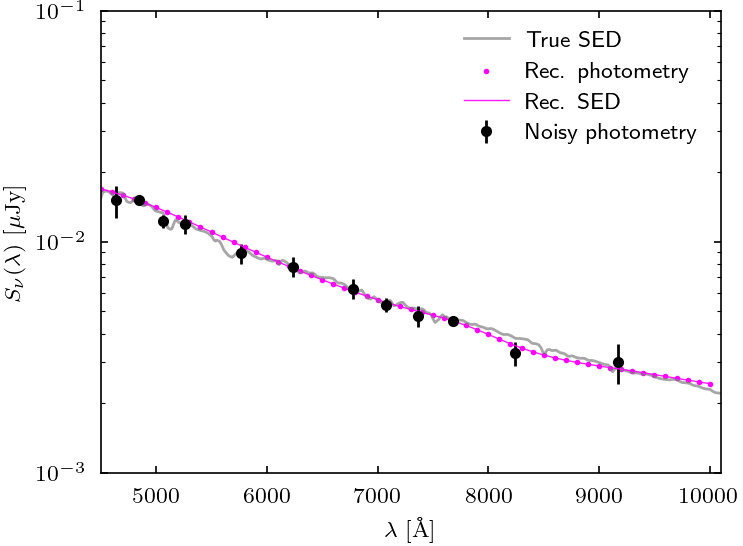

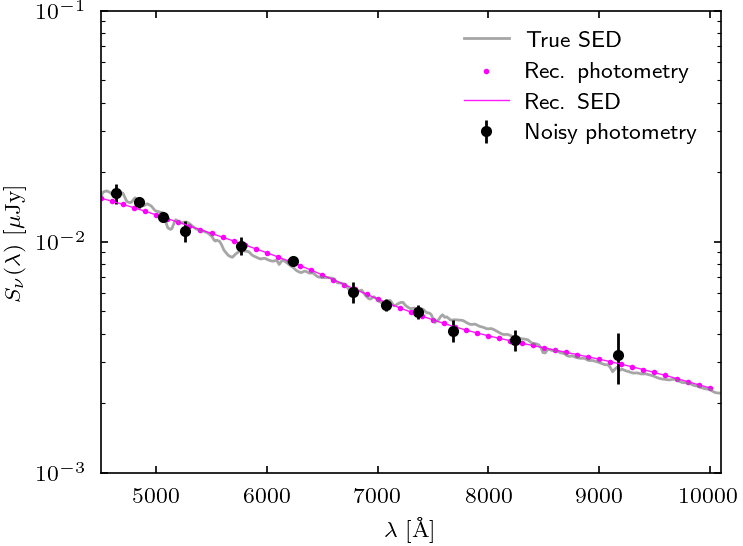

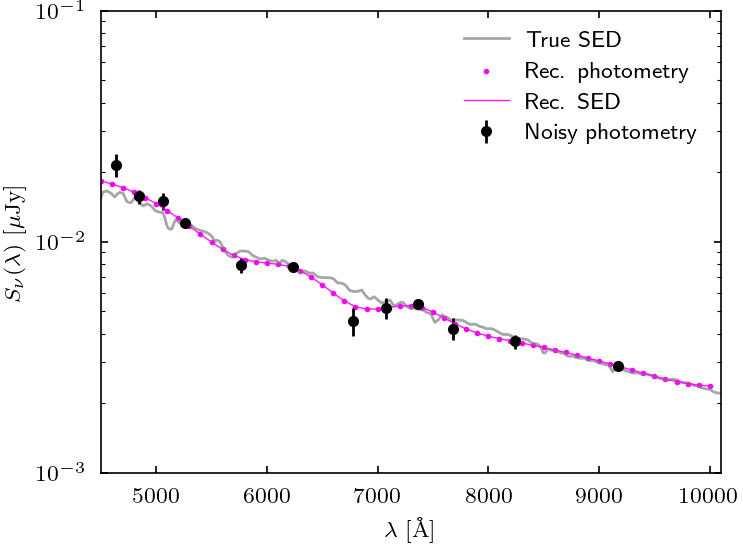

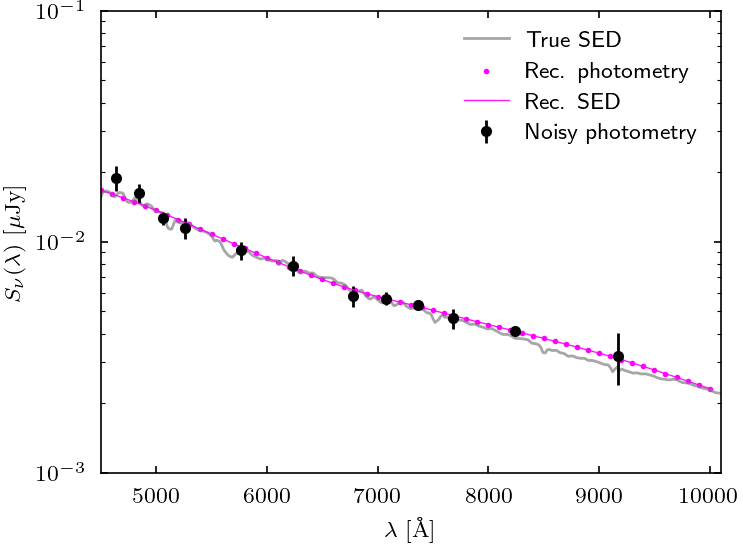

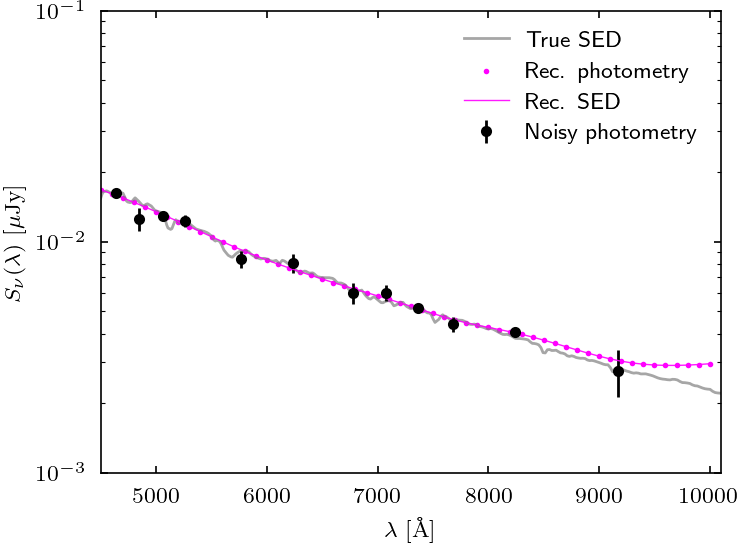

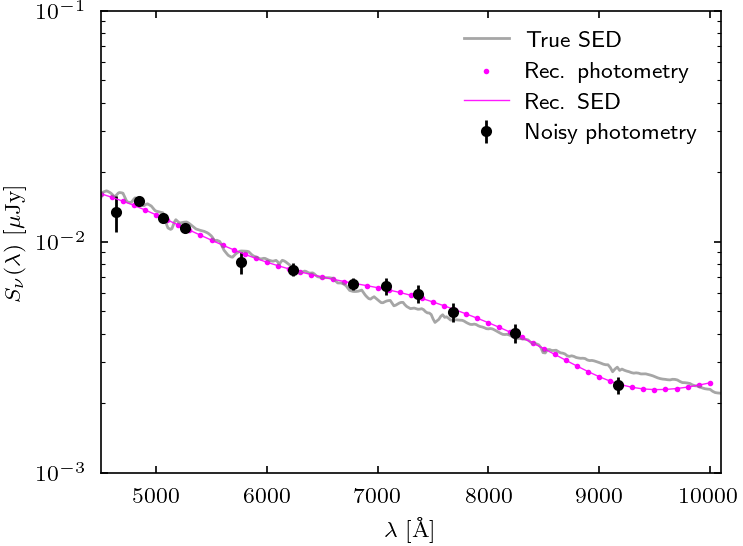

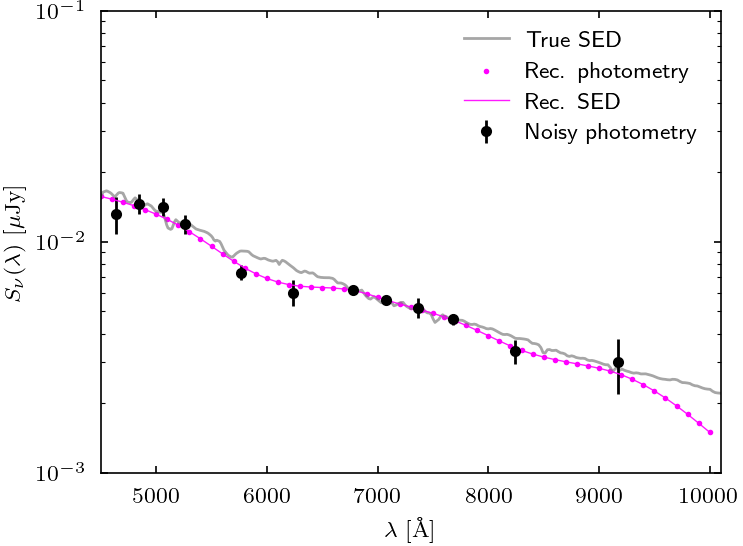

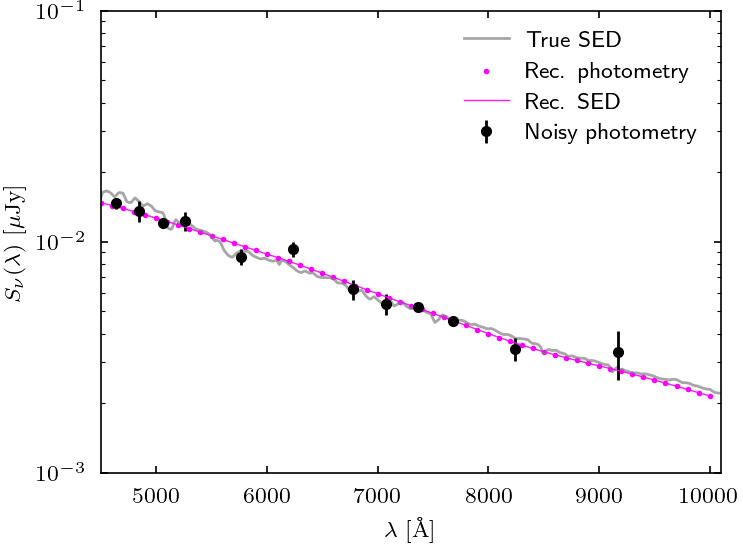

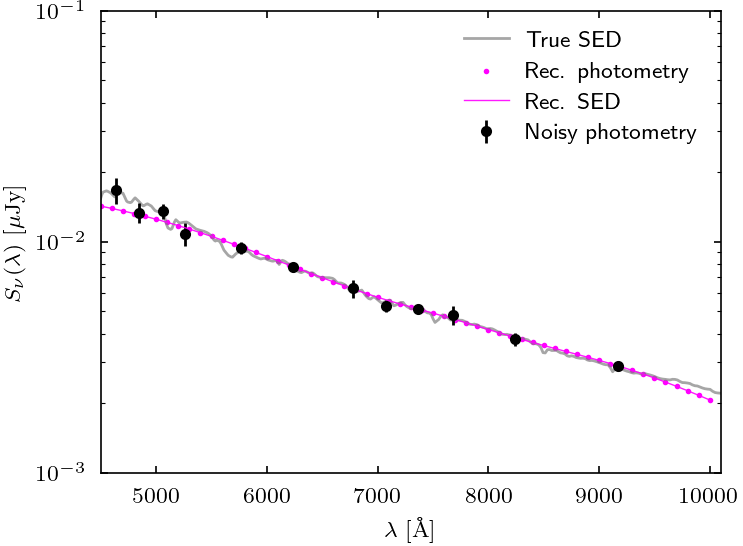

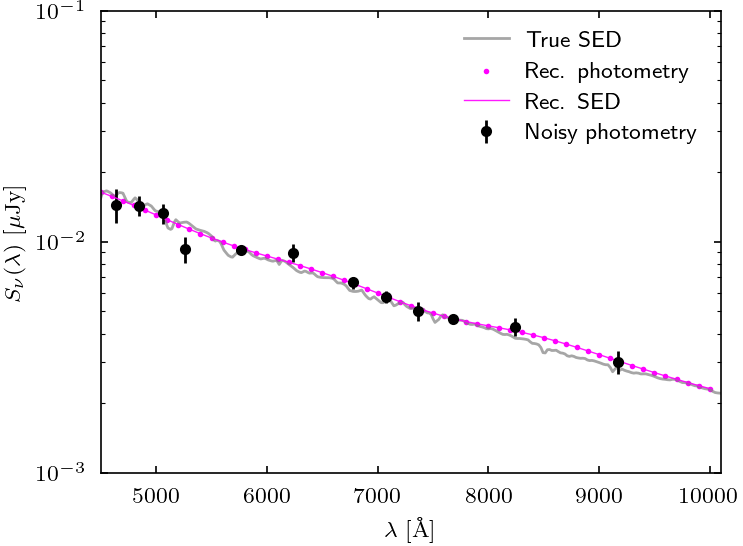

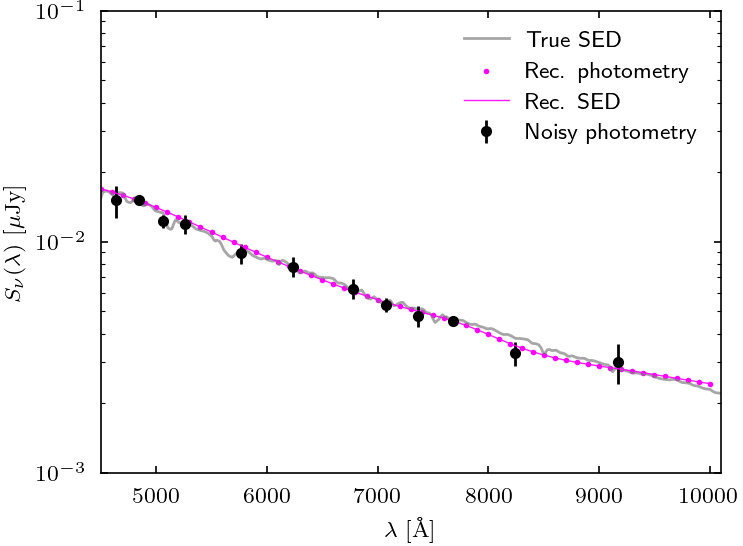

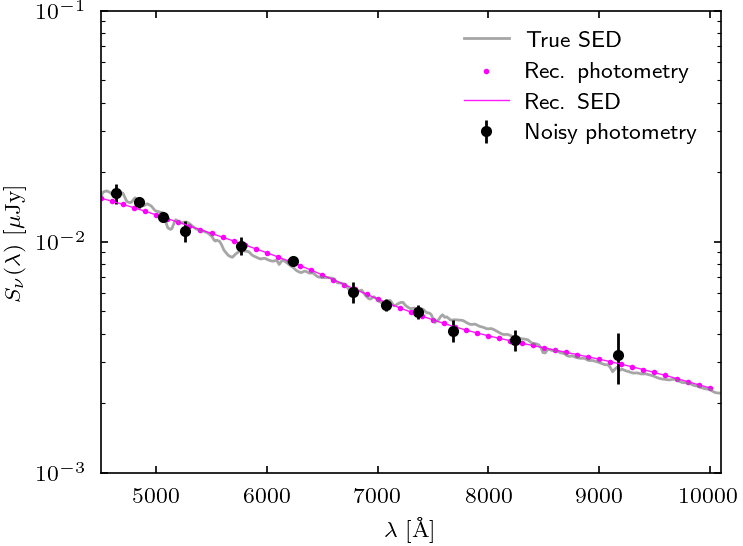

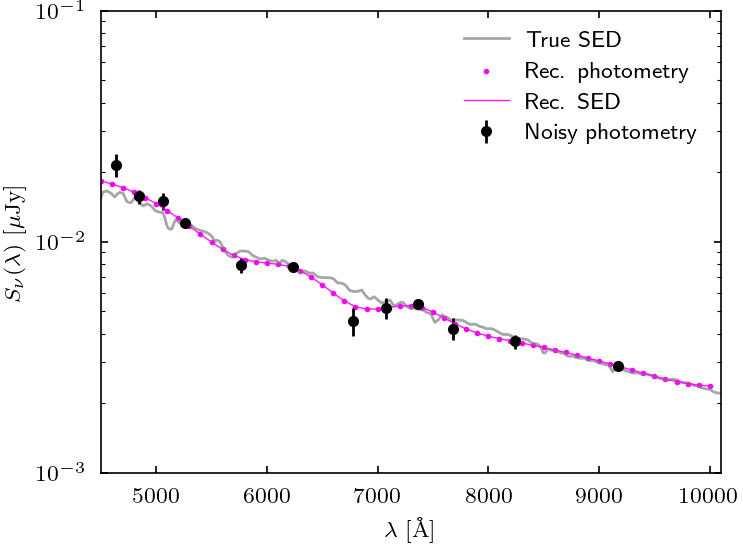

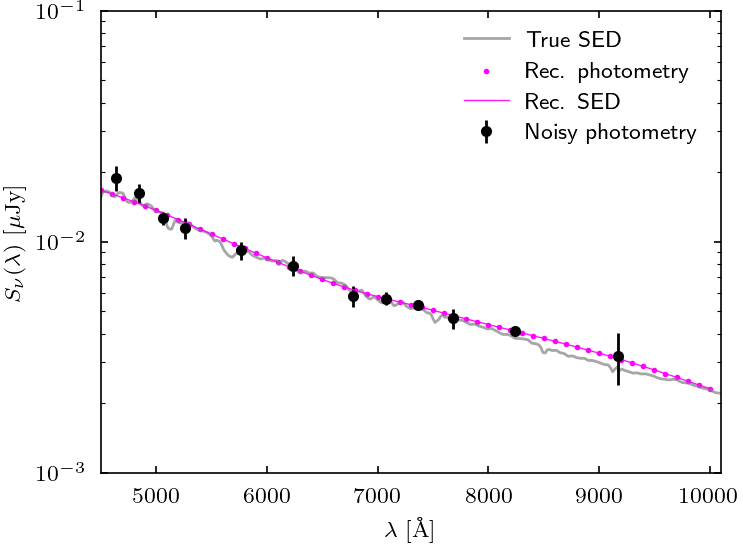

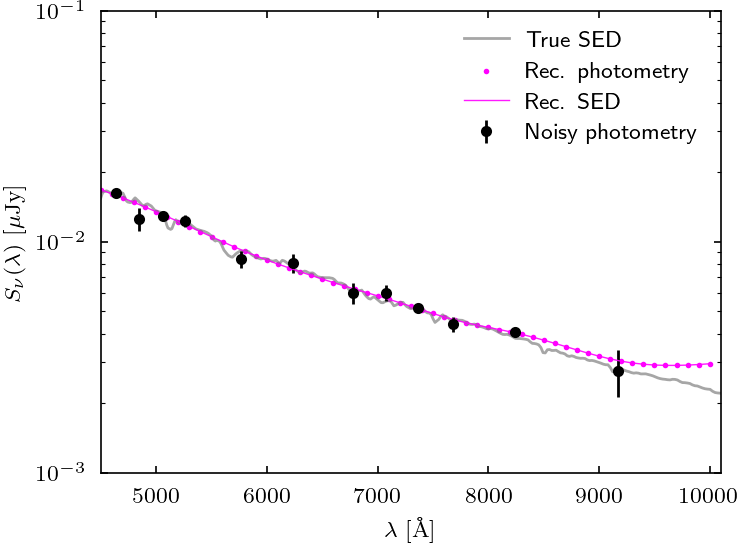

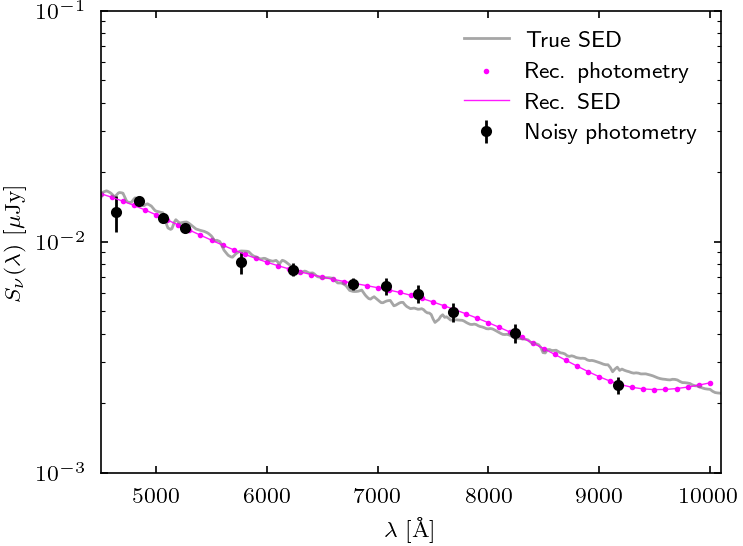

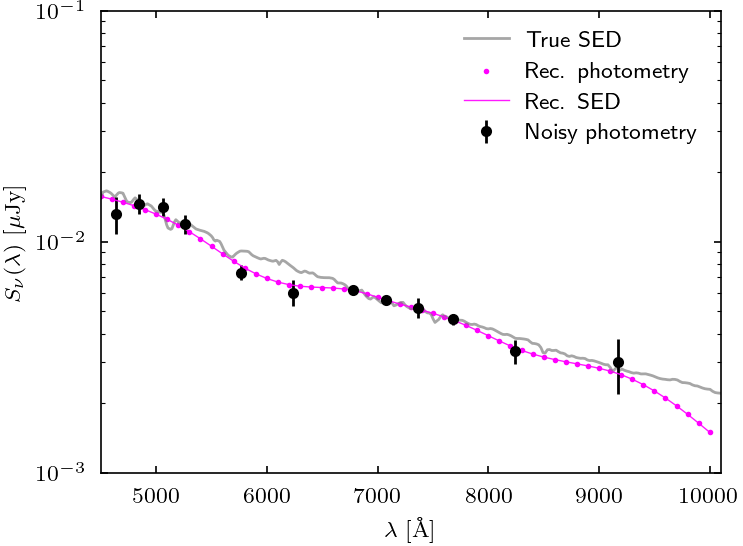

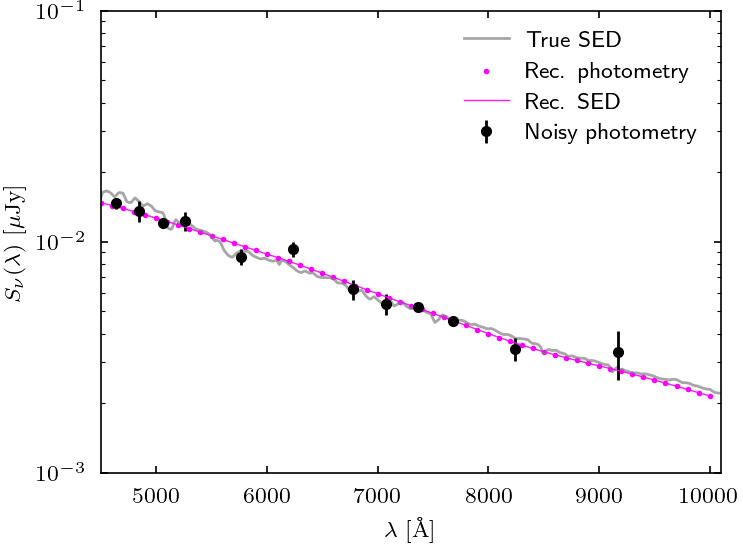

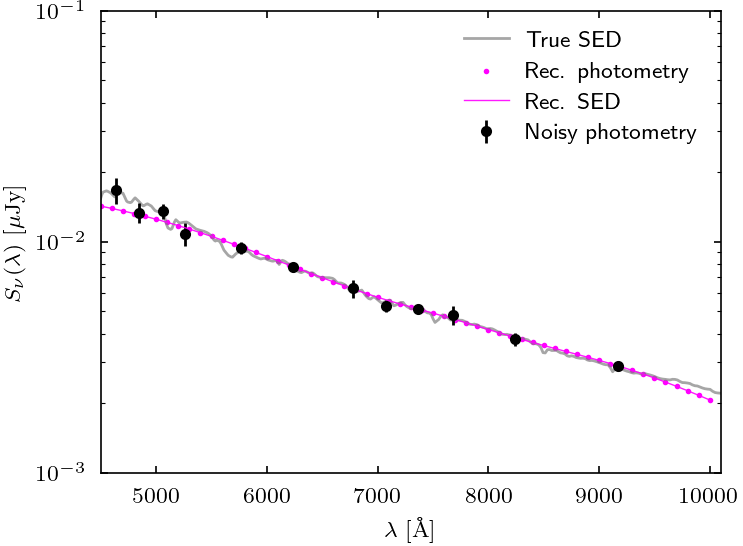

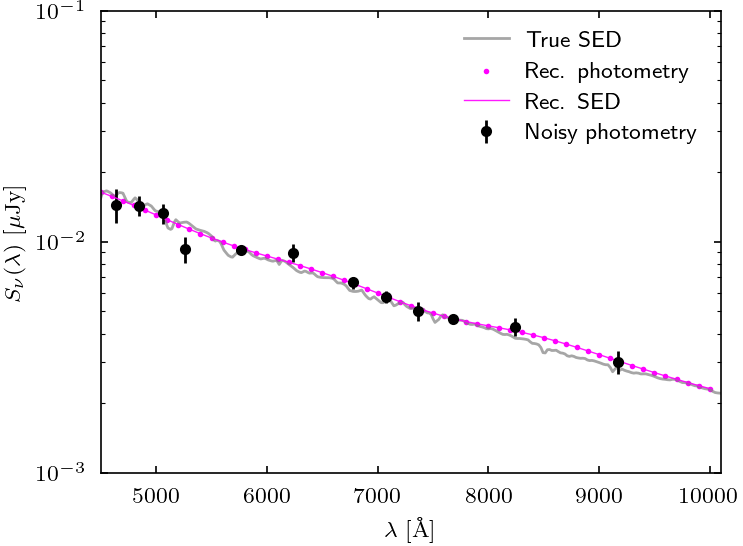

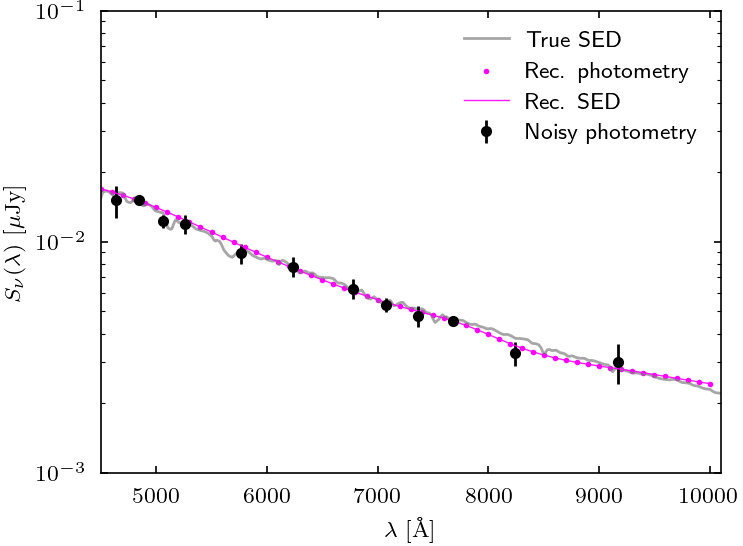

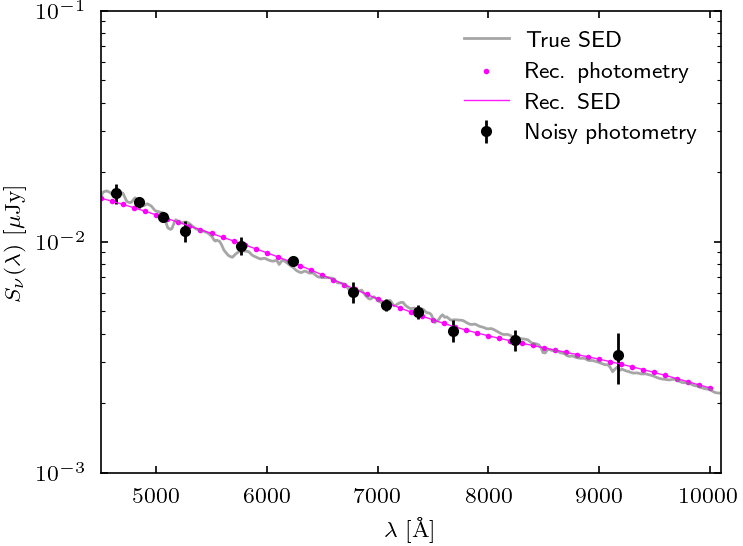

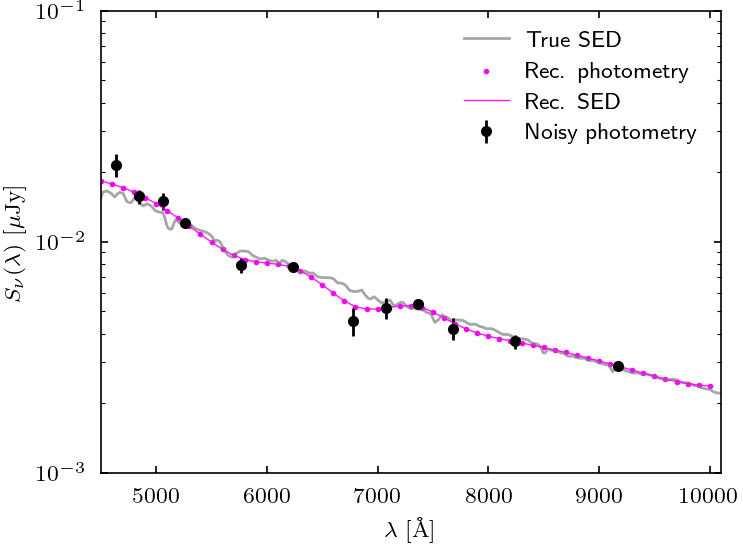

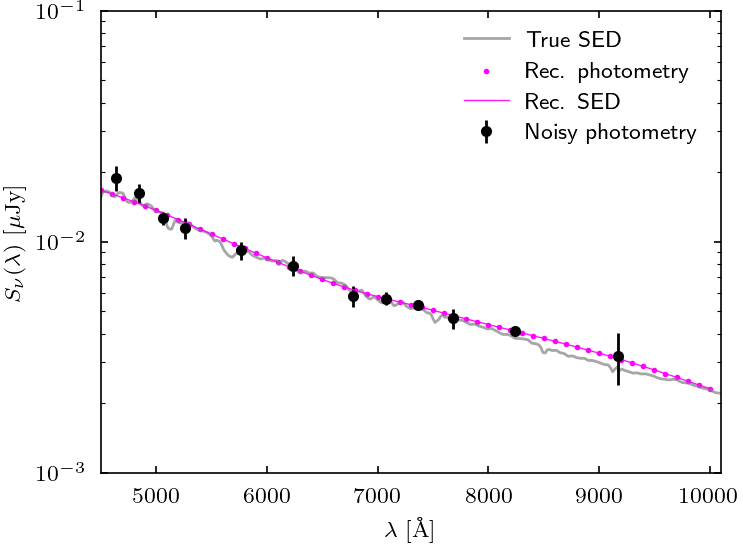

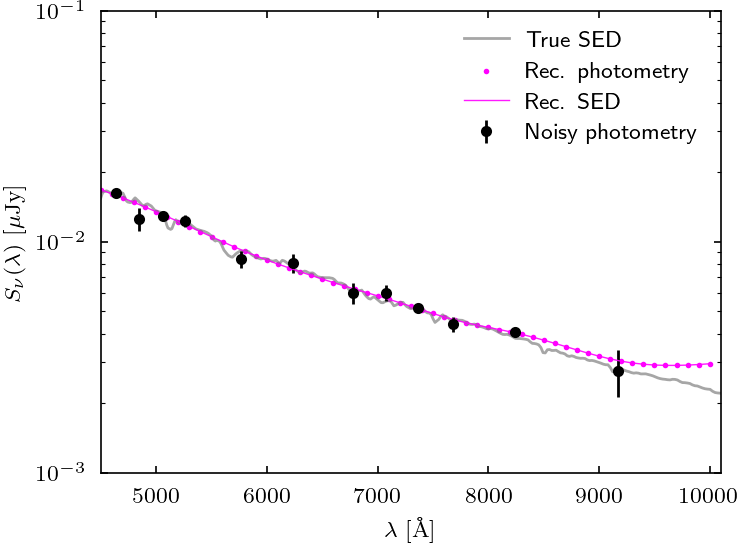

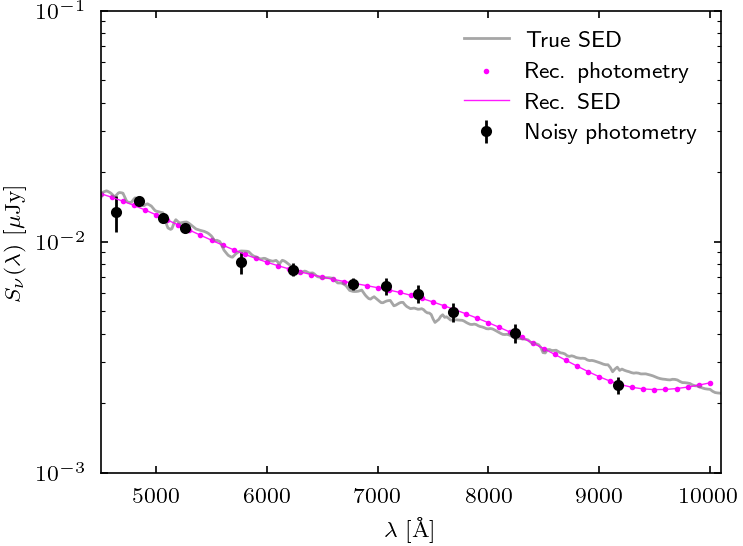

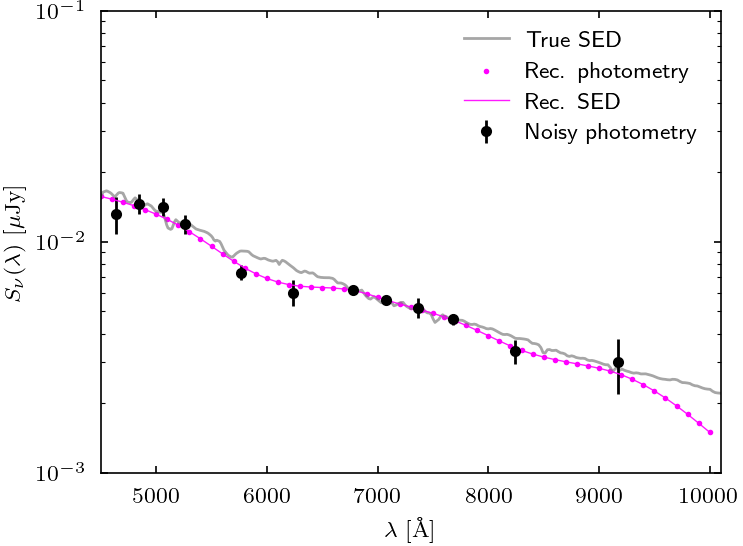

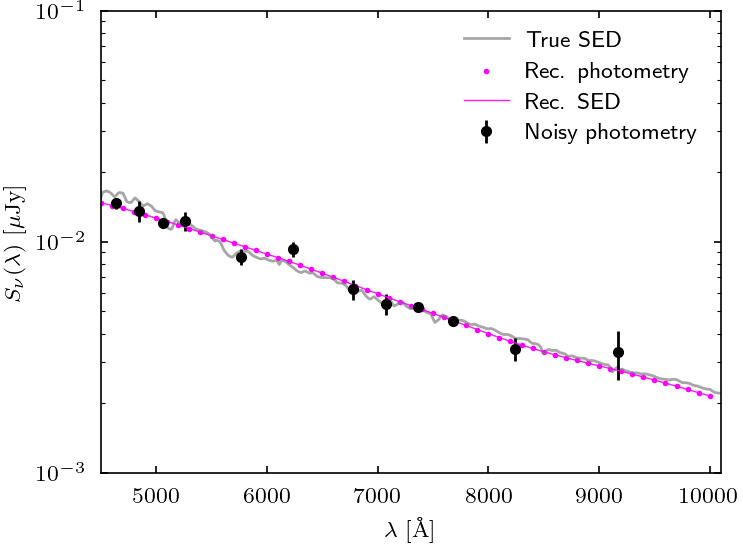

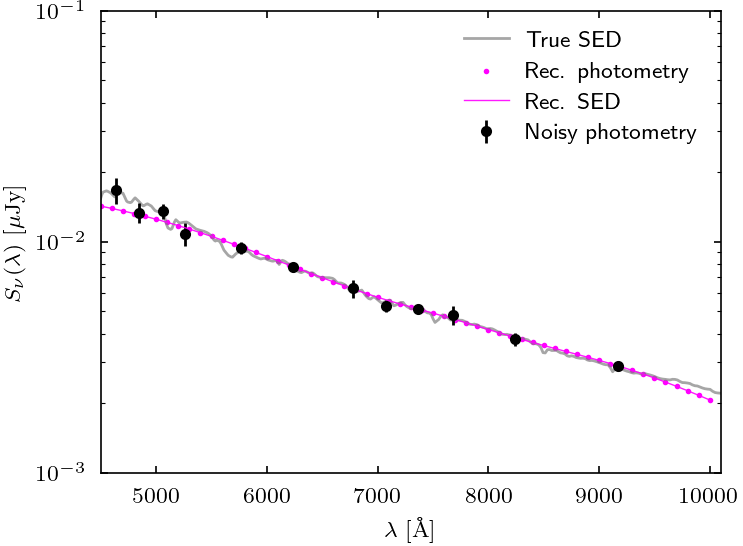

In [31]:
for n in range(0, len(row_sel)):
    row = row_sel[n]
    halo_id   = int(row["halo_id"])
    galaxy_id = int(row["galaxy_id"])
    
    # 1) Build the true SED
    wave_obs, F_obs = build_flagship_sed(row, templates, ext_laws)
    

    for n in range(0, 10):
        # 2) Retrieve the noisy flux points and plot them
        flux_noisy = []
        sigma_per_band = []
        for i in range(0, len(phot_cols)):
            flux_noisy.append(row_sel[phot_cols[i]][n])
            sigma_per_band.append(row_sel[phot_cols_err[i]][n])
        flux_noisy = np.array(flux_noisy)
        sigma_per_band = np.array(sigma_per_band)

        # 3) Read the reconstructed flux points and interpolate over them
        flux_rec = []
        flux_rec_err = []
        for i in range(0, len(gp_cols)):
            flux_rec.append(row_sel[gp_cols[i]][n])
            flux_rec_err.append(row_sel[gp_cols_err[i]][n])
        flux_rec = np.array(flux_rec)
        flux_rec_err = np.array(flux_rec_err)

        f_interp = interp1d(gp_waves[5:], flux_rec[5:], kind='linear', bounds_error=False)
        y_fine = f_interp(gp_waves[5:])
    
        # 4) Plot the true SED, the flux points and the reconstructed flux points and SED
        fig, ax = plt.subplots()
    
        # --- True SED
        ax.semilogy(wave_obs, F_obs, color="gray", alpha=0.7, label="True SED")
    
        # --- Noisy fluxes
        ax.errorbar(central_lambda, flux_noisy, yerr=sigma_per_band,
                    fmt='o', color="black", markersize=3, label="Noisy photometry")

        # --- 55 reconstructed fluxes
        ax.scatter(gp_waves[5:], flux_rec[5:], color="magenta", s=1, label="Rec. photometry")
        ax.plot(gp_waves[5:], y_fine, color="magenta", lw=0.5, alpha=0.9, label="Rec. SED")
    
        ax.set_xlim(4500, 10100)
        ax.set_ylim(1e-3, 1e-1)
        ax.set_xlabel(r"$\lambda\ [\mathrm{\AA}]$")
        ax.set_ylabel(r"$S_\nu (\lambda)\ [\mu\mathrm{Jy}]$")
        ax.legend(frameon = False)
        plt.show()

### C) Example of how to collect the GP-reconstructed fluxes and their uncertainties, without plotting

In [34]:
for n in range(0, 10):
    flux_rec = []
    flux_rec_err = []
    for i in range(0, len(gp_cols)):
        flux_rec.append(row_sel[gp_cols[i]][n])
        flux_rec_err.append(row_sel[gp_cols_err[i]][n])
    flux_rec = np.array(flux_rec)
    flux_rec_err = np.array(flux_rec_err)

    print('Realisation number', n)
    print(flux_rec)
    print(flux_rec_err)
    print()

Realisation number 0
[0.01967357 0.01904955 0.01840646 0.01774591 0.0170713  0.01638851
 0.01570363 0.01502269 0.0143511  0.01369383 0.01305629 0.01244432
 0.01186471 0.01132541 0.01083033 0.01037782 0.00996584 0.0095924
 0.00925547 0.00895048 0.00866913 0.00840278 0.00814286 0.00788125
 0.00761539 0.00734633 0.00707514 0.0068029  0.0065307  0.00626055
 0.00599658 0.00574324 0.00550461 0.00528411 0.00508505 0.00490905
 0.00475538 0.00462315 0.00451036 0.00441204 0.00432277 0.00423715
 0.00414976 0.00405539 0.00395246 0.00384254 0.00372729 0.00360836
 0.00348743 0.00336613 0.00324614 0.0031291  0.00301668 0.00290993
 0.0028088  0.00271314 0.0026228  0.00253762 0.00245747 0.00238221
 0.00231169]
[9.06294122e-04 8.53615114e-04 8.11051992e-04 7.75536926e-04
 7.44202546e-04 7.14440055e-04 6.84601075e-04 6.54043056e-04
 6.22669558e-04 5.90931606e-04 5.59116436e-04 5.27304741e-04
 4.95429632e-04 4.63077307e-04 4.29972801e-04 3.96239548e-04
 3.64256624e-04 3.39299545e-04 3.28731024e-04 3.33623